# Adaptive Multi-Strategy Quant Trading Engine

## Regime Detection, Statistical Arbitrage, Volatility Forecasting, and Portfolio Optimization

## 1. Import Libraries and Set Project Configuration

In [1]:
# ============================================================
# Adaptive Multi-Strategy Crypto Quant Research Engine
# Section 1: Imports
# ============================================================

# ------------------------------------------------------------
# 1. Core Data Libraries
# ------------------------------------------------------------

# pandas is used for time-series data, price matrices, returns, portfolio weights,
# and performance tables.
import pandas as pd

# numpy is used for vectorized math, numerical operations, and signal calculations.
import numpy as np


# ------------------------------------------------------------
# 2. Visualization
# ------------------------------------------------------------

# matplotlib is used for cumulative returns, drawdowns, heatmaps,
# rolling Sharpe plots, and strategy comparisons.
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 3. Date, File, and Download Utilities
# ------------------------------------------------------------

# datetime tools help define backtest windows and handle historical data ranges.
from datetime import datetime, timedelta

# time can be used to pause between downloads if needed.
import time

# warnings lets us suppress non-critical notebook warnings for cleaner output.
import warnings

# os and pathlib help create folders and manage local cached data files.
import os
from pathlib import Path

# zipfile and BytesIO are needed because Binance public historical files
# are downloaded as compressed .zip files.
import zipfile
from io import BytesIO

# requests is used to download public historical data files without relying
# on the live Binance API client.
import requests


# ------------------------------------------------------------
# 4. Statistical Analysis
# ------------------------------------------------------------

# scipy.stats is used for t-tests, correlations, skew, kurtosis,
# and signal predictiveness analysis.
from scipy import stats

# statsmodels is used for alpha/beta regressions against benchmarks.
import statsmodels.api as sm


# ------------------------------------------------------------
# 5. Optimization
# ------------------------------------------------------------

# scipy.optimize will be used later for portfolio optimization,
# such as maximizing expected return after risk and turnover penalties.
from scipy.optimize import minimize


# ------------------------------------------------------------
# 6. Display and Plot Settings
# ------------------------------------------------------------

# Make pandas output easier to inspect in the notebook.
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# Use readable default chart sizes.
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

# Suppress non-critical warnings to keep the notebook clean.
warnings.filterwarnings("ignore")

# Set random seed for reproducibility when random sampling or optimization
# routines are used later.
np.random.seed(42)

print("All core libraries loaded.")

All core libraries loaded.


## 2. Global Project Settings

In [2]:
# ============================================================
# Global Project Settings
# ============================================================

# ------------------------------------------------------------
# 1. Backtest Date Range
# ------------------------------------------------------------

# We begin in 2020 because this gives the project multiple crypto regimes:
# - 2020-2021 bull market
# - 2022 crypto crash / high-volatility bear market
# - 2023 recovery period
# - 2024+ validation period
START_DATE = "2020-01-01"

# Parameters and strategy decisions will be selected using only data up to this date.
# This prevents lookahead bias because validation data is not used for optimization.
TRAIN_END_DATE = "2023-12-31"

# Validation period begins after the training set.
# All final strategy results should be reported on this out-of-sample period.
VALIDATION_START_DATE = "2024-01-01"

# End date for the historical sample.
# This can be updated depending on what data is available.
END_DATE = "2026-05-31"


# ------------------------------------------------------------
# 2. Timeframe Selection
# ------------------------------------------------------------

# Primary interval is 4h because many crypto strategies from class,
# such as channel breakouts, moving-average crossovers, short-term reversal,
# and intraday momentum can be tested at this frequency.
PRIMARY_INTERVAL = "4h"

# Secondary interval is daily.
# Daily data is cleaner for medium-term momentum, volatility estimation,
# benchmark comparisons, and portfolio-level risk analysis.
SECONDARY_INTERVAL = "1d"


# ------------------------------------------------------------
# 3. Universe Construction
# ------------------------------------------------------------

# We focus on USDT-quoted spot pairs because they are usually among the most liquid
# Binance crypto markets and put all assets in a common quote currency.
QUOTE_ASSET = "USDT"

# We start with a broad target universe to avoid cherry-picking assets.
# The final universe may be smaller after filtering for data quality,
# liquidity, and sufficient trading history.
TARGET_UNIVERSE_SIZE = 150

# Require at least 2 years of data when possible.
# This helps avoid strategies being driven by assets with very short histories.
MIN_HISTORY_DAYS = 365 * 2

# Minimum average daily dollar volume filter.
# This removes illiquid assets where backtested alpha may be unrealistic
# because real execution would suffer from high slippage.
MIN_AVG_DAILY_VOLUME_USD = 5_000_000


# ------------------------------------------------------------
# 4. Transaction Cost Assumptions
# ------------------------------------------------------------

# Gross case: ignores transaction costs.
# Useful for measuring raw signal quality before implementation costs.
TCOST_GROSS = 0.0000

# Limit-order case: assumes only commission cost.
# The class project guideline suggests approximately 7 bps for limit orders.
TCOST_LIMIT = 0.0007

# Market-order base case: assumes commission + slippage.
# The class project guideline suggests approximately 20 bps total cost.
TCOST_MARKET = 0.0020

# Stress case: higher transaction cost assumption.
# Used to test whether the strategy remains robust under worse execution.
TCOST_STRESS = 0.0050

# Main cost assumption for reported strategy results.
# We use the conservative market-order estimate as the base case.
BASE_TCOST = TCOST_MARKET


# ------------------------------------------------------------
# 5. Portfolio Construction Assumptions
# ------------------------------------------------------------

# Maximum allowed weight in one asset.
# This prevents the portfolio from becoming overly concentrated in one coin,
# which is especially important in crypto because individual assets can crash heavily.
MAX_WEIGHT_PER_ASSET = 0.10

# Target annualized volatility for risk scaling.
# Later, volatility targeting will reduce exposure when forecasted volatility is high
# and increase exposure when forecasted volatility is low.
TARGET_ANNUAL_VOL = 0.25


# ------------------------------------------------------------
# 6. Annualization Assumptions
# ------------------------------------------------------------

# Crypto trades 24/7, so we use 365 trading days per year instead of 252.
DAYS_PER_YEAR_CRYPTO = 365

# There are six 4-hour bars in each day.
BARS_PER_DAY_4H = 6

# Annualization factor for 4h strategies.
BARS_PER_YEAR_4H = BARS_PER_DAY_4H * DAYS_PER_YEAR_CRYPTO

# Annualization factor for daily strategies.
BARS_PER_YEAR_1D = DAYS_PER_YEAR_CRYPTO


# ------------------------------------------------------------
# 7. Print Configuration Summary
# ------------------------------------------------------------

print("Project settings initialized.")
print(f"Training period: {START_DATE} to {TRAIN_END_DATE}")
print(f"Validation period: {VALIDATION_START_DATE} to {END_DATE}")
print(f"Primary interval: {PRIMARY_INTERVAL}")
print(f"Secondary interval: {SECONDARY_INTERVAL}")
print(f"Target universe size before filtering: {TARGET_UNIVERSE_SIZE}")
print(f"Base transaction cost assumption: {BASE_TCOST:.4%}")
print(f"Max asset weight: {MAX_WEIGHT_PER_ASSET:.0%}")
print(f"Target annualized volatility: {TARGET_ANNUAL_VOL:.0%}")

Project settings initialized.
Training period: 2020-01-01 to 2023-12-31
Validation period: 2024-01-01 to 2026-05-31
Primary interval: 4h
Secondary interval: 1d
Target universe size before filtering: 150
Base transaction cost assumption: 0.2000%
Max asset weight: 10%
Target annualized volatility: 25%


## 3. Public Binance Historical Data Setup

In [3]:
# ============================================================
# Public Binance Historical Data Setup
# ============================================================

# ------------------------------------------------------------
# 1. Data Source
# ------------------------------------------------------------

# We use Binance's public historical data files instead of the live Binance API.
# This avoids location/account restrictions and makes the notebook reproducible.
#
# Monthly spot kline files are organized like:
# https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/4h/BTCUSDT-4h-2024-01.zip
#
# This gives us historical OHLCV data needed for signal research and backtesting.
BASE_DATA_URL = "https://data.binance.vision/data/spot/monthly/klines"


# ------------------------------------------------------------
# 2. Local Data Storage
# ------------------------------------------------------------

# Create a project data folder so downloaded files can be cached locally.
# This prevents repeatedly downloading the same files every time the notebook runs.
DATA_DIR = Path("crypto_data")

# Raw data stores downloaded .zip files exactly as received.
RAW_DATA_DIR = DATA_DIR / "raw"

# Processed data will later store cleaned price, volume, and return matrices.
PROCESSED_DATA_DIR = DATA_DIR / "processed"


# ------------------------------------------------------------
# 3. Create Directories
# ------------------------------------------------------------

# parents=True creates parent folders if they do not exist.
# exist_ok=True avoids errors if the folders already exist.
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 4. Confirm Setup
# ------------------------------------------------------------

print("Public historical data setup complete.")
print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Processed data directory: {PROCESSED_DATA_DIR}")

Public historical data setup complete.
Raw data directory: crypto_data/raw
Processed data directory: crypto_data/processed


In [4]:
# ============================================================
# Test Public Binance Data Download
# ============================================================

def download_binance_monthly_klines(symbol, interval, year, month, save_dir=RAW_DATA_DIR):
    """
    Downloads one monthly kline zip file from Binance public data.

    Example file:
    https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/4h/BTCUSDT-4h-2024-01.zip
    """
    month_str = f"{month:02d}"
    filename = f"{symbol}-{interval}-{year}-{month_str}.zip"
    url = f"{BASE_DATA_URL}/{symbol}/{interval}/{filename}"

    save_path = save_dir / filename

    if save_path.exists():
        return save_path

    response = requests.get(url)

    if response.status_code == 200:
        with open(save_path, "wb") as f:
            f.write(response.content)
        return save_path
    else:
        return None


def read_binance_kline_zip(zip_path):
    """
    Reads a Binance public kline zip file into a clean DataFrame.
    """
    columns = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_volume", "num_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
    ]

    with zipfile.ZipFile(zip_path, "r") as z:
        csv_name = z.namelist()[0]
        with z.open(csv_name) as f:
            df = pd.read_csv(f, header=None, names=columns)

    # Binance spot timestamps from 2025 onward may be in microseconds.
    # This handles both millisecond and microsecond timestamps.
    max_ts = df["open_time"].max()
    unit = "us" if max_ts > 10**14 else "ms"

    df["open_time"] = pd.to_datetime(df["open_time"], unit=unit, utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit=unit, utc=True)

    numeric_cols = [
        "open", "high", "low", "close", "volume", "quote_volume",
        "num_trades", "taker_buy_base_volume", "taker_buy_quote_volume"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.set_index("open_time").sort_index()

    return df


# Test with BTCUSDT 4h data for January 2024
test_zip = download_binance_monthly_klines("BTCUSDT", "4h", 2024, 1)

if test_zip is not None:
    test_df = read_binance_kline_zip(test_zip)
    display(test_df.head())
    display(test_df.tail())
    print("Test download successful.")
else:
    print("Test download failed.")

,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
open_time,,,,,,,,,,,
2024-01-01 00:00:00+00:00,"42,283.580000","42,775.000000","42,230.080000","42,330.490000","3,948.083350",2024-01-01 03:59:59.999000+00:00,"167,818,570.569282",166013,"2,040.258810","86,727,075.843533",0
2024-01-01 04:00:00+00:00,"42,330.500000","42,500.000000","42,180.770000","42,492.460000","2,706.998800",2024-01-01 07:59:59.999000+00:00,"114,643,199.904552",128552,"1,385.792720","58,687,457.615296",0
2024-01-01 08:00:00+00:00,"42,492.460000","42,762.390000","42,452.580000","42,690.200000","2,948.802740",2024-01-01 11:59:59.999000+00:00,"125,745,887.267907",137484,"1,523.256950","64,959,471.632215",0
2024-01-01 12:00:00+00:00,"42,690.210000","42,847.070000","42,580.000000","42,783.050000","2,936.444060",2024-01-01 15:59:59.999000+00:00,"125,358,722.179500",148756,"1,496.350930","63,877,513.431508",0
2024-01-01 16:00:00+00:00,"42,783.050000","43,550.000000","42,664.420000","43,517.990000","5,686.971640",2024-01-01 19:59:59.999000+00:00,"244,970,557.190949",242235,"3,016.449080","129,952,006.431087",0


,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
open_time,,,,,,,,,,,
2024-01-31 04:00:00+00:00,"42,930.060000","43,087.930000","42,871.100000","43,050.010000","2,839.505680",2024-01-31 07:59:59.999000+00:00,"122,049,574.150551",107415,"1,283.500210","55,171,629.173450",0
2024-01-31 08:00:00+00:00,"43,050.010000","43,091.100000","42,355.000000","42,647.980000","6,116.230130",2024-01-31 11:59:59.999000+00:00,"261,087,519.395433",214542,"2,979.580070","127,181,553.387857",0
2024-01-31 12:00:00+00:00,"42,647.980000","43,465.020000","42,521.310000","43,361.100000","8,138.755250",2024-01-31 15:59:59.999000+00:00,"349,162,322.474604",356908,"4,370.339290","187,505,431.660753",0
2024-01-31 16:00:00+00:00,"43,361.110000","43,745.110000","43,041.100000","43,334.640000","8,260.761360",2024-01-31 19:59:59.999000+00:00,"358,934,011.647936",336714,"4,174.222770","181,391,252.347671",0
2024-01-31 20:00:00+00:00,"43,334.630000","43,361.100000","42,276.840000","42,580.000000","9,602.404670",2024-01-31 23:59:59.999000+00:00,"409,703,801.459507",293700,"4,983.594760","212,601,411.192989",0


Test download successful.


## Load data

In [5]:
# ============================================================
# Load Final Cleaned Dataset
# ============================================================

FINAL_SYMBOLS = pd.read_csv(PROCESSED_DATA_DIR / "final_symbols.csv")["symbol"].tolist()

close_4h = pd.read_parquet(PROCESSED_DATA_DIR / "close_4h.parquet")
high_4h = pd.read_parquet(PROCESSED_DATA_DIR / "high_4h.parquet")
low_4h = pd.read_parquet(PROCESSED_DATA_DIR / "low_4h.parquet")
volume_4h = pd.read_parquet(PROCESSED_DATA_DIR / "volume_4h.parquet")
quote_volume_4h = pd.read_parquet(PROCESSED_DATA_DIR / "quote_volume_4h.parquet")
returns_4h = pd.read_parquet(PROCESSED_DATA_DIR / "returns_4h.parquet")

close_1d = pd.read_parquet(PROCESSED_DATA_DIR / "close_1d.parquet")
high_1d = pd.read_parquet(PROCESSED_DATA_DIR / "high_1d.parquet")
low_1d = pd.read_parquet(PROCESSED_DATA_DIR / "low_1d.parquet")
volume_1d = pd.read_parquet(PROCESSED_DATA_DIR / "volume_1d.parquet")
quote_volume_1d = pd.read_parquet(PROCESSED_DATA_DIR / "quote_volume_1d.parquet")
returns_1d = pd.read_parquet(PROCESSED_DATA_DIR / "returns_1d.parquet")

print("Final cleaned dataset loaded.")
print(f"Universe size: {len(FINAL_SYMBOLS)}")
print(f"4h close shape: {close_4h.shape}")
print(f"Daily close shape: {close_1d.shape}")

Final cleaned dataset loaded.
Universe size: 117
4h close shape: (14052, 117)
Daily close shape: (2343, 117)


## 4. Universe Selection and Multi-Asset Data Download

In [6]:
# ============================================================
# Universe Selection and Multi-Asset Data Download
# ============================================================

# We begin with a pilot universe of highly liquid USDT-quoted spot pairs.
# This lets us test the full data pipeline before scaling to 150+ symbols.
#
# Later, we will expand this list and apply liquidity/history filters.
# We intentionally use USDT pairs because they share the same quote currency,
# making returns and dollar-volume comparisons cleaner.

PILOT_SYMBOLS = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT",
    "ADAUSDT", "DOGEUSDT", "AVAXUSDT", "LINKUSDT", "DOTUSDT",
    "LTCUSDT", "BCHUSDT", "ATOMUSDT", "UNIUSDT", "ETCUSDT",
    "FILUSDT", "APTUSDT", "ARBUSDT", "OPUSDT", "NEARUSDT"
]

print(f"Pilot universe size: {len(PILOT_SYMBOLS)} symbols")
print(PILOT_SYMBOLS)

Pilot universe size: 20 symbols
['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOTUSDT', 'LTCUSDT', 'BCHUSDT', 'ATOMUSDT', 'UNIUSDT', 'ETCUSDT', 'FILUSDT', 'APTUSDT', 'ARBUSDT', 'OPUSDT', 'NEARUSDT']


In [7]:
# ============================================================
# Helper Function: Generate Monthly Date Range
# ============================================================

def generate_year_month_pairs(start_date, end_date):
    """
    Generate (year, month) pairs between start_date and end_date.

    Binance public data is stored monthly, so this function tells the downloader
    which monthly files to request for each symbol.
    """
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)

    dates = pd.date_range(start=start, end=end, freq="MS")

    return [(date.year, date.month) for date in dates]


year_month_pairs = generate_year_month_pairs(START_DATE, END_DATE)

print(f"Number of monthly files per symbol: {len(year_month_pairs)}")
print(year_month_pairs[:5], "...", year_month_pairs[-5:])

Number of monthly files per symbol: 77
[(2020, 1), (2020, 2), (2020, 3), (2020, 4), (2020, 5)] ... [(2026, 1), (2026, 2), (2026, 3), (2026, 4), (2026, 5)]


In [8]:
# ============================================================
# Download Full Historical Data for One Symbol
# ============================================================

def download_symbol_history(symbol, interval=PRIMARY_INTERVAL, start_date=START_DATE, end_date=END_DATE):
    """
    Downloads and combines Binance public monthly kline files for one symbol.

    Parameters
    ----------
    symbol : str
        Example: 'BTCUSDT'
    interval : str
        Example: '4h'
    start_date : str
        Historical start date.
    end_date : str
        Historical end date.

    Returns
    -------
    pd.DataFrame
        Clean OHLCV DataFrame indexed by open_time.
    """

    all_months = []
    months = generate_year_month_pairs(start_date, end_date)

    for year, month in months:
        zip_path = download_binance_monthly_klines(
            symbol=symbol,
            interval=interval,
            year=year,
            month=month,
            save_dir=RAW_DATA_DIR
        )

        # Some symbols did not exist in earlier years.
        # Missing files are normal and should not break the pipeline.
        if zip_path is not None:
            try:
                monthly_df = read_binance_kline_zip(zip_path)
                all_months.append(monthly_df)
            except Exception as e:
                print(f"Could not read {symbol} {year}-{month:02d}: {e}")

    if len(all_months) == 0:
        return pd.DataFrame()

    df = pd.concat(all_months).sort_index()

    # Remove duplicate timestamps if any exist.
    df = df[~df.index.duplicated(keep="first")]

    # Keep only requested date range.
    df = df.loc[(df.index >= pd.to_datetime(start_date, utc=True)) &
                (df.index <= pd.to_datetime(end_date, utc=True))]

    # Drop unused Binance column.
    if "ignore" in df.columns:
        df = df.drop(columns=["ignore"])

    return df

In [9]:
# ============================================================
# Batch Download Multiple Symbols
# ============================================================

def download_universe_history(symbols, interval=PRIMARY_INTERVAL, start_date=START_DATE, end_date=END_DATE):
    """
    Downloads OHLCV data for multiple crypto symbols.

    This returns a dictionary:
        key = symbol
        value = OHLCV DataFrame
    """

    universe_data = {}

    for i, symbol in enumerate(symbols, start=1):
        print(f"[{i}/{len(symbols)}] Downloading {symbol}...")

        df = download_symbol_history(
            symbol=symbol,
            interval=interval,
            start_date=start_date,
            end_date=end_date
        )

        if df.empty:
            print(f"  No data found for {symbol}. Skipping.")
        else:
            universe_data[symbol] = df
            print(f"  Loaded {len(df):,} rows from {df.index.min()} to {df.index.max()}")

        # Small pause to be polite to the public data server.
        time.sleep(0.10)

    print()
    print(f"Successfully loaded {len(universe_data)} out of {len(symbols)} symbols.")

    return universe_data


pilot_data_4h = download_universe_history(PILOT_SYMBOLS)

[1/20] Downloading BTCUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
[2/20] Downloading ETHUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
[3/20] Downloading BNBUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
[4/20] Downloading SOLUSDT...
  Loaded 12,714 rows from 2020-08-11 04:00:00+00:00 to 2026-05-31 00:00:00+00:00
[5/20] Downloading XRPUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
[6/20] Downloading ADAUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
[7/20] Downloading DOGEUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
[8/20] Downloading AVAXUSDT...
  Loaded 12,462 rows from 2020-09-22 04:00:00+00:00 to 2026-05-31 00:00:00+00:00
[9/20] Downloading LINKUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:0

In [10]:
# ============================================================
# Convert Raw Symbol Data into Aligned Matrices
# ============================================================

def build_ohlcv_matrices(universe_data):
    """
    Converts a dictionary of individual OHLCV DataFrames into aligned matrices.

    Each matrix has:
        rows = timestamps
        columns = symbols

    This format is ideal for signal construction, portfolio weights,
    returns, and backtesting.
    """

    close = pd.concat(
        {symbol: df["close"] for symbol, df in universe_data.items()},
        axis=1
    )

    high = pd.concat(
        {symbol: df["high"] for symbol, df in universe_data.items()},
        axis=1
    )

    low = pd.concat(
        {symbol: df["low"] for symbol, df in universe_data.items()},
        axis=1
    )

    volume = pd.concat(
        {symbol: df["volume"] for symbol, df in universe_data.items()},
        axis=1
    )

    quote_volume = pd.concat(
        {symbol: df["quote_volume"] for symbol, df in universe_data.items()},
        axis=1
    )

    num_trades = pd.concat(
        {symbol: df["num_trades"] for symbol, df in universe_data.items()},
        axis=1
    )

    taker_buy_base_volume = pd.concat(
        {symbol: df["taker_buy_base_volume"] for symbol, df in universe_data.items()},
        axis=1
    )

    taker_buy_quote_volume = pd.concat(
        {symbol: df["taker_buy_quote_volume"] for symbol, df in universe_data.items()},
        axis=1
    )

    return {
        "close": close,
        "high": high,
        "low": low,
        "volume": volume,
        "quote_volume": quote_volume,
        "num_trades": num_trades,
        "taker_buy_base_volume": taker_buy_base_volume,
        "taker_buy_quote_volume": taker_buy_quote_volume
    }


matrices_4h = build_ohlcv_matrices(pilot_data_4h)

close_4h = matrices_4h["close"]
high_4h = matrices_4h["high"]
low_4h = matrices_4h["low"]
volume_4h = matrices_4h["volume"]
quote_volume_4h = matrices_4h["quote_volume"]

returns_4h = close_4h.pct_change(fill_method=None)
log_returns_4h = np.log(close_4h / close_4h.shift(1))

print("4h matrices created.")
print(f"Close matrix shape: {close_4h.shape}")
display(close_4h.head())

4h matrices created.
Close matrix shape: (14052, 20)


,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,DOGEUSDT,AVAXUSDT,LINKUSDT,DOTUSDT,LTCUSDT,BCHUSDT,ATOMUSDT,UNIUSDT,ETCUSDT,FILUSDT,APTUSDT,ARBUSDT,OPUSDT,NEARUSDT
open_time,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,"7,225.010000",130.200000,13.817000,NaN,0.193970,0.033030,0.002010,NaN,1.793200,NaN,41.530000,205.710000,4.315000,NaN,4.524900,NaN,NaN,NaN,NaN,NaN
2020-01-01 04:00:00+00:00,"7,209.830000",130.240000,13.760800,NaN,0.194380,0.033150,0.002008,NaN,1.785700,NaN,41.580000,206.590000,4.339000,NaN,4.520600,NaN,NaN,NaN,NaN,NaN
2020-01-01 08:00:00+00:00,"7,197.200000",130.740000,13.719000,NaN,0.193580,0.033120,0.002012,NaN,1.815300,NaN,41.590000,205.960000,4.336000,NaN,4.527500,NaN,NaN,NaN,NaN,NaN
2020-01-01 12:00:00+00:00,"7,234.190000",132.080000,13.822300,NaN,0.193940,0.033580,0.002019,NaN,1.839200,NaN,41.950000,206.060000,4.417000,NaN,4.529600,NaN,NaN,NaN,NaN,NaN
2020-01-01 16:00:00+00:00,"7,229.480000",131.860000,13.722900,NaN,0.193950,0.033620,0.002033,NaN,1.820100,NaN,41.630000,205.270000,4.401000,NaN,4.525700,NaN,NaN,NaN,NaN,NaN


In [11]:
# ============================================================
# Resample 4h Data to Daily Data
# ============================================================

# Daily close uses the last 4h close of each day.
close_1d = close_4h.resample("1D").last()

# Daily high/low use the highest high and lowest low across the day.
high_1d = high_4h.resample("1D").max()
low_1d = low_4h.resample("1D").min()

# Daily volume and quote volume are summed across all 4h bars in the day.
volume_1d = volume_4h.resample("1D").sum()
quote_volume_1d = quote_volume_4h.resample("1D").sum()

# Daily returns.
returns_1d = close_1d.pct_change(fill_method=None)
log_returns_1d = np.log(close_1d / close_1d.shift(1))

print("Daily matrices created.")
print(f"Daily close matrix shape: {close_1d.shape}")
display(close_1d.head())

Daily matrices created.
Daily close matrix shape: (2343, 20)


,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,DOGEUSDT,AVAXUSDT,LINKUSDT,DOTUSDT,LTCUSDT,BCHUSDT,ATOMUSDT,UNIUSDT,ETCUSDT,FILUSDT,APTUSDT,ARBUSDT,OPUSDT,NEARUSDT
open_time,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,"7,200.850000",130.770000,13.718400,NaN,0.193050,0.033480,0.002024,NaN,1.811100,NaN,41.620000,204.440000,4.380000,NaN,4.503500,NaN,NaN,NaN,NaN,NaN
2020-01-02 00:00:00+00:00,"6,965.710000",127.190000,13.010500,NaN,0.187500,0.032690,0.001995,NaN,1.736600,NaN,39.430000,195.490000,4.096000,NaN,4.228300,NaN,NaN,NaN,NaN,NaN
2020-01-03 00:00:00+00:00,"7,344.960000",134.350000,13.647400,NaN,0.193380,0.034170,0.002024,NaN,1.804000,NaN,42.230000,222.430000,4.237000,NaN,4.576800,NaN,NaN,NaN,NaN,NaN
2020-01-04 00:00:00+00:00,"7,354.110000",134.200000,13.809200,NaN,0.193050,0.034340,0.002058,NaN,1.824200,NaN,42.780000,224.470000,4.250000,NaN,4.759800,NaN,NaN,NaN,NaN,NaN
2020-01-05 00:00:00+00:00,"7,358.750000",135.370000,14.053200,NaN,0.194530,0.034600,0.002070,NaN,1.795700,NaN,43.300000,222.790000,4.200000,NaN,4.878400,NaN,NaN,NaN,NaN,NaN


In [12]:
# ============================================================
# Data Quality Summary
# ============================================================

def summarize_data_quality(close_matrix, quote_volume_matrix):
    """
    Summarizes history length, missing data, and average dollar volume.
    This helps us decide which assets are suitable for the final universe.
    """

    summary = pd.DataFrame(index=close_matrix.columns)

    summary["first_date"] = close_matrix.apply(lambda x: x.first_valid_index())
    summary["last_date"] = close_matrix.apply(lambda x: x.last_valid_index())
    summary["num_observations"] = close_matrix.notna().sum()
    summary["missing_pct"] = close_matrix.isna().mean()

    # Average daily dollar volume is easier to interpret than 4h volume.
    daily_dollar_volume = quote_volume_matrix.resample("1D").sum()
    summary["avg_daily_quote_volume"] = daily_dollar_volume.mean()

    summary = summary.sort_values("avg_daily_quote_volume", ascending=False)

    return summary


data_quality_summary = summarize_data_quality(close_4h, quote_volume_4h)

display(data_quality_summary)

,first_date,last_date,num_observations,missing_pct,avg_daily_quote_volume
BTCUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,"2,303,104,222.549062"
ETHUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,"1,200,219,342.765060"
SOLUSDT,2020-08-11 04:00:00+00:00,2026-05-31 00:00:00+00:00,12714,0.095218,"352,494,591.798308"
XRPUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,"334,049,175.068987"
DOGEUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,"296,755,006.688097"
BNBUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,"295,753,999.271976"
ADAUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,"162,784,590.480341"
DOTUSDT,2020-08-18 20:00:00+00:00,2026-05-31 00:00:00+00:00,12668,0.098491,"100,910,105.664137"
LINKUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,"91,532,661.075838"
LTCUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,"85,388,775.161237"


In [13]:
# ============================================================
# Train / Validation Split
# ============================================================

train_mask_4h = close_4h.index <= pd.to_datetime(TRAIN_END_DATE, utc=True)
validation_mask_4h = close_4h.index >= pd.to_datetime(VALIDATION_START_DATE, utc=True)

close_4h_train = close_4h.loc[train_mask_4h]
close_4h_validation = close_4h.loc[validation_mask_4h]

returns_4h_train = returns_4h.loc[train_mask_4h]
returns_4h_validation = returns_4h.loc[validation_mask_4h]


train_mask_1d = close_1d.index <= pd.to_datetime(TRAIN_END_DATE, utc=True)
validation_mask_1d = close_1d.index >= pd.to_datetime(VALIDATION_START_DATE, utc=True)

close_1d_train = close_1d.loc[train_mask_1d]
close_1d_validation = close_1d.loc[validation_mask_1d]

returns_1d_train = returns_1d.loc[train_mask_1d]
returns_1d_validation = returns_1d.loc[validation_mask_1d]

print("Train / validation split complete.")
print(f"4h train shape: {close_4h_train.shape}")
print(f"4h validation shape: {close_4h_validation.shape}")
print(f"Daily train shape: {close_1d_train.shape}")
print(f"Daily validation shape: {close_1d_validation.shape}")

Train / validation split complete.
4h train shape: (8760, 20)
4h validation shape: (5287, 20)
Daily train shape: (1461, 20)
Daily validation shape: (882, 20)


## 5. Expanded Universe Construction

Now that the BTC test and 20-asset pilot download worked, we expand to a broader universe of liquid USDT-quoted cryptocurrencies. The goal is to avoid cherry-picking assets and allow the research engine to test signals across a wide cross-section of crypto markets.

The final research universe will be selected using objective filters:
- sufficient historical data,
- acceptable missing-data percentage,
- minimum average daily quote volume,
- exclusion of stablecoins and non-standard assets.

In [14]:
# ============================================================
# Expanded Candidate Universe
# ============================================================

# This is a broad candidate universe of USDT-quoted crypto pairs.
# The final universe will NOT simply be this full list.
# We will filter it later based on available history, liquidity, and data quality.

EXPANDED_CANDIDATE_SYMBOLS = [
    # Large-cap / major crypto assets
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT",
    "ADAUSDT", "DOGEUSDT", "TRXUSDT", "AVAXUSDT", "LINKUSDT",
    "DOTUSDT", "MATICUSDT", "POLUSDT", "LTCUSDT", "BCHUSDT",
    "ATOMUSDT", "UNIUSDT", "ETCUSDT", "FILUSDT", "NEARUSDT",
    "ICPUSDT", "APTUSDT", "ARBUSDT", "OPUSDT", "SUIUSDT",
    "SEIUSDT", "TIAUSDT", "INJUSDT", "RUNEUSDT", "AAVEUSDT",
    "MKRUSDT", "LDOUSDT", "PENDLEUSDT", "STXUSDT", "HBARUSDT",
    "XLMUSDT", "VETUSDT", "ALGOUSDT", "EGLDUSDT", "QNTUSDT",

    # DeFi / exchange / protocol tokens
    "COMPUSDT", "SNXUSDT", "CRVUSDT", "SUSHIUSDT", "DYDXUSDT",
    "1INCHUSDT", "BALUSDT", "BANDUSDT", "KNCUSDT", "ZRXUSDT",
    "YFIUSDT", "UMAUSDT", "CAKEUSDT", "GMXUSDT", "FXSUSDT",
    "LRCUSDT", "RENUSDT", "RAYUSDT", "JOEUSDT", "RDNTUSDT",
    "SPELLUSDT", "ALPHAUSDT", "PERPUSDT", "BNTUSDT", "RPLUSDT",

    # AI / data / infrastructure themes
    "FETUSDT", "OCEANUSDT", "AGIXUSDT", "GRTUSDT", "RNDRUSDT",
    "RENDERUSDT", "ARUSDT", "AKTUSDT", "NMRUSDT", "CTSIUSDT",
    "ANKRUSDT", "API3USDT", "BANDUSDT", "DUSKUSDT", "PHBUSDT",

    # Gaming / metaverse / consumer crypto
    "AXSUSDT", "SANDUSDT", "MANAUSDT", "GALAUSDT", "CHZUSDT",
    "ENJUSDT", "IMXUSDT", "MAGICUSDT", "GMTUSDT", "YGGUSDT",
    "ALICEUSDT", "TLMUSDT", "HIGHUSDT", "VOXELUSDT", "DARUSDT",

    # Layer 1 / Layer 2 / scaling / smart contract ecosystems
    "FTMUSDT", "SUSDT", "KAVAUSDT", "KSMUSDT", "XTZUSDT",
    "FLOWUSDT", "MINAUSDT", "CELOUSDT", "ROSEUSDT", "ONEUSDT",
    "ZILUSDT", "QTUMUSDT", "ICXUSDT", "ONTUSDT", "IOSTUSDT",
    "IOTXUSDT", "WAXPUSDT", "ASTRUSDT", "GLMRUSDT", "SKLUSDT",

    # Payments / older crypto assets
    "DASHUSDT", "ZECUSDT", "IOTAUSDT", "EOSUSDT", "RVNUSDT",
    "SCUSDT", "ZENUSDT", "DGBUSDT", "LSKUSDT", "NKNUSDT",
    "WAVESUSDT", "OMGUSDT", "KMDUSDT", "XNOUSDT", "XMRUSDT",

    # Meme / high-retail-attention assets
    "SHIBUSDT", "PEPEUSDT", "FLOKIUSDT", "BONKUSDT", "WIFUSDT",
    "MEMEUSDT", "TURBOUSDT", "BOMEUSDT", "DOGSUSDT", "1000SATSUSDT",

    # Additional liquid Binance-listed assets
    "BATUSDT", "CELRUSDT", "COTIUSDT", "DENTUSDT", "HOTUSDT",
    "STORJUSDT", "CHRUSDT", "C98USDT", "MASKUSDT", "ARPAUSDT",
    "LINAUSDT", "REEFUSDT", "BELUSDT", "CTKUSDT", "TRBUSDT",
    "FLMUSDT", "RSRUSDT", "OXTUSDT", "OGNUSDT", "DODOUSDT",
    "BAKEUSDT", "LITUSDT", "SUPERUSDT", "ARDRUSDT", "SXPUSDT",
    "MTLUSDT", "STMXUSDT", "KEYUSDT", "NULSUSDT", "PONDUSDT",
    "ACHUSDT", "JASMYUSDT", "AMPUSDT", "CKBUSDT", "TWTUSDT",
    "HOOKUSDT", "IDUSDT", "EDUUSDT", "CYBERUSDT", "ARKMUSDT",
    "WLDUSDT", "STRKUSDT", "JUPUSDT", "PYTHUSDT", "ENAUSDT"
]

# Remove duplicates while preserving order.
EXPANDED_CANDIDATE_SYMBOLS = list(dict.fromkeys(EXPANDED_CANDIDATE_SYMBOLS))

print(f"Expanded candidate universe size: {len(EXPANDED_CANDIDATE_SYMBOLS)} symbols")
print(EXPANDED_CANDIDATE_SYMBOLS[:25])

Expanded candidate universe size: 184 symbols
['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'TRXUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOTUSDT', 'MATICUSDT', 'POLUSDT', 'LTCUSDT', 'BCHUSDT', 'ATOMUSDT', 'UNIUSDT', 'ETCUSDT', 'FILUSDT', 'NEARUSDT', 'ICPUSDT', 'APTUSDT', 'ARBUSDT', 'OPUSDT', 'SUIUSDT']


In [15]:
# ============================================================
# Universe Exclusion Rules
# ============================================================

# We exclude stablecoin/stablecoin pairs and non-crypto quote-like assets.
# These assets do not behave like risky crypto assets and would distort signal testing.

EXCLUDED_BASE_ASSETS = {
    "USDC", "TUSD", "FDUSD", "BUSD", "DAI", "USDP", "USDD",
    "EUR", "GBP", "TRY", "BRL", "AUD", "RUB", "UAH", "ZAR"
}

# Leveraged tokens are not standard spot assets.
# They have embedded leverage/decay and should not be mixed into a normal crypto universe.
EXCLUDED_SUFFIXES = [
    "UPUSDT", "DOWNUSDT", "BULLUSDT", "BEARUSDT"
]


def clean_candidate_universe(symbols, quote_asset="USDT"):
    """
    Cleans the candidate universe before downloading.

    We keep only USDT-quoted pairs and remove stablecoins,
    fiat-like assets, and leveraged-token products.
    """

    cleaned = []

    for symbol in symbols:
        if not symbol.endswith(quote_asset):
            continue

        base_asset = symbol.replace(quote_asset, "")

        if base_asset in EXCLUDED_BASE_ASSETS:
            continue

        if any(symbol.endswith(suffix) for suffix in EXCLUDED_SUFFIXES):
            continue

        cleaned.append(symbol)

    cleaned = list(dict.fromkeys(cleaned))

    return cleaned


CANDIDATE_SYMBOLS_CLEAN = clean_candidate_universe(EXPANDED_CANDIDATE_SYMBOLS)

print(f"Clean candidate universe size: {len(CANDIDATE_SYMBOLS_CLEAN)} symbols")
print(CANDIDATE_SYMBOLS_CLEAN[:30])

Clean candidate universe size: 183 symbols
['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'TRXUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOTUSDT', 'MATICUSDT', 'POLUSDT', 'LTCUSDT', 'BCHUSDT', 'ATOMUSDT', 'UNIUSDT', 'ETCUSDT', 'FILUSDT', 'NEARUSDT', 'ICPUSDT', 'APTUSDT', 'ARBUSDT', 'OPUSDT', 'SUIUSDT', 'SEIUSDT', 'TIAUSDT', 'INJUSDT', 'RUNEUSDT', 'AAVEUSDT']


In [16]:
# ============================================================
# Download Expanded Universe
# ============================================================

# This expands the pilot universe into a broader research universe.
# Missing files are normal because some assets were listed later or may not exist
# in Binance's public spot kline archive for the full date range.

expanded_data_4h = download_universe_history(CANDIDATE_SYMBOLS_CLEAN)

print(f"Expanded universe downloaded: {len(expanded_data_4h)} symbols with available data")

[1/183] Downloading BTCUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
[2/183] Downloading ETHUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
[3/183] Downloading BNBUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
[4/183] Downloading SOLUSDT...
  Loaded 12,714 rows from 2020-08-11 04:00:00+00:00 to 2026-05-31 00:00:00+00:00
[5/183] Downloading XRPUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
[6/183] Downloading ADAUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
[7/183] Downloading DOGEUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
[8/183] Downloading TRXUSDT...
  Loaded 14,052 rows from 2020-01-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
[9/183] Downloading AVAXUSDT...
  Loaded 12,462 rows from 2020-09-22 04:00:00+00:00 to 2026-05-31 00:00

In [17]:
# ============================================================
# Build Expanded OHLCV Matrices
# ============================================================

expanded_matrices_4h = build_ohlcv_matrices(expanded_data_4h)

close_4h_all = expanded_matrices_4h["close"]
high_4h_all = expanded_matrices_4h["high"]
low_4h_all = expanded_matrices_4h["low"]
volume_4h_all = expanded_matrices_4h["volume"]
quote_volume_4h_all = expanded_matrices_4h["quote_volume"]
num_trades_4h_all = expanded_matrices_4h["num_trades"]
taker_buy_base_volume_4h_all = expanded_matrices_4h["taker_buy_base_volume"]
taker_buy_quote_volume_4h_all = expanded_matrices_4h["taker_buy_quote_volume"]

returns_4h_all = close_4h_all.pct_change(fill_method=None)
log_returns_4h_all = np.log(close_4h_all / close_4h_all.shift(1))

print("Expanded 4h matrices created.")
print(f"Expanded close matrix shape: {close_4h_all.shape}")
display(close_4h_all.head())

Expanded 4h matrices created.
Expanded close matrix shape: (14052, 182)


,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,DOGEUSDT,TRXUSDT,AVAXUSDT,LINKUSDT,DOTUSDT,MATICUSDT,POLUSDT,LTCUSDT,BCHUSDT,ATOMUSDT,UNIUSDT,ETCUSDT,FILUSDT,NEARUSDT,ICPUSDT,APTUSDT,ARBUSDT,OPUSDT,SUIUSDT,SEIUSDT,TIAUSDT,INJUSDT,RUNEUSDT,AAVEUSDT,MKRUSDT,LDOUSDT,PENDLEUSDT,STXUSDT,HBARUSDT,XLMUSDT,VETUSDT,ALGOUSDT,EGLDUSDT,QNTUSDT,COMPUSDT,SNXUSDT,CRVUSDT,SUSHIUSDT,DYDXUSDT,1INCHUSDT,BALUSDT,BANDUSDT,KNCUSDT,ZRXUSDT,...,WIFUSDT,MEMEUSDT,TURBOUSDT,BOMEUSDT,DOGSUSDT,1000SATSUSDT,BATUSDT,CELRUSDT,COTIUSDT,DENTUSDT,HOTUSDT,STORJUSDT,CHRUSDT,C98USDT,MASKUSDT,ARPAUSDT,LINAUSDT,REEFUSDT,BELUSDT,CTKUSDT,TRBUSDT,FLMUSDT,RSRUSDT,OXTUSDT,OGNUSDT,DODOUSDT,BAKEUSDT,LITUSDT,SUPERUSDT,ARDRUSDT,SXPUSDT,MTLUSDT,STMXUSDT,KEYUSDT,NULSUSDT,PONDUSDT,ACHUSDT,JASMYUSDT,AMPUSDT,CKBUSDT,TWTUSDT,HOOKUSDT,IDUSDT,EDUUSDT,CYBERUSDT,ARKMUSDT,WLDUSDT,STRKUSDT,PYTHUSDT,ENAUSDT
open_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,"7,225.010000",130.200000,13.817000,NaN,0.193970,0.033030,0.002010,0.013290,NaN,1.793200,NaN,0.013880,NaN,41.530000,205.710000,4.315000,NaN,4.524900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.094300,0.010300,0.045170,0.005349,0.219400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.222000,NaN,0.181100,...,NaN,NaN,NaN,NaN,NaN,NaN,0.182600,0.003630,NaN,0.000160,0.000637,NaN,NaN,NaN,NaN,0.010530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.231600,NaN,0.001694,0.222600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 04:00:00+00:00,"7,209.830000",130.240000,13.760800,NaN,0.194380,0.033150,0.002008,0.013230,NaN,1.785700,NaN,0.014130,NaN,41.580000,206.590000,4.339000,NaN,4.520600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.093900,0.010390,0.044990,0.005314,0.215800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.224900,NaN,0.180700,...,NaN,NaN,NaN,NaN,NaN,NaN,0.183200,0.003590,NaN,0.000159,0.000627,NaN,NaN,NaN,NaN,0.010780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.230100,NaN,0.001702,0.225400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 08:00:00+00:00,"7,197.200000",130.740000,13.719000,NaN,0.193580,0.033120,0.002012,0.013210,NaN,1.815300,NaN,0.015080,NaN,41.590000,205.960000,4.336000,NaN,4.527500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.096300,0.010300,0.045040,0.005403,0.217000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.228000,NaN,0.183500,...,NaN,NaN,NaN,NaN,NaN,NaN,0.190800,0.003620,NaN,0.000160,0.000619,NaN,NaN,NaN,NaN,0.010350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.230200,NaN,0.001690,0.228300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 12:00:00+00:00,"7,234.190000",132.080000,13.822300,NaN,0.193940,0.033580,0.002019,0.013310,NaN,1.839200,NaN,0.015030,NaN,41.950000,206.060000,4.417000,NaN,4.529600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.099500,0.010590,0.045390,0.005448,0.224100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.231500,NaN,0.184300,...,NaN,NaN,NaN,NaN,NaN,NaN,0.188600,0.003670,NaN,0.000160,0.000622,NaN,NaN,NaN,NaN,0.010360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.229800,NaN,0.001660,0.232000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 16:00:00+00:00,"7,229.480000",131.860000,13.722900,NaN,0.193950,0.033620,0.002033,0.013300,NaN,1.820100,NaN,0.014940,NaN,41.630000,205.270000,4.401000,NaN,4.525700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.098000,0.010610,0.045430,0.005394,0.220600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.237900,NaN,0.184500,...,NaN,NaN,NaN,NaN,NaN,NaN,0.191700,0.003630,NaN,0.000159,0.000630,NaN,NaN,NaN,NaN,0.010720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.228300,NaN,0.001658,0.231400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# ============================================================
# Resample Expanded 4h Data to Daily Data
# ============================================================

close_1d_all = close_4h_all.resample("1D").last()
high_1d_all = high_4h_all.resample("1D").max()
low_1d_all = low_4h_all.resample("1D").min()

volume_1d_all = volume_4h_all.resample("1D").sum()
quote_volume_1d_all = quote_volume_4h_all.resample("1D").sum()
num_trades_1d_all = num_trades_4h_all.resample("1D").sum()

taker_buy_base_volume_1d_all = taker_buy_base_volume_4h_all.resample("1D").sum()
taker_buy_quote_volume_1d_all = taker_buy_quote_volume_4h_all.resample("1D").sum()

returns_1d_all = close_1d_all.pct_change(fill_method=None)
log_returns_1d_all = np.log(close_1d_all / close_1d_all.shift(1))

print("Expanded daily matrices created.")
print(f"Expanded daily close matrix shape: {close_1d_all.shape}")
display(close_1d_all.head())

Expanded daily matrices created.
Expanded daily close matrix shape: (2343, 182)


,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,DOGEUSDT,TRXUSDT,AVAXUSDT,LINKUSDT,DOTUSDT,MATICUSDT,POLUSDT,LTCUSDT,BCHUSDT,ATOMUSDT,UNIUSDT,ETCUSDT,FILUSDT,NEARUSDT,ICPUSDT,APTUSDT,ARBUSDT,OPUSDT,SUIUSDT,SEIUSDT,TIAUSDT,INJUSDT,RUNEUSDT,AAVEUSDT,MKRUSDT,LDOUSDT,PENDLEUSDT,STXUSDT,HBARUSDT,XLMUSDT,VETUSDT,ALGOUSDT,EGLDUSDT,QNTUSDT,COMPUSDT,SNXUSDT,CRVUSDT,SUSHIUSDT,DYDXUSDT,1INCHUSDT,BALUSDT,BANDUSDT,KNCUSDT,ZRXUSDT,...,WIFUSDT,MEMEUSDT,TURBOUSDT,BOMEUSDT,DOGSUSDT,1000SATSUSDT,BATUSDT,CELRUSDT,COTIUSDT,DENTUSDT,HOTUSDT,STORJUSDT,CHRUSDT,C98USDT,MASKUSDT,ARPAUSDT,LINAUSDT,REEFUSDT,BELUSDT,CTKUSDT,TRBUSDT,FLMUSDT,RSRUSDT,OXTUSDT,OGNUSDT,DODOUSDT,BAKEUSDT,LITUSDT,SUPERUSDT,ARDRUSDT,SXPUSDT,MTLUSDT,STMXUSDT,KEYUSDT,NULSUSDT,PONDUSDT,ACHUSDT,JASMYUSDT,AMPUSDT,CKBUSDT,TWTUSDT,HOOKUSDT,IDUSDT,EDUUSDT,CYBERUSDT,ARKMUSDT,WLDUSDT,STRKUSDT,PYTHUSDT,ENAUSDT
open_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,"7,200.850000",130.770000,13.718400,NaN,0.193050,0.033480,0.002024,0.013220,NaN,1.811100,NaN,0.014960,NaN,41.620000,204.440000,4.380000,NaN,4.503500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.098900,0.010350,0.045290,0.005358,0.220100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.237000,NaN,0.182500,...,NaN,NaN,NaN,NaN,NaN,NaN,0.196200,0.003620,NaN,0.000158,0.000628,NaN,NaN,NaN,NaN,0.010640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.227700,NaN,0.001659,0.230800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02 00:00:00+00:00,"6,965.710000",127.190000,13.010500,NaN,0.187500,0.032690,0.001995,0.012840,NaN,1.736600,NaN,0.014670,NaN,39.430000,195.490000,4.096000,NaN,4.228300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.089700,0.010010,0.043610,0.005094,0.213900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.218900,NaN,0.175200,...,NaN,NaN,NaN,NaN,NaN,NaN,0.182700,0.003400,NaN,0.000159,0.000603,NaN,NaN,NaN,NaN,0.009850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.215600,NaN,0.001658,0.220700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03 00:00:00+00:00,"7,344.960000",134.350000,13.647400,NaN,0.193380,0.034170,0.002024,0.013440,NaN,1.804000,NaN,0.015120,NaN,42.230000,222.430000,4.237000,NaN,4.576800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.094500,0.010350,0.045660,0.005327,0.227200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.231800,NaN,0.182100,...,NaN,NaN,NaN,NaN,NaN,NaN,0.186500,0.003550,NaN,0.000165,0.000679,NaN,NaN,NaN,NaN,0.010070,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.222600,NaN,0.001698,0.228400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-04 00:00:00+00:00,"7,354.110000",134.200000,13.809200,NaN,0.193050,0.034340,0.002058,0.013440,NaN,1.824200,NaN,0.014840,NaN,42.780000,224.470000,4.250000,NaN,4.759800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.094400,0.011110,0.045650,0.005620,0.235200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.230800,NaN,0.186400,...,NaN,NaN,NaN,NaN,NaN,NaN,0.188300,0.003550,NaN,0.000167,0.000680,NaN,NaN,NaN,NaN,0.010220,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.232700,NaN,0.001670,0.233700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-05 00:00:00+00:00,"7,358.750000",135.370000,14.053200,NaN,0.194530,0.034600,0.002070,0.013530,NaN,1.795700,NaN,0.014830,NaN,43.300000,222.790000,4.200000,NaN,4.878400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.092000,0.011570,0.045440,0.005465,0.229400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.232100,NaN,0.186100,...,NaN,NaN,NaN,NaN,NaN,NaN,0.187400,0.003490,NaN,0.000164,0.000671,NaN,NaN,NaN,NaN,0.010080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.228800,NaN,0.001658,0.234000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# ============================================================
# Final Universe Selection
# ============================================================

def select_final_universe(
    close_matrix,
    quote_volume_matrix,
    train_end_date=TRAIN_END_DATE,
    min_history_days=365*2,
    min_avg_daily_quote_volume=MIN_AVG_DAILY_VOLUME_USD,
    max_missing_pct=0.50,
    target_size=TARGET_UNIVERSE_SIZE
):
    """
    Selects a final universe based only on data available during the training period.

    This avoids choosing assets based on validation-period performance.

    Filters:
    1. Minimum number of observations.
    2. Maximum missing data percentage.
    3. Minimum average daily quote volume.
    4. Select top assets by liquidity up to target_size.
    """

    train_end = pd.to_datetime(train_end_date, utc=True)

    close_train = close_matrix.loc[close_matrix.index <= train_end]
    quote_volume_train = quote_volume_matrix.loc[quote_volume_matrix.index <= train_end]

    summary = summarize_data_quality(close_train, quote_volume_train)

    # Convert daily history requirement into approximate 4h observation count.
    # There are 6 four-hour bars per day.
    min_observations = min_history_days * BARS_PER_DAY_4H

    eligible = summary[
        (summary["num_observations"] >= min_observations) &
        (summary["missing_pct"] <= max_missing_pct) &
        (summary["avg_daily_quote_volume"] >= min_avg_daily_quote_volume)
    ].copy()

    eligible = eligible.sort_values("avg_daily_quote_volume", ascending=False)

    final_symbols = eligible.head(target_size).index.tolist()

    return final_symbols, summary, eligible


FINAL_SYMBOLS, universe_quality_summary, eligible_universe_summary = select_final_universe(
    close_matrix=close_4h_all,
    quote_volume_matrix=quote_volume_4h_all,
    min_history_days= 365*2,             # two year minimum allows newer but liquid assets
    min_avg_daily_quote_volume=5_000_000,
    max_missing_pct=0.50,
    target_size=TARGET_UNIVERSE_SIZE
)

print(f"Eligible universe size: {len(eligible_universe_summary)}")
print(f"Final universe size: {len(FINAL_SYMBOLS)}")
print(FINAL_SYMBOLS)

display(eligible_universe_summary.head(30))

Eligible universe size: 119
Final universe size: 119
['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT', 'ADAUSDT', 'SOLUSDT', 'SHIBUSDT', 'DOTUSDT', 'MATICUSDT', 'LINKUSDT', 'LTCUSDT', 'AVAXUSDT', 'TRXUSDT', 'FTMUSDT', 'FILUSDT', 'ETCUSDT', 'EOSUSDT', 'SANDUSDT', 'VETUSDT', 'CHZUSDT', 'BCHUSDT', 'GALAUSDT', 'MANAUSDT', 'ATOMUSDT', 'AXSUSDT', 'NEARUSDT', 'XLMUSDT', 'UNIUSDT', 'SXPUSDT', 'ICPUSDT', 'SUSHIUSDT', 'AAVEUSDT', 'ALGOUSDT', 'RUNEUSDT', 'CRVUSDT', 'GRTUSDT', 'CAKEUSDT', 'OMGUSDT', 'ALICEUSDT', 'HOTUSDT', 'ONEUSDT', 'EGLDUSDT', 'ENJUSDT', 'WAVESUSDT', 'ZILUSDT', 'LRCUSDT', 'DYDXUSDT', 'ZECUSDT', 'TLMUSDT', 'XTZUSDT', 'YFIUSDT', 'ONTUSDT', 'CHRUSDT', 'DENTUSDT', 'ROSEUSDT', 'XMRUSDT', 'DASHUSDT', 'IOSTUSDT', '1INCHUSDT', 'QTUMUSDT', 'KAVAUSDT', 'REEFUSDT', 'HBARUSDT', 'FETUSDT', 'BAKEUSDT', 'KSMUSDT', 'C98USDT', 'IOTAUSDT', 'IOTXUSDT', 'ANKRUSDT', 'SNXUSDT', 'JASMYUSDT', 'COTIUSDT', 'CELRUSDT', 'MASKUSDT', 'BATUSDT', 'INJUSDT', 'COMPUSDT', 'OGNUSDT', 'RVNUSDT', 'LINAUSDT', 

,first_date,last_date,num_observations,missing_pct,avg_daily_quote_volume
BTCUSDT,2020-01-01 00:00:00+00:00,2023-12-31 00:00:00+00:00,8760,0.000000,"2,436,372,229.595707"
ETHUSDT,2020-01-01 00:00:00+00:00,2023-12-31 00:00:00+00:00,8760,0.000000,"1,081,861,494.342623"
BNBUSDT,2020-01-01 00:00:00+00:00,2023-12-31 00:00:00+00:00,8760,0.000000,"330,050,605.352240"
XRPUSDT,2020-01-01 00:00:00+00:00,2023-12-31 00:00:00+00:00,8760,0.000000,"294,404,833.228600"
DOGEUSDT,2020-01-01 00:00:00+00:00,2023-12-31 00:00:00+00:00,8760,0.000000,"287,113,579.551981"
ADAUSDT,2020-01-01 00:00:00+00:00,2023-12-31 00:00:00+00:00,8760,0.000000,"196,622,641.916489"
SOLUSDT,2020-08-11 04:00:00+00:00,2023-12-31 00:00:00+00:00,7422,0.152740,"179,791,003.868748"
SHIBUSDT,2021-05-10 08:00:00+00:00,2023-12-31 00:00:00+00:00,5789,0.339155,"148,683,401.639801"
DOTUSDT,2020-08-18 20:00:00+00:00,2023-12-31 00:00:00+00:00,7376,0.157991,"140,186,827.803778"
MATICUSDT,2020-01-01 00:00:00+00:00,2023-12-31 00:00:00+00:00,8760,0.000000,"125,005,939.330486"


In [20]:
# ============================================================
# Create Final Universe Matrices
# ============================================================

close_4h = close_4h_all[FINAL_SYMBOLS]
high_4h = high_4h_all[FINAL_SYMBOLS]
low_4h = low_4h_all[FINAL_SYMBOLS]
volume_4h = volume_4h_all[FINAL_SYMBOLS]
quote_volume_4h = quote_volume_4h_all[FINAL_SYMBOLS]
num_trades_4h = num_trades_4h_all[FINAL_SYMBOLS]
taker_buy_base_volume_4h = taker_buy_base_volume_4h_all[FINAL_SYMBOLS]
taker_buy_quote_volume_4h = taker_buy_quote_volume_4h_all[FINAL_SYMBOLS]

returns_4h = close_4h.pct_change(fill_method=None)
log_returns_4h = np.log(close_4h / close_4h.shift(1))

close_1d = close_1d_all[FINAL_SYMBOLS]
high_1d = high_1d_all[FINAL_SYMBOLS]
low_1d = low_1d_all[FINAL_SYMBOLS]
volume_1d = volume_1d_all[FINAL_SYMBOLS]
quote_volume_1d = quote_volume_1d_all[FINAL_SYMBOLS]
num_trades_1d = num_trades_1d_all[FINAL_SYMBOLS]
taker_buy_base_volume_1d = taker_buy_base_volume_1d_all[FINAL_SYMBOLS]
taker_buy_quote_volume_1d = taker_buy_quote_volume_1d_all[FINAL_SYMBOLS]

returns_1d = close_1d.pct_change(fill_method=None)
log_returns_1d = np.log(close_1d / close_1d.shift(1))

print("Final universe matrices created.")
print(f"Final 4h close matrix shape: {close_4h.shape}")
print(f"Final daily close matrix shape: {close_1d.shape}")
display(close_1d.head())

Final universe matrices created.
Final 4h close matrix shape: (14052, 119)
Final daily close matrix shape: (2343, 119)


,BTCUSDT,ETHUSDT,BNBUSDT,XRPUSDT,DOGEUSDT,ADAUSDT,SOLUSDT,SHIBUSDT,DOTUSDT,MATICUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,TRXUSDT,FTMUSDT,FILUSDT,ETCUSDT,EOSUSDT,SANDUSDT,VETUSDT,CHZUSDT,BCHUSDT,GALAUSDT,MANAUSDT,ATOMUSDT,AXSUSDT,NEARUSDT,XLMUSDT,UNIUSDT,SXPUSDT,ICPUSDT,SUSHIUSDT,AAVEUSDT,ALGOUSDT,RUNEUSDT,CRVUSDT,GRTUSDT,CAKEUSDT,OMGUSDT,ALICEUSDT,HOTUSDT,ONEUSDT,EGLDUSDT,ENJUSDT,WAVESUSDT,ZILUSDT,LRCUSDT,DYDXUSDT,ZECUSDT,TLMUSDT,...,IOTXUSDT,ANKRUSDT,SNXUSDT,JASMYUSDT,COTIUSDT,CELRUSDT,MASKUSDT,BATUSDT,INJUSDT,COMPUSDT,OGNUSDT,RVNUSDT,LINAUSDT,DARUSDT,ALPHAUSDT,RSRUSDT,STORJUSDT,CELOUSDT,BANDUSDT,MINAUSDT,ARUSDT,CTSIUSDT,STXUSDT,LITUSDT,ICXUSDT,ARPAUSDT,TWTUSDT,OCEANUSDT,MKRUSDT,RNDRUSDT,TRBUSDT,SCUSDT,RENUSDT,STMXUSDT,KNCUSDT,DODOUSDT,FLOWUSDT,ZRXUSDT,ZENUSDT,SKLUSDT,MTLUSDT,NKNUSDT,SUPERUSDT,FLMUSDT,BELUSDT,KEYUSDT,WAXPUSDT,DUSKUSDT,QNTUSDT,PONDUSDT
open_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,"7,200.850000",130.770000,13.718400,0.193050,0.002024,0.033480,NaN,NaN,NaN,0.014960,1.811100,41.620000,NaN,0.013220,0.010580,NaN,4.503500,2.603900,NaN,0.005358,0.006923,204.440000,NaN,NaN,4.380000,NaN,NaN,0.045290,NaN,NaN,NaN,NaN,NaN,0.220100,NaN,NaN,NaN,NaN,0.621400,NaN,0.000628,0.004660,NaN,0.079630,1.044600,0.004540,NaN,NaN,28.070000,NaN,...,0.003457,0.001439,NaN,NaN,NaN,0.003620,NaN,0.196200,NaN,NaN,NaN,0.022700,NaN,NaN,NaN,NaN,NaN,NaN,0.237000,NaN,NaN,NaN,0.098900,NaN,0.114600,0.010640,NaN,NaN,NaN,NaN,NaN,NaN,0.032000,NaN,NaN,NaN,NaN,0.182500,NaN,NaN,0.227700,0.018090,NaN,NaN,NaN,0.001659,NaN,0.042600,NaN,NaN
2020-01-02 00:00:00+00:00,"6,965.710000",127.190000,13.010500,0.187500,0.001995,0.032690,NaN,NaN,NaN,0.014670,1.736600,39.430000,NaN,0.012840,0.010250,NaN,4.228300,2.459300,NaN,0.005094,0.006719,195.490000,NaN,NaN,4.096000,NaN,NaN,0.043610,NaN,NaN,NaN,NaN,NaN,0.213900,NaN,NaN,NaN,NaN,0.595000,NaN,0.000603,0.004700,NaN,0.073710,0.945900,0.004380,NaN,NaN,27.020000,NaN,...,0.003358,0.001397,NaN,NaN,NaN,0.003400,NaN,0.182700,NaN,NaN,NaN,0.022990,NaN,NaN,NaN,NaN,NaN,NaN,0.218900,NaN,NaN,NaN,0.089700,NaN,0.109600,0.009850,NaN,NaN,NaN,NaN,NaN,NaN,0.034760,NaN,NaN,NaN,NaN,0.175200,NaN,NaN,0.215600,0.018450,NaN,NaN,NaN,0.001658,NaN,0.038500,NaN,NaN
2020-01-03 00:00:00+00:00,"7,344.960000",134.350000,13.647400,0.193380,0.002024,0.034170,NaN,NaN,NaN,0.015120,1.804000,42.230000,NaN,0.013440,0.010350,NaN,4.576800,2.639600,NaN,0.005327,0.007151,222.430000,NaN,NaN,4.237000,NaN,NaN,0.045660,NaN,NaN,NaN,NaN,NaN,0.227200,NaN,NaN,NaN,NaN,0.624800,NaN,0.000679,0.004780,NaN,0.078000,0.952600,0.004540,NaN,NaN,28.410000,NaN,...,0.003410,0.001407,NaN,NaN,NaN,0.003550,NaN,0.186500,NaN,NaN,NaN,0.023000,NaN,NaN,NaN,NaN,NaN,NaN,0.231800,NaN,NaN,NaN,0.094500,NaN,0.114200,0.010070,NaN,NaN,NaN,NaN,NaN,NaN,0.035560,NaN,NaN,NaN,NaN,0.182100,NaN,NaN,0.222600,0.018200,NaN,NaN,NaN,0.001698,NaN,0.039000,NaN,NaN
2020-01-04 00:00:00+00:00,"7,354.110000",134.200000,13.809200,0.193050,0.002058,0.034340,NaN,NaN,NaN,0.014840,1.824200,42.780000,NaN,0.013440,0.010680,NaN,4.759800,2.648100,NaN,0.005620,0.007680,224.470000,NaN,NaN,4.250000,NaN,NaN,0.045650,NaN,NaN,NaN,NaN,NaN,0.235200,NaN,NaN,NaN,NaN,0.624600,NaN,0.000680,0.004750,NaN,0.077200,0.945800,0.004610,NaN,NaN,29.910000,NaN,...,0.003543,0.001417,NaN,NaN,NaN,0.003550,NaN,0.188300,NaN,NaN,NaN,0.022910,NaN,NaN,NaN,NaN,NaN,NaN,0.230800,NaN,NaN,NaN,0.094400,NaN,0.113900,0.010220,NaN,NaN,NaN,NaN,NaN,NaN,0.035280,NaN,NaN,NaN,NaN,0.186400,NaN,NaN,0.232700,0.017850,NaN,NaN,NaN,0.001670,NaN,0.039100,NaN,NaN
2020-01-05 00:00:00+00:00,"7,358.750000",135.370000,14.053200,0.194530,0.002070,0.034600,NaN,NaN,NaN,0.014830,1.795700,43.300000,NaN,0.013530,0.010510,NaN,4.878400,2.686500,NaN,0.005465,0.007869,222.790000,NaN,NaN,4.200000,NaN,NaN,0.045440,NaN,NaN,NaN,NaN,NaN,0.229400,NaN,NaN,NaN,NaN,0.636700,NaN,0.000671,0.004660,NaN,0.076370,0.887200,0.004630,NaN,NaN,30.810000,NaN,...,0.003565,0.001410,NaN,NaN,NaN,0.003490,NaN,0.187400,NaN,NaN,NaN,0.023

In [21]:
# ============================================================
# Train / Validation Split for Final Universe
# ============================================================

train_mask_4h = close_4h.index <= pd.to_datetime(TRAIN_END_DATE, utc=True)
validation_mask_4h = close_4h.index >= pd.to_datetime(VALIDATION_START_DATE, utc=True)

close_4h_train = close_4h.loc[train_mask_4h]
close_4h_validation = close_4h.loc[validation_mask_4h]

returns_4h_train = returns_4h.loc[train_mask_4h]
returns_4h_validation = returns_4h.loc[validation_mask_4h]

quote_volume_4h_train = quote_volume_4h.loc[train_mask_4h]
quote_volume_4h_validation = quote_volume_4h.loc[validation_mask_4h]


train_mask_1d = close_1d.index <= pd.to_datetime(TRAIN_END_DATE, utc=True)
validation_mask_1d = close_1d.index >= pd.to_datetime(VALIDATION_START_DATE, utc=True)

close_1d_train = close_1d.loc[train_mask_1d]
close_1d_validation = close_1d.loc[validation_mask_1d]

returns_1d_train = returns_1d.loc[train_mask_1d]
returns_1d_validation = returns_1d.loc[validation_mask_1d]

quote_volume_1d_train = quote_volume_1d.loc[train_mask_1d]
quote_volume_1d_validation = quote_volume_1d.loc[validation_mask_1d]


print("Final universe train / validation split complete.")
print(f"4h train shape: {close_4h_train.shape}")
print(f"4h validation shape: {close_4h_validation.shape}")
print(f"Daily train shape: {close_1d_train.shape}")
print(f"Daily validation shape: {close_1d_validation.shape}")

Final universe train / validation split complete.
4h train shape: (8760, 119)
4h validation shape: (5287, 119)
Daily train shape: (1461, 119)
Daily validation shape: (882, 119)


In [22]:
# ============================================================
# Save Final Cleaned Dataset
# ============================================================

# Save final universe list
final_symbols_path = PROCESSED_DATA_DIR / "final_symbols.csv"
pd.Series(FINAL_SYMBOLS, name="symbol").to_csv(final_symbols_path, index=False)

# Save 4h matrices
close_4h.to_parquet(PROCESSED_DATA_DIR / "close_4h.parquet")
high_4h.to_parquet(PROCESSED_DATA_DIR / "high_4h.parquet")
low_4h.to_parquet(PROCESSED_DATA_DIR / "low_4h.parquet")
volume_4h.to_parquet(PROCESSED_DATA_DIR / "volume_4h.parquet")
quote_volume_4h.to_parquet(PROCESSED_DATA_DIR / "quote_volume_4h.parquet")
returns_4h.to_parquet(PROCESSED_DATA_DIR / "returns_4h.parquet")

# Save daily matrices
close_1d.to_parquet(PROCESSED_DATA_DIR / "close_1d.parquet")
high_1d.to_parquet(PROCESSED_DATA_DIR / "high_1d.parquet")
low_1d.to_parquet(PROCESSED_DATA_DIR / "low_1d.parquet")
volume_1d.to_parquet(PROCESSED_DATA_DIR / "volume_1d.parquet")
quote_volume_1d.to_parquet(PROCESSED_DATA_DIR / "quote_volume_1d.parquet")
returns_1d.to_parquet(PROCESSED_DATA_DIR / "returns_1d.parquet")

print("Final cleaned dataset saved.")
print(f"Saved to: {PROCESSED_DATA_DIR}")

Final cleaned dataset saved.
Saved to: crypto_data/processed


## 7. Final Universe Diagnostics

Before building benchmark portfolios and strategies, we evaluate whether the selected crypto universe is suitable for research. We check liquidity, missing data, history length, return behavior, volatility, and trading activity. This helps ensure that weak data quality or illiquid assets do not create misleading backtest results.

In [23]:
# ============================================================
# Final Universe Diagnostics
# ============================================================

def create_universe_diagnostics(
    close_matrix,
    returns_matrix,
    quote_volume_matrix,
    num_trades_matrix=None,
    train_end_date=TRAIN_END_DATE
):
    """
    Creates a diagnostic table for the final universe.

    The goal is to verify that each asset has:
    - sufficient history,
    - low missing data,
    - enough liquidity,
    - reasonable volatility,
    - enough trading activity.

    We calculate diagnostics using the full available sample and also include
    training-period liquidity to avoid relying only on validation-period data.
    """

    train_end = pd.to_datetime(train_end_date, utc=True)

    close_train = close_matrix.loc[close_matrix.index <= train_end]
    quote_volume_train = quote_volume_matrix.loc[quote_volume_matrix.index <= train_end]

    diagnostics = pd.DataFrame(index=close_matrix.columns)

    # Basic history and missingness
    diagnostics["first_date"] = close_matrix.apply(lambda x: x.first_valid_index())
    diagnostics["last_date"] = close_matrix.apply(lambda x: x.last_valid_index())
    diagnostics["num_4h_observations"] = close_matrix.notna().sum()
    diagnostics["missing_pct"] = close_matrix.isna().mean()

    # Convert observation count into approximate years of data
    diagnostics["approx_years_of_data"] = (
        diagnostics["num_4h_observations"] / BARS_PER_YEAR_4H
    )

    # Liquidity: quote volume is already in USDT terms
    daily_quote_volume = quote_volume_matrix.resample("1D").sum()
    daily_quote_volume_train = quote_volume_train.resample("1D").sum()

    diagnostics["avg_daily_quote_volume"] = daily_quote_volume.mean()
    diagnostics["median_daily_quote_volume"] = daily_quote_volume.median()
    diagnostics["avg_daily_quote_volume_train"] = daily_quote_volume_train.mean()

    # Return and volatility diagnostics
    diagnostics["avg_4h_return"] = returns_matrix.mean()
    diagnostics["daily_vol_annualized"] = (
        returns_matrix.std() * np.sqrt(BARS_PER_YEAR_4H)
    )

    # Large return frequency: useful for identifying highly unstable assets
    diagnostics["pct_4h_moves_over_10pct"] = (
        returns_matrix.abs() > 0.10
    ).mean()

    # Trading activity
    if num_trades_matrix is not None:
        daily_num_trades = num_trades_matrix.resample("1D").sum()
        diagnostics["avg_daily_num_trades"] = daily_num_trades.mean()

    # Sort by training-period liquidity
    diagnostics = diagnostics.sort_values(
        "avg_daily_quote_volume_train",
        ascending=False
    )

    return diagnostics


final_universe_diagnostics = create_universe_diagnostics(
    close_matrix=close_4h,
    returns_matrix=returns_4h,
    quote_volume_matrix=quote_volume_4h,
    num_trades_matrix=num_trades_4h
)

display(final_universe_diagnostics.head(30))
display(final_universe_diagnostics.tail(30))

,first_date,last_date,num_4h_observations,missing_pct,approx_years_of_data,avg_daily_quote_volume,median_daily_quote_volume,avg_daily_quote_volume_train,avg_4h_return,daily_vol_annualized,pct_4h_moves_over_10pct,avg_daily_num_trades
BTCUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,6.416438,"2,303,104,222.549062","1,772,753,529.864274","2,436,372,229.595707",0.000248,0.599203,0.000427,"2,609,297.930431"
ETHUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,6.416438,"1,200,219,342.765060","987,464,053.430564","1,081,861,494.342623",0.000336,0.782164,0.001423,"1,683,818.978660"
BNBUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,6.416438,"295,753,999.271976","145,283,830.860602","330,050,605.352240",0.000424,0.785478,0.002918,"624,141.622706"
XRPUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,6.416438,"334,049,175.068987","187,496,339.632000","294,404,833.228600",0.000352,0.972824,0.005907,"678,203.125907"
DOGEUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,6.416438,"296,755,006.688097","98,980,901.818800","287,113,579.551981",0.000638,1.321327,0.008753,"662,844.900555"
ADAUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,6.416438,"162,784,590.480341","60,805,682.447700","196,622,641.916489",0.000360,0.980138,0.003558,"318,791.344430"
SOLUSDT,2020-08-11 04:00:00+00:00,2026-05-31 00:00:00+00:00,12714,0.095218,5.805479,"352,494,591.798308","219,973,233.886000","179,791,003.868748",0.000586,1.194082,0.006832,"838,859.494238"
SHIBUSDT,2021-05-10 08:00:00+00:00,2026-05-31 00:00:00+00:00,11081,0.211429,5.059817,"123,734,117.654661","26,518,438.390342","148,683,401.639801",0.000138,1.137603,0.006405,"721,864.355954"
DOTUSDT,2020-08-18 20:00:00+00:00,2026-05-31 00:00:00+00:00,12668,0.098491,5.784475,"100,910,105.664137","29,681,388.583710","140,186,827.803778",0.000159,1.011726,0.004412,"188,618.332480"
MATICUSDT,2020-01-01 00:00:00+00:00,2024-09-10 00:00:00+00:00,10284,0.268147,4.695890,"84,746,110.504396","27,024,438.339500","125,005,939.330486",0.000505,1.092363,0.008469,"173,899.822450"


,first_date,last_date,num_4h_observations,missing_pct,approx_years_of_data,avg_daily_quote_volume,median_daily_quote_volume,avg_daily_quote_volume_train,avg_4h_return,daily_vol_annualized,pct_4h_moves_over_10pct,avg_daily_num_trades
ARUSDT,2021-05-14 12:00:00+00:00,2026-05-31 00:00:00+00:00,11056,0.213208,5.048402,"11,503,034.143172","5,157,504.565410","9,122,375.387611",0.000149,1.309312,0.007116,"50,298.536492"
CTSIUSDT,2020-04-23 00:00:00+00:00,2026-05-31 00:00:00+00:00,13375,0.048178,6.107306,"6,470,126.353413","1,463,396.083400","8,827,161.549719",0.000458,1.566258,0.012454,"25,058.855314"
STXUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,6.416438,"11,321,192.848394","4,306,095.482400","8,765,805.893527",0.000457,1.330251,0.009109,"48,772.043107"
LITUSDT,2021-02-04 04:00:00+00:00,2025-02-10 00:00:00+00:00,8802,0.373612,4.019178,"6,065,542.738829","1,530,652.577400","8,609,973.376216",0.000217,1.268285,0.008967,"30,172.881776"
ICXUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,6.416438,"5,863,031.922911","1,802,111.936100","8,425,063.978499",0.000237,1.180220,0.006903,"24,364.690141"
ARPAUSDT,2020-01-01 00:00:00+00:00,2026-05-31 00:00:00+00:00,14052,0.000000,6.416438,"6,624,737.177131","2,200,526.040316","8,366,543.906991",0.000398,1.334271,0.011742,"36,717.354247"
TWTUSDT,2021-01-27 08:00:00+00:00,2026-05-31 00:00:00+00:00,11699,0.167449,5.342009,"6,529,404.456864","2,571,399.572500","8,244,193.076210",0.000337,1.131611,0.006618,"37,065.738796"
OCEANUSDT,2020-08-19 08:00:00+00:00,2024-07-01 00:00:00+00:00,8471,0.397168,3.868037,"6,037,694.680470","2,135,449.798240","8,075,188.370016",0.000288,1.107310,0.006689,"24,276.597098"
MKRUSDT,2020-07-23 12:00:00+00:00,2025-09-15 00:00:00+00:00,11278,0.197410,5.149772,"9,547,757.374342","5,374,972.152200","7,998,322.995805",0.000318,0.997464,0.004128,"33,034.595817"
RNDRUSDT,2021-11-27 08:00:00+00:00,2024-07-22 00:00:00+00:00,5807,0.586749,2.651598,"11,224,447.824338",0.000000,"7,961,168.408731",0.000280,1.107011,0.005480,"41,091.741357"


In [24]:
# ============================================================
# Universe Diagnostic Summary Statistics
# ============================================================

diagnostic_summary = final_universe_diagnostics[
    [
        "approx_years_of_data",
        "missing_pct",
        "avg_daily_quote_volume",
        "median_daily_quote_volume",
        "avg_daily_quote_volume_train",
        "daily_vol_annualized",
        "pct_4h_moves_over_10pct"
    ]
].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])

display(diagnostic_summary)

,approx_years_of_data,missing_pct,avg_daily_quote_volume,median_daily_quote_volume,avg_daily_quote_volume_train,daily_vol_annualized,pct_4h_moves_over_10pct
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000
mean,5.663520,0.117342,"61,811,367.025865","36,199,965.338595","65,160,425.697298",1.206558,0.007701
std,0.799942,0.124671,"240,745,198.557552","186,348,502.416981","245,599,199.922841",0.180447,0.002924
min,2.651598,0.000000,"3,949,742.508859",0.000000,"5,014,839.007812",0.599203,0.000427
5%,4.128676,0.000000,"4,918,708.992512","1,068,529.504305","5,823,000.957528",0.916914,0.003110
25%,5.142009,0.000000,"8,120,959.280927","2,154,463.706101","9,282,565.118953",1.106691,0.005622
50%,5.794521,0.096926,"12,433,709.503400","3,357,791.771200","16,001,408.432292",1.212768,0.007543
75%,6.416438,0.198619,"33,088,498.389298","10,153,978.966830","31,909,506.673786",1.326928,0.009785
95%,6.416438,0.356547,"176,081,531.359504","64,623,204.384810","181,474,167.673522",1.477195,0.012262
max,6.416438,0.586749,"2,303,104,222.549062","1,772,753,529.864274","2,436,372,229.595707",1.607484,0.015087


In [25]:
# ============================================================
# Universe Quality Flags
# ============================================================

def add_universe_quality_flags(diagnostics):
    """
    Adds simple flags to identify assets that may be problematic.
    These flags do not automatically remove assets, but they help us review
    whether the universe is clean enough for strategy research.
    """

    flagged = diagnostics.copy()

    flagged["flag_short_history"] = flagged["approx_years_of_data"] < 2.0
    flagged["flag_high_missing"] = flagged["missing_pct"] > 0.50
    flagged["flag_low_liquidity"] = flagged["avg_daily_quote_volume_train"] < 5_000_000
    flagged["flag_extreme_volatility"] = flagged["daily_vol_annualized"] > 2.50
    flagged["flag_many_large_moves"] = flagged["pct_4h_moves_over_10pct"] > 0.02

    flag_cols = [
        "flag_short_history",
        "flag_high_missing",
        "flag_low_liquidity",
        "flag_extreme_volatility",
        "flag_many_large_moves"
    ]

    flagged["num_flags"] = flagged[flag_cols].sum(axis=1)

    return flagged.sort_values(["num_flags", "avg_daily_quote_volume_train"], ascending=[False, False])


final_universe_flags = add_universe_quality_flags(final_universe_diagnostics)

# Show only assets with at least one concern
flagged_assets = final_universe_flags[final_universe_flags["num_flags"] > 0]

print(f"Number of flagged assets: {len(flagged_assets)}")
display(flagged_assets)

Number of flagged assets: 2


,first_date,last_date,num_4h_observations,missing_pct,approx_years_of_data,avg_daily_quote_volume,median_daily_quote_volume,avg_daily_quote_volume_train,avg_4h_return,daily_vol_annualized,pct_4h_moves_over_10pct,avg_daily_num_trades,flag_short_history,flag_high_missing,flag_low_liquidity,flag_extreme_volatility,flag_many_large_moves,num_flags
DARUSDT,2021-11-04 08:00:00+00:00,2025-01-06 00:00:00+00:00,6953,0.505195,3.174886,"7,262,552.794745",0.000000,"10,232,411.569506",0.000035,1.163504,0.006974,"31,264.824157",False,True,False,False,False,1
RNDRUSDT,2021-11-27 08:00:00+00:00,2024-07-22 00:00:00+00:00,5807,0.586749,2.651598,"11,224,447.824338",0.000000,"7,961,168.408731",0.000280,1.107011,0.005480,"41,091.741357",False,True,False,False,False,1


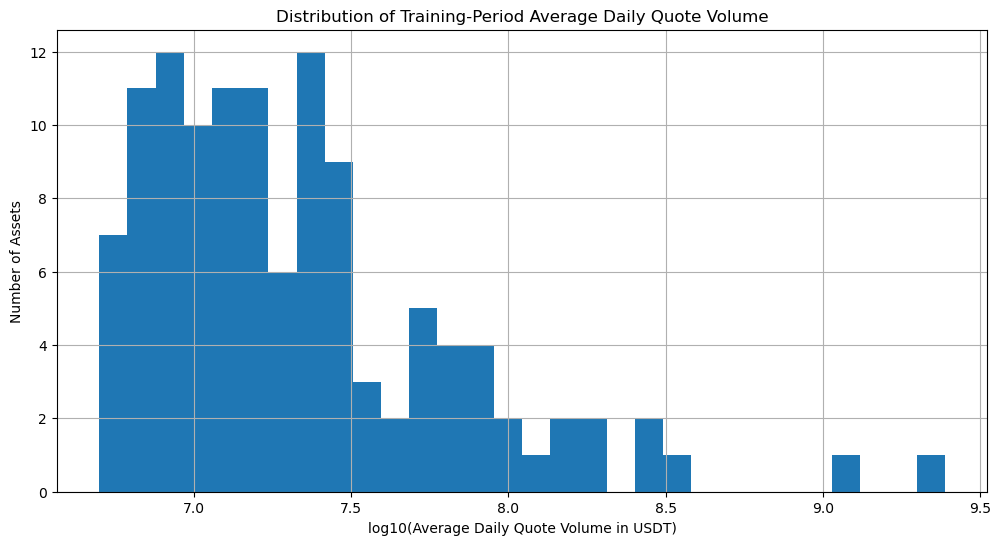

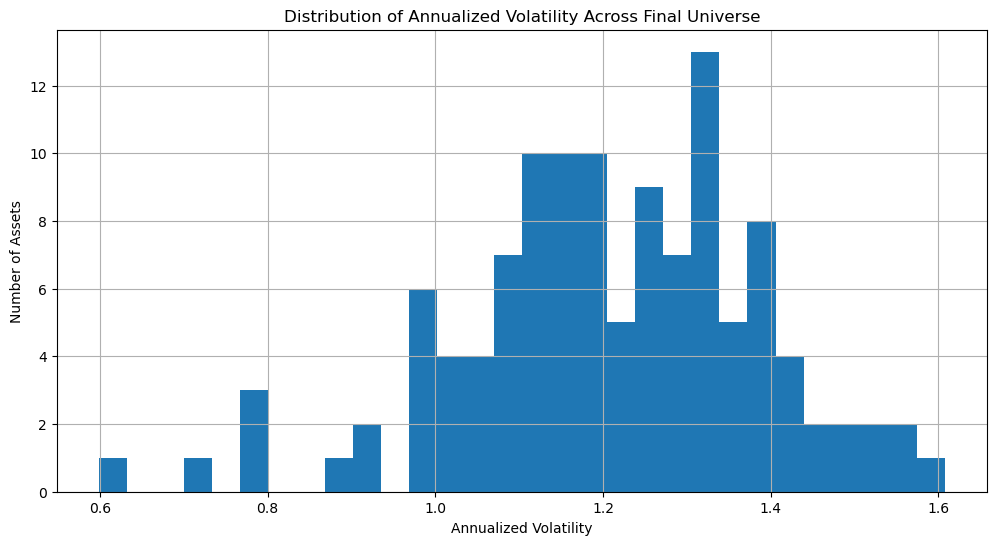

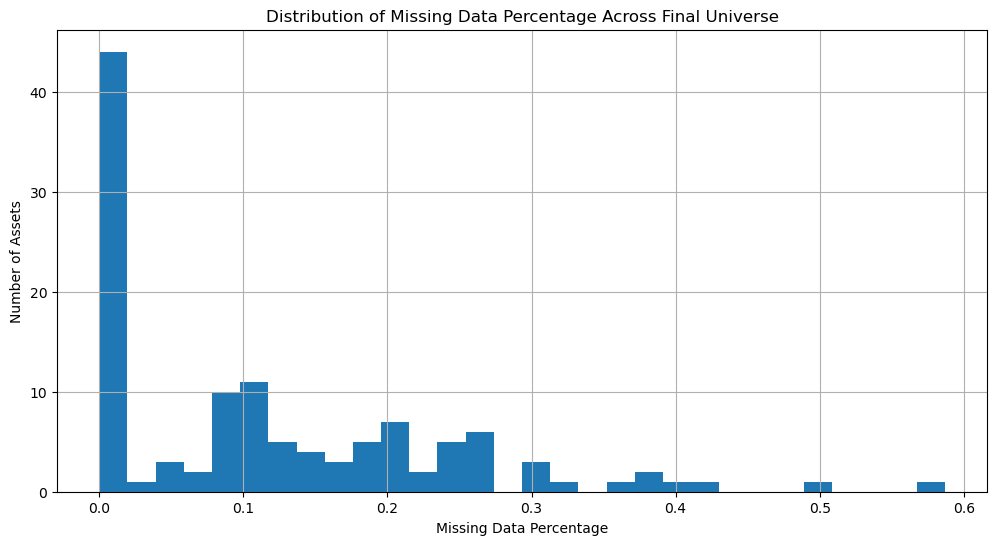

In [26]:
# ============================================================
# Universe Diagnostics Visualizations
# ============================================================

# Liquidity distribution
plt.figure(figsize=(12, 6))
np.log10(final_universe_diagnostics["avg_daily_quote_volume_train"]).hist(bins=30)
plt.title("Distribution of Training-Period Average Daily Quote Volume")
plt.xlabel("log10(Average Daily Quote Volume in USDT)")
plt.ylabel("Number of Assets")
plt.show()

# Volatility distribution
plt.figure(figsize=(12, 6))
final_universe_diagnostics["daily_vol_annualized"].hist(bins=30)
plt.title("Distribution of Annualized Volatility Across Final Universe")
plt.xlabel("Annualized Volatility")
plt.ylabel("Number of Assets")
plt.show()

# Missing data distribution
plt.figure(figsize=(12, 6))
final_universe_diagnostics["missing_pct"].hist(bins=30)
plt.title("Distribution of Missing Data Percentage Across Final Universe")
plt.xlabel("Missing Data Percentage")
plt.ylabel("Number of Assets")
plt.show()

In [27]:
# ============================================================
# Final Universe Cleanup After Diagnostics
# ============================================================

# We remove assets with major data-quality issues identified by the diagnostics.
# These assets have high missingness, zero median volume, or stopped trading
# before the end of the validation sample.

ASSETS_TO_REMOVE = ["DARUSDT", "RNDRUSDT"]

FINAL_SYMBOLS_CLEAN = [s for s in FINAL_SYMBOLS if s not in ASSETS_TO_REMOVE]

print(f"Original final universe size: {len(FINAL_SYMBOLS)}")
print(f"Cleaned final universe size: {len(FINAL_SYMBOLS_CLEAN)}")
print(f"Removed assets: {ASSETS_TO_REMOVE}")

Original final universe size: 119
Cleaned final universe size: 117
Removed assets: ['DARUSDT', 'RNDRUSDT']


In [28]:
# ============================================================
# Apply Final Universe Cleanup to Matrices
# ============================================================

# Apply the final cleaned universe list after removing assets with major
# data-quality issues from the diagnostics step.
FINAL_SYMBOLS = FINAL_SYMBOLS_CLEAN

# ----------------------------
# 4h final universe matrices
# ----------------------------
close_4h = close_4h[FINAL_SYMBOLS]
high_4h = high_4h[FINAL_SYMBOLS]
low_4h = low_4h[FINAL_SYMBOLS]
volume_4h = volume_4h[FINAL_SYMBOLS]
quote_volume_4h = quote_volume_4h[FINAL_SYMBOLS]
num_trades_4h = num_trades_4h[FINAL_SYMBOLS]
taker_buy_base_volume_4h = taker_buy_base_volume_4h[FINAL_SYMBOLS]
taker_buy_quote_volume_4h = taker_buy_quote_volume_4h[FINAL_SYMBOLS]

# Important:
# Use fill_method=None so missing prices do not get forward-filled.
# Forward-filled missing prices can create artificial 0% returns,
# which can make inactive/delisted assets look artificially low-volatility.
returns_4h = close_4h.pct_change(fill_method=None)
log_returns_4h = np.log(close_4h / close_4h.shift(1))

# ----------------------------
# Daily final universe matrices
# ----------------------------
close_1d = close_1d[FINAL_SYMBOLS]
high_1d = high_1d[FINAL_SYMBOLS]
low_1d = low_1d[FINAL_SYMBOLS]
volume_1d = volume_1d[FINAL_SYMBOLS]
quote_volume_1d = quote_volume_1d[FINAL_SYMBOLS]
num_trades_1d = num_trades_1d[FINAL_SYMBOLS]
taker_buy_base_volume_1d = taker_buy_base_volume_1d[FINAL_SYMBOLS]
taker_buy_quote_volume_1d = taker_buy_quote_volume_1d[FINAL_SYMBOLS]

# Important:
# Use fill_method=None here too for the same reason.
returns_1d = close_1d.pct_change(fill_method=None)
log_returns_1d = np.log(close_1d / close_1d.shift(1))

print("Final cleaned universe applied.")
print("Returns recalculated without forward-filling missing prices.")
print(f"Final universe size: {len(FINAL_SYMBOLS)}")
print(f"4h close shape: {close_4h.shape}")
print(f"Daily close shape: {close_1d.shape}")
print(f"4h returns shape: {returns_4h.shape}")
print(f"Daily returns shape: {returns_1d.shape}")

Final cleaned universe applied.
Returns recalculated without forward-filling missing prices.
Final universe size: 117
4h close shape: (14052, 117)
Daily close shape: (2343, 117)
4h returns shape: (14052, 117)
Daily returns shape: (2343, 117)


## 8. Benchmark Portfolio Construction

Before testing active strategies, we construct passive benchmark portfolios. These benchmarks create a fair comparison point for evaluating whether our signals add value beyond simply holding crypto exposure.

We use three benchmarks:
1. BTC buy-and-hold
2. Equal-weight final universe portfolio
3. Top-liquid equal-weight portfolio

In [29]:
# ============================================================
# Benchmark Helper Functions
# ============================================================

def calculate_portfolio_returns(weights, returns):
    """
    Calculates portfolio returns from asset weights and asset returns.

    Important:
    - We shift weights by 1 period to avoid lookahead bias.
    - This means today's portfolio return uses weights decided at the previous timestamp.
    """

    aligned_weights, aligned_returns = weights.align(returns, join="right", axis=0)

    # Shift weights so we only trade using information available before returns occur.
    shifted_weights = aligned_weights.shift(1)

    portfolio_returns = (shifted_weights * aligned_returns).sum(axis=1)

    return portfolio_returns


def calculate_turnover(weights):
    """
    Calculates portfolio turnover.

    Turnover measures how much the portfolio changes from one period to the next.
    Higher turnover means higher transaction costs.
    """

    turnover = weights.diff().abs().sum(axis=1)

    return turnover


def apply_transaction_costs(portfolio_returns, weights, transaction_cost=BASE_TCOST):
    """
    Applies transaction costs based on portfolio turnover.

    Net return = gross return - turnover * transaction cost
    """

    turnover = calculate_turnover(weights)

    # Align turnover with returns
    turnover = turnover.reindex(portfolio_returns.index).fillna(0)

    transaction_cost_paid = turnover * transaction_cost

    net_returns = portfolio_returns - transaction_cost_paid

    return net_returns, turnover, transaction_cost_paid

In [30]:
# ============================================================
# Performance Metric Functions
# ============================================================

def calculate_max_drawdown(returns):
    """
    Calculates maximum drawdown from a return series.
    """

    cumulative = (1 + returns.fillna(0)).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1

    return drawdown.min()


def calculate_performance_metrics(returns, periods_per_year, benchmark_returns=None):
    """
    Calculates key performance metrics for a strategy or benchmark.

    Metrics include:
    - annualized return
    - annualized volatility
    - Sharpe ratio
    - Sortino ratio
    - max drawdown
    - Calmar ratio
    - hit rate
    - skew
    - kurtosis
    - alpha/beta vs benchmark if benchmark is provided
    """

    returns = returns.dropna()

    if len(returns) == 0:
        return pd.Series(dtype=float)

    cumulative_return = (1 + returns).prod() - 1

    annualized_return = (1 + cumulative_return) ** (periods_per_year / len(returns)) - 1
    annualized_volatility = returns.std() * np.sqrt(periods_per_year)

    sharpe = annualized_return / annualized_volatility if annualized_volatility != 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_volatility = downside_returns.std() * np.sqrt(periods_per_year)
    sortino = annualized_return / downside_volatility if downside_volatility != 0 else np.nan

    max_drawdown = calculate_max_drawdown(returns)
    calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.nan

    hit_rate = (returns > 0).mean()

    metrics = {
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_drawdown,
        "Calmar": calmar,
        "Hit Rate": hit_rate,
        "Skew": returns.skew(),
        "Kurtosis": returns.kurtosis()
    }

    if benchmark_returns is not None:
        aligned = pd.concat([returns, benchmark_returns], axis=1).dropna()
        aligned.columns = ["strategy", "benchmark"]

        if len(aligned) > 10:
            X = sm.add_constant(aligned["benchmark"])
            y = aligned["strategy"]

            model = sm.OLS(y, X).fit()

            # Alpha is per-period, so annualize it.
            alpha_periodic = model.params["const"]
            alpha_annualized = alpha_periodic * periods_per_year

            metrics["Alpha Annualized"] = alpha_annualized
            metrics["Beta"] = model.params["benchmark"]
            metrics["Alpha t-stat"] = model.tvalues["const"]
            metrics["Beta t-stat"] = model.tvalues["benchmark"]
            metrics["R-Squared"] = model.rsquared

    return pd.Series(metrics)

In [31]:
# ============================================================
# Benchmark 1: BTC Buy-and-Hold
# ============================================================

# BTC buy-and-hold is the simplest crypto benchmark.
# It answers: can our strategies beat simply holding the dominant crypto asset?

btc_benchmark_4h = returns_4h["BTCUSDT"].copy()
btc_benchmark_1d = returns_1d["BTCUSDT"].copy()

print("BTC benchmark created.")
print(f"4h BTC benchmark length: {len(btc_benchmark_4h.dropna())}")
print(f"Daily BTC benchmark length: {len(btc_benchmark_1d.dropna())}")

BTC benchmark created.
4h BTC benchmark length: 14051
Daily BTC benchmark length: 2342


In [32]:
# ============================================================
# Benchmark 2: Equal-Weight Final Universe Portfolio
# ============================================================

def create_equal_weight_benchmark(returns, rebalance_frequency="1D"):
    """
    Creates an equal-weight benchmark across all available assets.

    At each rebalance date:
    - include assets with valid prices/returns,
    - assign equal weights,
    - hold until the next rebalance.

    This avoids assigning weight to assets before they have data.
    """

    valid_assets = returns.notna()

    # Create raw equal weights whenever asset return data exists.
    raw_weights = valid_assets.div(valid_assets.sum(axis=1), axis=0)

    # Rebalance at chosen frequency.
    rebalance_dates = raw_weights.resample(rebalance_frequency).last().index

    weights = raw_weights.loc[raw_weights.index.intersection(rebalance_dates)]

    # Reindex back to full return frequency and forward-fill weights.
    weights = weights.reindex(returns.index).ffill()

    # If an asset has missing return at a later timestamp, set its weight to zero
    # and renormalize across available assets.
    weights = weights.where(valid_assets, 0)
    weights = weights.div(weights.sum(axis=1), axis=0).fillna(0)

    benchmark_returns = calculate_portfolio_returns(weights, returns)

    return benchmark_returns, weights


equal_weight_benchmark_4h, equal_weight_weights_4h = create_equal_weight_benchmark(
    returns=returns_4h,
    rebalance_frequency="1D"
)

equal_weight_benchmark_1d, equal_weight_weights_1d = create_equal_weight_benchmark(
    returns=returns_1d,
    rebalance_frequency="1D"
)

print("Equal-weight final universe benchmark created.")
print(f"4h benchmark length: {len(equal_weight_benchmark_4h.dropna())}")
print(f"Daily benchmark length: {len(equal_weight_benchmark_1d.dropna())}")

Equal-weight final universe benchmark created.
4h benchmark length: 14052
Daily benchmark length: 2343


In [33]:
# ============================================================
# Benchmark 3: Top-Liquid Equal-Weight Portfolio
# ============================================================

def get_top_liquid_symbols(quote_volume_matrix, top_n=30, train_end_date=TRAIN_END_DATE):
    """
    Selects the top N most liquid symbols based only on training-period
    average daily quote volume.

    This prevents validation-period lookahead.
    """

    train_end = pd.to_datetime(train_end_date, utc=True)

    quote_volume_train = quote_volume_matrix.loc[quote_volume_matrix.index <= train_end]

    avg_daily_quote_volume_train = quote_volume_train.resample("1D").sum().mean()

    top_symbols = avg_daily_quote_volume_train.sort_values(ascending=False).head(top_n).index.tolist()

    return top_symbols


TOP_LIQUID_N = 30

TOP_LIQUID_SYMBOLS = get_top_liquid_symbols(
    quote_volume_matrix=quote_volume_4h,
    top_n=TOP_LIQUID_N
)

print(f"Top {TOP_LIQUID_N} liquid symbols:")
print(TOP_LIQUID_SYMBOLS)

Top 30 liquid symbols:
['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT', 'ADAUSDT', 'SOLUSDT', 'SHIBUSDT', 'DOTUSDT', 'MATICUSDT', 'LINKUSDT', 'LTCUSDT', 'AVAXUSDT', 'TRXUSDT', 'FTMUSDT', 'FILUSDT', 'ETCUSDT', 'EOSUSDT', 'SANDUSDT', 'VETUSDT', 'CHZUSDT', 'BCHUSDT', 'GALAUSDT', 'MANAUSDT', 'ATOMUSDT', 'AXSUSDT', 'NEARUSDT', 'XLMUSDT', 'UNIUSDT', 'SXPUSDT']


In [34]:
# ============================================================
# Create Top-Liquid Equal-Weight Benchmark
# ============================================================

top_liquid_benchmark_4h, top_liquid_weights_4h = create_equal_weight_benchmark(
    returns=returns_4h[TOP_LIQUID_SYMBOLS],
    rebalance_frequency="1D"
)

top_liquid_benchmark_1d, top_liquid_weights_1d = create_equal_weight_benchmark(
    returns=returns_1d[TOP_LIQUID_SYMBOLS],
    rebalance_frequency="1D"
)

print("Top-liquid equal-weight benchmark created.")
print(f"4h benchmark length: {len(top_liquid_benchmark_4h.dropna())}")
print(f"Daily benchmark length: {len(top_liquid_benchmark_1d.dropna())}")

Top-liquid equal-weight benchmark created.
4h benchmark length: 14052
Daily benchmark length: 2343


In [35]:
# ============================================================
# Transaction-Cost Adjusted Benchmark Returns
# ============================================================

# BTC buy-and-hold has effectively only the initial purchase.
# For simplicity in period-return analysis, we treat ongoing turnover as zero.
btc_benchmark_1d_net = btc_benchmark_1d.copy()
btc_benchmark_4h_net = btc_benchmark_4h.copy()

# Equal-weight benchmark transaction costs
equal_weight_benchmark_1d_net, equal_weight_turnover_1d, equal_weight_tcost_1d = apply_transaction_costs(
    portfolio_returns=equal_weight_benchmark_1d,
    weights=equal_weight_weights_1d,
    transaction_cost=BASE_TCOST
)

equal_weight_benchmark_4h_net, equal_weight_turnover_4h, equal_weight_tcost_4h = apply_transaction_costs(
    portfolio_returns=equal_weight_benchmark_4h,
    weights=equal_weight_weights_4h,
    transaction_cost=BASE_TCOST
)

# Top-liquid benchmark transaction costs
top_liquid_benchmark_1d_net, top_liquid_turnover_1d, top_liquid_tcost_1d = apply_transaction_costs(
    portfolio_returns=top_liquid_benchmark_1d,
    weights=top_liquid_weights_1d,
    transaction_cost=BASE_TCOST
)

top_liquid_benchmark_4h_net, top_liquid_turnover_4h, top_liquid_tcost_4h = apply_transaction_costs(
    portfolio_returns=top_liquid_benchmark_4h,
    weights=top_liquid_weights_4h,
    transaction_cost=BASE_TCOST
)

print("Transaction-cost adjusted benchmark returns created.")
print(f"Base transaction cost: {BASE_TCOST:.2%}")

Transaction-cost adjusted benchmark returns created.
Base transaction cost: 0.20%


In [36]:
# ============================================================
# Benchmark Performance Table
# ============================================================

benchmark_returns_1d = {
    "BTC Buy & Hold": btc_benchmark_1d,
    "Equal-Weight Universe Gross": equal_weight_benchmark_1d,
    "Equal-Weight Universe Net": equal_weight_benchmark_1d_net,
    "Top-Liquid Equal-Weight Gross": top_liquid_benchmark_1d,
    "Top-Liquid Equal-Weight Net": top_liquid_benchmark_1d_net
}

benchmark_performance_1d = pd.DataFrame({
    name: calculate_performance_metrics(
        returns=ret,
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=btc_benchmark_1d
    )
    for name, ret in benchmark_returns_1d.items()
}).T

display(benchmark_performance_1d)

,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Hit Rate,Skew,Kurtosis,Alpha Annualized,Beta,Alpha t-stat,Beta t-stat,R-Squared
BTC Buy & Hold,9.297484,0.438248,0.610798,0.717501,0.960436,-0.766293,0.571907,0.509821,-0.562783,13.136624,0.000000,1.000000,5.655070,"109,645,633,972,129,296.000000",1.000000
Equal-Weight Universe Gross,4.996872,0.321867,0.868669,0.370528,0.455268,-0.889443,0.361874,0.551003,-1.035801,9.015731,0.048424,1.128719,0.231661,63.068885,0.629611
Equal-Weight Universe Net,4.960725,0.320622,0.868664,0.369098,0.453558,-0.889524,0.360442,0.551003,-1.035802,9.015793,0.047466,1.128740,0.227085,63.073161,0.629643
Top-Liquid Equal-Weight Gross,16.126392,0.556626,0.829160,0.671314,0.858031,-0.817242,0.681104,0.548869,-0.747177,9.031741,0.185647,1.105681,0.975635,67.868530,0.663122
Top-Liquid Equal-Weight Net,16.048710,0.555524,0.829158,0.669986,0.856433,-0.817242,0.679755,0.548869,-0.747120,9.031668,0.184925,1.105702,0.971880,67.872949,0.663151


In [37]:
# ============================================================
# Train / Validation Benchmark Performance
# ============================================================

def split_returns_train_validation(returns):
    """
    Splits a return series into training and validation periods.
    """

    train_returns = returns.loc[returns.index <= pd.to_datetime(TRAIN_END_DATE, utc=True)]
    validation_returns = returns.loc[returns.index >= pd.to_datetime(VALIDATION_START_DATE, utc=True)]

    return train_returns, validation_returns


benchmark_train_validation_results = {}

for name, ret in benchmark_returns_1d.items():
    train_ret, validation_ret = split_returns_train_validation(ret)

    benchmark_train_validation_results[(name, "Train")] = calculate_performance_metrics(
        returns=train_ret,
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=btc_benchmark_1d.loc[train_ret.index]
    )

    benchmark_train_validation_results[(name, "Validation")] = calculate_performance_metrics(
        returns=validation_ret,
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=btc_benchmark_1d.loc[validation_ret.index]
    )


benchmark_train_validation_table = pd.DataFrame(benchmark_train_validation_results).T

display(benchmark_train_validation_table)

Cumulative Return  Annualized Return  Annualized Volatility    Sharpe  \
BTC Buy & Hold                Train                4.872026           0.556672               0.677313  0.821882   
                              Validation           0.753651           0.261687               0.481062  0.543977   
Equal-Weight Universe Gross   Train               16.847909           1.054389               0.930036  1.133707   
                              Validation          -0.664001          -0.363229               0.754621 -0.481340   
Equal-Weight Universe Net     Train               16.754324           1.051692               0.930030  1.130816   
                              Validation          -0.664266          -0.363437               0.754621 -0.481615   
Top-Liquid Equal-Weight Gross Train               28.832907           1.335724               0.895692  1.491276   
                              Validation          -0.425923          -0.205207               0.703881 -0.291536   
Top-Liquid Equal-Weight Net   Train               28.714278           1.333400               0.895691  1.488684   
                              Validation          -0.426245          -0.205392               0.703881 -0.291799   

                                           Sortino  Max Drawdown    Calmar  Hit Rate      Skew  Kurtosis  \
BTC Buy & Hold                Train       1.070278     -0.766293  0.726448  0.510274 -0.738376 13.193564   
                              Validation  0.826478     -0.495343  0.528294  0.509070  0.284327  3.422465   
Equal-Weight Universe Gross   Train       1.319284     -0.845382  1.247234  0.575633 -1.228890 10.190905   
                              Validation -0.668865     -0.834213 -0.435415  0.510204 -0.480584  3.123694   
Equal-Weight Universe Net     Train       1.316244     -0.845382  1.244044  0.575633 -1.228870 10.190938   
                              Validation -0.669247     -0.834288 -0.435626  0.510204 -0.480587  3.123614   
Top-Liquid Equal-Weight Gross Train       1.816328     -0.817242  1.634430  0.577002 -0.908525  9.920567   
                              Validation -0.417234     -0.767880 -0.267238  0.502268 -0.253867  2.874303   
Top-Liquid Equal-Weight Net   Train       1.813588     -0.817242  1.631586  0.577002 -0.908440  9.920392   
                              Validation -0.417613     -0.767980 -0.267444  0.502268 -0.253838  2.874297   

                                          Alpha Annualized     Beta  Alpha t-stat                    Beta t-stat  \
BTC Buy & Hold                Train               0.000000 1.000000      2.723033  34,322,428,187,172,824.000000   
                              Validation          0.000000 1.000000      2.480676 133,086,054,258,363,600.000000   
Equal-Weight Universe Gross   Train               0.428462 1.104953      1.547826                      51.705596   
                              Validation         -0.580272 1.204375     -1.863223                      35.547324   
Equal-Weight Universe Net     Train               0.427122 1.104980      1.543083                      51.710102   
                              Validation         -0.580600 1.204383     -1.864294                      35.547899   
Top-Liquid Equal-Weight Gross Train               0.531422 1.085518      2.071926                      54.822085   
                              Validation         -0.386338 1.169717     -1.418411                      39.475491   
Top-Liquid Equal-Weight Net   Train               0.530403 1.085546      2.068075                      54.826701   
                              Validation         -0.386572 1.169720     -1.419278                      39.475829   

                                          R-Squared  
BTC Buy & Hold                Train        1.000000  
                              Validation   1.000000  
Equal-Weight Universe Gross   Train        0.647099  
                              Validation   0.589478  
Equal-Weight Universe Net     Train     

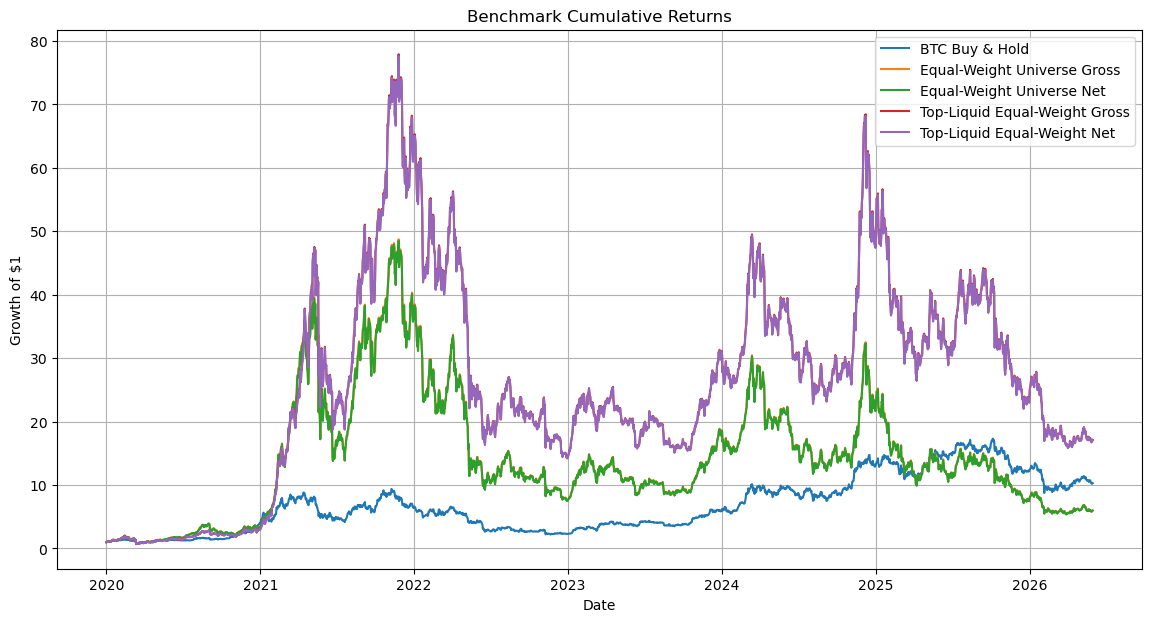

In [38]:
# ============================================================
# Plot Benchmark Cumulative Returns
# ============================================================

benchmark_cumulative_1d = pd.DataFrame({
    name: (1 + ret.fillna(0)).cumprod()
    for name, ret in benchmark_returns_1d.items()
})

plt.figure(figsize=(14, 7))
for col in benchmark_cumulative_1d.columns:
    plt.plot(benchmark_cumulative_1d.index, benchmark_cumulative_1d[col], label=col)

plt.title("Benchmark Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

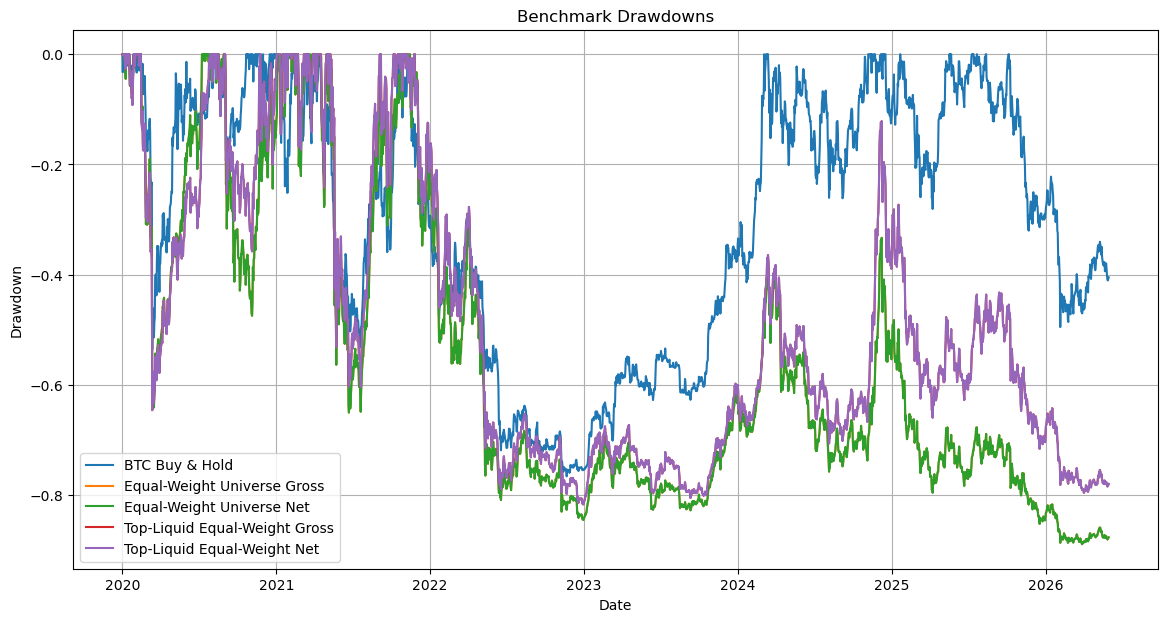

In [39]:
# ============================================================
# Plot Benchmark Drawdowns
# ============================================================

def calculate_drawdown_series(returns):
    """
    Returns full drawdown series.
    """

    cumulative = (1 + returns.fillna(0)).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1

    return drawdown


benchmark_drawdowns_1d = pd.DataFrame({
    name: calculate_drawdown_series(ret)
    for name, ret in benchmark_returns_1d.items()
})

plt.figure(figsize=(14, 7))
for col in benchmark_drawdowns_1d.columns:
    plt.plot(benchmark_drawdowns_1d.index, benchmark_drawdowns_1d[col], label=col)

plt.title("Benchmark Drawdowns")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

## 9. Signal Evaluation Framework

Before constructing active portfolios, we first evaluate whether individual signals predict future crypto returns. This separates signal research from portfolio construction.

For each signal, we test:
- average forward returns by signal bucket,
- Information Coefficient,
- rank Information Coefficient,
- long-only top-quantile returns,
- long-short top-minus-bottom returns,
- train vs validation stability.

This helps identify which signals are worth turning into trading strategies.

In [40]:
# ============================================================
# Signal Evaluation Helper Functions
# ============================================================

def calculate_forward_returns(returns, horizon=1):
    """
    Calculates forward returns from time t to time t+horizon.

    The value at time t represents the return earned after the signal is observed.
    """

    forward_returns = (1 + returns).shift(-1).rolling(window=horizon).apply(np.prod, raw=True) - 1
    forward_returns = forward_returns.shift(-(horizon - 1))

    return forward_returns


def winsorize_dataframe(df, lower=0.01, upper=0.99):
    """
    Winsorizes each timestamp cross-section to reduce the effect of extreme outliers.
    """

    return df.apply(
        lambda row: row.clip(row.quantile(lower), row.quantile(upper)),
        axis=1
    )


def cross_sectional_zscore(df):
    """
    Converts each timestamp cross-section into z-scores.
    """

    mean = df.mean(axis=1)
    std = df.std(axis=1)

    z = df.sub(mean, axis=0).div(std, axis=0)

    return z.replace([np.inf, -np.inf], np.nan)

In [41]:
# ============================================================
# Information Coefficient Functions
# ============================================================

def calculate_information_coefficient(signal, forward_returns, method="pearson"):
    """
    Calculates the cross-sectional Information Coefficient through time.

    IC measures whether higher signal values are associated with higher future returns.

    method='pearson' measures linear correlation.
    method='spearman' measures rank correlation.
    """

    signal_aligned, returns_aligned = signal.align(forward_returns, join="inner", axis=0)

    ic_values = []

    for date in signal_aligned.index:
        x = signal_aligned.loc[date]
        y = returns_aligned.loc[date]

        valid = x.notna() & y.notna()

        if valid.sum() < 5:
            ic_values.append(np.nan)
            continue

        if method == "pearson":
            ic = x[valid].corr(y[valid], method="pearson")
        elif method == "spearman":
            ic = x[valid].corr(y[valid], method="spearman")
        else:
            raise ValueError("method must be 'pearson' or 'spearman'")

        ic_values.append(ic)

    return pd.Series(ic_values, index=signal_aligned.index)


def summarize_ic(ic_series, periods_per_year):
    """
    Summarizes IC behavior.

    Mean IC tells us average predictive relationship.
    IC t-stat tells us whether the relationship is statistically meaningful.
    ICIR is mean IC divided by IC volatility.
    """

    ic = ic_series.dropna()

    if len(ic) == 0:
        return pd.Series(dtype=float)

    mean_ic = ic.mean()
    std_ic = ic.std()
    ic_tstat = mean_ic / (std_ic / np.sqrt(len(ic))) if std_ic != 0 else np.nan
    icir = mean_ic / std_ic if std_ic != 0 else np.nan

    return pd.Series({
        "Mean IC": mean_ic,
        "IC Std": std_ic,
        "IC t-stat": ic_tstat,
        "ICIR": icir,
        "Positive IC %": (ic > 0).mean(),
        "Num Observations": len(ic)
    })

In [42]:
# ============================================================
# Quantile Return Testing
# ============================================================

def calculate_quantile_forward_returns(signal, forward_returns, n_quantiles=5):
    """
    Calculates average forward returns by signal quantile.

    For each date:
    - rank assets by signal,
    - split into quantiles,
    - calculate next-period average return for each quantile.

    Quantile 1 = lowest signal assets.
    Quantile n = highest signal assets.
    """

    signal_aligned, returns_aligned = signal.align(forward_returns, join="inner", axis=0)

    quantile_returns = []

    for date in signal_aligned.index:
        s = signal_aligned.loc[date]
        r = returns_aligned.loc[date]

        valid = s.notna() & r.notna()

        if valid.sum() < n_quantiles * 2:
            continue

        s_valid = s[valid]
        r_valid = r[valid]

        try:
            quantiles = pd.qcut(
                s_valid.rank(method="first"),
                q=n_quantiles,
                labels=False
            ) + 1
        except ValueError:
            continue

        date_result = r_valid.groupby(quantiles).mean()
        date_result.name = date

        quantile_returns.append(date_result)

    if len(quantile_returns) == 0:
        return pd.DataFrame()

    quantile_returns = pd.DataFrame(quantile_returns)

    quantile_returns.columns = [f"Q{int(col)}" for col in quantile_returns.columns]

    return quantile_returns


def summarize_quantile_returns(quantile_returns, periods_per_year):
    """
    Summarizes average forward returns by quantile.

    Also calculates top-minus-bottom spread.
    """

    if quantile_returns.empty:
        return pd.Series(dtype=float)

    avg_returns = quantile_returns.mean()

    top_col = quantile_returns.columns[-1]
    bottom_col = quantile_returns.columns[0]

    spread = quantile_returns[top_col] - quantile_returns[bottom_col]

    summary = avg_returns.copy()
    summary["Top-Bottom Spread"] = spread.mean()
    summary["Top-Bottom t-stat"] = (
        spread.mean() / (spread.std() / np.sqrt(len(spread.dropna())))
        if spread.std() != 0 else np.nan
    )
    summary["Top-Bottom Sharpe"] = (
        spread.mean() / spread.std() * np.sqrt(periods_per_year)
        if spread.std() != 0 else np.nan
    )

    return summary

In [43]:
# ============================================================
# Complete Signal Evaluation Function
# ============================================================

def evaluate_signal(
    signal,
    returns,
    signal_name,
    horizon=1,
    periods_per_year=BARS_PER_YEAR_1D,
    n_quantiles=5,
    winsorize=True,
    zscore=True
):
    """
    Evaluates a signal's ability to predict future returns.

    Outputs:
    - IC summary
    - rank IC summary
    - quantile return summary
    - quantile return time series
    """

    # Clean and normalize signal
    clean_signal = signal.copy()

    if winsorize:
        clean_signal = winsorize_dataframe(clean_signal)

    if zscore:
        clean_signal = cross_sectional_zscore(clean_signal)

    # Future returns after signal is observed
    forward_returns = calculate_forward_returns(returns, horizon=horizon)

    # Information coefficients
    ic = calculate_information_coefficient(clean_signal, forward_returns, method="pearson")
    rank_ic = calculate_information_coefficient(clean_signal, forward_returns, method="spearman")

    ic_summary = summarize_ic(ic, periods_per_year)
    rank_ic_summary = summarize_ic(rank_ic, periods_per_year)

    # Quantile returns
    quantile_returns = calculate_quantile_forward_returns(
        signal=clean_signal,
        forward_returns=forward_returns,
        n_quantiles=n_quantiles
    )

    quantile_summary = summarize_quantile_returns(
        quantile_returns=quantile_returns,
        periods_per_year=periods_per_year
    )

    result = {
        "signal_name": signal_name,
        "horizon": horizon,
        "clean_signal": clean_signal,
        "forward_returns": forward_returns,
        "ic": ic,
        "rank_ic": rank_ic,
        "ic_summary": ic_summary,
        "rank_ic_summary": rank_ic_summary,
        "quantile_returns": quantile_returns,
        "quantile_summary": quantile_summary
    }

    print(f"Signal evaluated: {signal_name}")
    print(f"Forward return horizon: {horizon}")
    print()
    print("IC Summary:")
    display(ic_summary.to_frame().T)
    print()
    print("Rank IC Summary:")
    display(rank_ic_summary.to_frame().T)
    print()
    print("Quantile Return Summary:")
    display(quantile_summary.to_frame().T)

    return result

In [44]:
# ============================================================
# Train / Validation Signal Evaluation
# ============================================================

def evaluate_signal_train_validation(
    signal,
    returns,
    signal_name,
    horizon=1,
    periods_per_year=BARS_PER_YEAR_1D,
    n_quantiles=5
):
    """
    Evaluates a signal separately in training and validation periods.
    """

    train_mask = signal.index <= pd.to_datetime(TRAIN_END_DATE, utc=True)
    validation_mask = signal.index >= pd.to_datetime(VALIDATION_START_DATE, utc=True)

    signal_train = signal.loc[train_mask]
    returns_train = returns.loc[train_mask]

    signal_validation = signal.loc[validation_mask]
    returns_validation = returns.loc[validation_mask]

    print("=" * 80)
    print(f"{signal_name}: TRAINING PERIOD")
    print("=" * 80)

    train_result = evaluate_signal(
        signal=signal_train,
        returns=returns_train,
        signal_name=f"{signal_name} Train",
        horizon=horizon,
        periods_per_year=periods_per_year,
        n_quantiles=n_quantiles
    )

    print("=" * 80)
    print(f"{signal_name}: VALIDATION PERIOD")
    print("=" * 80)

    validation_result = evaluate_signal(
        signal=signal_validation,
        returns=returns_validation,
        signal_name=f"{signal_name} Validation",
        horizon=horizon,
        periods_per_year=periods_per_year,
        n_quantiles=n_quantiles
    )

    return {
        "train": train_result,
        "validation": validation_result
    }

## 10. First Signal Test: Daily Time-Series Momentum

As a first test, we evaluate whether recent daily returns predict future daily returns. This is a simple baseline momentum signal that will help validate the signal evaluation framework before testing more advanced signals like channel breakouts, moving-average crossovers, volatility filters, and order-flow signals.

In [45]:
# ============================================================
# First Signal: 30-Day Time-Series Momentum
# ============================================================

# Signal definition:
# Past 30-day return for each asset.
# Higher values mean the asset has stronger recent momentum.

momentum_30d_signal = close_1d.pct_change(30, fill_method=None)

momentum_30d_results = evaluate_signal_train_validation(
    signal=momentum_30d_signal,
    returns=returns_1d,
    signal_name="30-Day Time-Series Momentum",
    horizon=1,
    periods_per_year=BARS_PER_YEAR_1D,
    n_quantiles=5
)

30-Day Time-Series Momentum: TRAINING PERIOD
Signal evaluated: 30-Day Time-Series Momentum Train
Forward return horizon: 1

IC Summary:


,Mean IC,IC Std,IC t-stat,ICIR,Positive IC %,Num Observations
0,-0.001292,0.220226,-0.221876,-0.005867,0.490909,"1,430.000000"



Rank IC Summary:


,Mean IC,IC Std,IC t-stat,ICIR,Positive IC %,Num Observations
0,-0.051220,0.189540,-10.218990,-0.270234,0.386713,"1,430.000000"



Quantile Return Summary:


...

,Mean IC,IC Std,IC t-stat,ICIR,Positive IC %,Num Observations
0,-0.007511,0.219776,-1.014393,-0.034176,0.497162,881.000000



Rank IC Summary:


,Mean IC,IC Std,IC t-stat,ICIR,Positive IC %,Num Observations
0,-0.047655,0.188891,-7.488307,-0.252287,0.397276,881.000000



Quantile Return Summary:


,Q1,Q2,Q3,Q4,Q5,Top-Bottom Spread,Top-Bottom t-stat,Top-Bottom Sharpe
0,-0.000124,-0.000106,-0.000277,-0.000922,-0.001038,-0.000914,-1.442745,-0.928641


## 11. Signal Grid Testing

The first momentum test showed that simple 30-day momentum was not strong enough as a standalone predictor. We now expand the signal research process by testing a grid of candidate signals across momentum, reversal, trend-following, volatility-adjusted returns, liquidity, and order-flow features.

The goal is not to build a final strategy yet. The goal is to identify which raw signals have predictive value in training and whether that predictive value survives in validation.

In [46]:
# ============================================================
# Candidate Signal Library - Safe Missing Data Version
# ============================================================

def create_signal_library(close, high, low, volume, quote_volume, taker_buy_base_volume):
    """
    Creates a dictionary of candidate signals.

    Important:
    We use pct_change(fill_method=None) so missing prices do not get
    forward-filled into artificial 0% returns.
    """

    signals = {}

    returns = close.pct_change(fill_method=None)

    # ------------------------------------------------------------
    # 1. Time-Series Momentum Signals
    # ------------------------------------------------------------
    for window in [7, 14, 30, 60, 90, 180]:
        signals[f"TS_Momentum_{window}D"] = close.pct_change(window, fill_method=None)

    # ------------------------------------------------------------
    # 2. Short-Term Reversal Signals
    # ------------------------------------------------------------
    for window in [1, 3, 7, 14]:
        signals[f"Reversal_{window}D"] = -close.pct_change(window, fill_method=None)

    # ------------------------------------------------------------
    # 3. Volatility-Adjusted Momentum
    # ------------------------------------------------------------
    for window in [30, 60, 90]:
        realized_vol = returns.rolling(window, min_periods=int(window * 0.8)).std()
        momentum = close.pct_change(window, fill_method=None)
        signals[f"Vol_Adjusted_Momentum_{window}D"] = momentum / realized_vol

    # ------------------------------------------------------------
    # 4. Moving Average Trend Signals
    # ------------------------------------------------------------
    ma_pairs = [(5, 20), (10, 50), (20, 100), (50, 200)]

    for short_window, long_window in ma_pairs:
        short_ma = close.rolling(short_window, min_periods=int(short_window * 0.8)).mean()
        long_ma = close.rolling(long_window, min_periods=int(long_window * 0.8)).mean()

        signals[f"MA_Crossover_{short_window}_{long_window}"] = short_ma / long_ma - 1

    # ------------------------------------------------------------
    # 5. Channel Breakout Signals
    # ------------------------------------------------------------
    for window in [20, 55, 100]:
        rolling_high = high.rolling(window, min_periods=int(window * 0.8)).max()
        rolling_low = low.rolling(window, min_periods=int(window * 0.8)).min()

        channel_position = (close - rolling_low) / (rolling_high - rolling_low)
        signals[f"Channel_Position_{window}D"] = channel_position

        previous_high = high.rolling(window, min_periods=int(window * 0.8)).max().shift(1)
        signals[f"Channel_Breakout_{window}D"] = (close > previous_high).astype(float)

    # ------------------------------------------------------------
    # 6. Volatility Signals
    # ------------------------------------------------------------
    for window in [14, 30, 60]:
        realized_vol = returns.rolling(window, min_periods=int(window * 0.8)).std()
        signals[f"Low_Volatility_{window}D"] = -realized_vol

    # ------------------------------------------------------------
    # 7. Liquidity / Volume Signals
    # ------------------------------------------------------------
    for window in [20, 60]:
        avg_quote_volume = quote_volume.rolling(window, min_periods=int(window * 0.8)).mean()
        volume_ratio = quote_volume / avg_quote_volume
        signals[f"Volume_Ratio_{window}D"] = volume_ratio

    # ------------------------------------------------------------
    # 8. Taker Buy Pressure / Order Flow
    # ------------------------------------------------------------
    taker_buy_pressure = taker_buy_base_volume / volume

    signals["Taker_Buy_Pressure"] = taker_buy_pressure
    signals["Order_Flow_Imbalance"] = 2 * taker_buy_pressure - 1

    return signals


daily_signals = create_signal_library(
    close=close_1d,
    high=high_1d,
    low=low_1d,
    volume=volume_1d,
    quote_volume=quote_volume_1d,
    taker_buy_base_volume=taker_buy_base_volume_1d
)

print(f"Number of candidate daily signals created: {len(daily_signals)}")
print(list(daily_signals.keys()))

Number of candidate daily signals created: 30
['TS_Momentum_7D', 'TS_Momentum_14D', 'TS_Momentum_30D', 'TS_Momentum_60D', 'TS_Momentum_90D', 'TS_Momentum_180D', 'Reversal_1D', 'Reversal_3D', 'Reversal_7D', 'Reversal_14D', 'Vol_Adjusted_Momentum_30D', 'Vol_Adjusted_Momentum_60D', 'Vol_Adjusted_Momentum_90D', 'MA_Crossover_5_20', 'MA_Crossover_10_50', 'MA_Crossover_20_100', 'MA_Crossover_50_200', 'Channel_Position_20D', 'Channel_Breakout_20D', 'Channel_Position_55D', 'Channel_Breakout_55D', 'Channel_Position_100D', 'Channel_Breakout_100D', 'Low_Volatility_14D', 'Low_Volatility_30D', 'Low_Volatility_60D', 'Volume_Ratio_20D', 'Volume_Ratio_60D', 'Taker_Buy_Pressure', 'Order_Flow_Imbalance']


In [47]:
# ============================================================
# Compact Signal Evaluation for Grid Testing
# ============================================================

def evaluate_signal_compact(
    signal,
    returns,
    signal_name,
    horizon=1,
    periods_per_year=BARS_PER_YEAR_1D,
    n_quantiles=5,
    winsorize=True,
    zscore=True
):
    """
    Compact version of signal evaluation for comparing many signals.

    Returns one row of summary statistics.
    """

    clean_signal = signal.copy()

    if winsorize:
        clean_signal = winsorize_dataframe(clean_signal)

    if zscore:
        clean_signal = cross_sectional_zscore(clean_signal)

    forward_returns = calculate_forward_returns(returns, horizon=horizon)

    ic = calculate_information_coefficient(clean_signal, forward_returns, method="pearson")
    rank_ic = calculate_information_coefficient(clean_signal, forward_returns, method="spearman")

    ic_summary = summarize_ic(ic, periods_per_year)
    rank_ic_summary = summarize_ic(rank_ic, periods_per_year)

    quantile_returns = calculate_quantile_forward_returns(
        signal=clean_signal,
        forward_returns=forward_returns,
        n_quantiles=n_quantiles
    )

    quantile_summary = summarize_quantile_returns(
        quantile_returns=quantile_returns,
        periods_per_year=periods_per_year
    )

    row = {
        "Signal": signal_name,
        "Horizon": horizon,

        "Mean IC": ic_summary.get("Mean IC", np.nan),
        "IC t-stat": ic_summary.get("IC t-stat", np.nan),
        "Positive IC %": ic_summary.get("Positive IC %", np.nan),

        "Mean Rank IC": rank_ic_summary.get("Mean IC", np.nan),
        "Rank IC t-stat": rank_ic_summary.get("IC t-stat", np.nan),
        "Positive Rank IC %": rank_ic_summary.get("Positive IC %", np.nan),

        "Top-Bottom Spread": quantile_summary.get("Top-Bottom Spread", np.nan),
        "Top-Bottom t-stat": quantile_summary.get("Top-Bottom t-stat", np.nan),
        "Top-Bottom Sharpe": quantile_summary.get("Top-Bottom Sharpe", np.nan),

        "Q1": quantile_summary.get("Q1", np.nan),
        "Q5": quantile_summary.get("Q5", np.nan),
        "Num IC Observations": ic_summary.get("Num Observations", np.nan)
    }

    return row

In [48]:
# ============================================================
# Compact Train / Validation Signal Evaluation
# ============================================================

def evaluate_signal_compact_train_validation(
    signal,
    returns,
    signal_name,
    horizon=1,
    periods_per_year=BARS_PER_YEAR_1D,
    n_quantiles=5
):
    """
    Evaluates one signal separately in train and validation,
    returning two rows.
    """

    train_cutoff = pd.to_datetime(TRAIN_END_DATE, utc=True)
    validation_start = pd.to_datetime(VALIDATION_START_DATE, utc=True)

    signal_train = signal.loc[signal.index <= train_cutoff]
    returns_train = returns.loc[returns.index <= train_cutoff]

    signal_validation = signal.loc[signal.index >= validation_start]
    returns_validation = returns.loc[returns.index >= validation_start]

    train_row = evaluate_signal_compact(
        signal=signal_train,
        returns=returns_train,
        signal_name=signal_name,
        horizon=horizon,
        periods_per_year=periods_per_year,
        n_quantiles=n_quantiles
    )
    train_row["Sample"] = "Train"

    validation_row = evaluate_signal_compact(
        signal=signal_validation,
        returns=returns_validation,
        signal_name=signal_name,
        horizon=horizon,
        periods_per_year=periods_per_year,
        n_quantiles=n_quantiles
    )
    validation_row["Sample"] = "Validation"

    return train_row, validation_row

In [49]:
# ============================================================
# Run Daily Signal Grid
# ============================================================

daily_signal_grid_results = []

# We start with next-day forward returns.
# Later, we can test 3-day, 7-day, and 30-day holding horizons.
FORWARD_HORIZON = 1

for signal_name, signal_df in daily_signals.items():
    print(f"Evaluating {signal_name}...")

    train_row, validation_row = evaluate_signal_compact_train_validation(
        signal=signal_df,
        returns=returns_1d,
        signal_name=signal_name,
        horizon=FORWARD_HORIZON,
        periods_per_year=BARS_PER_YEAR_1D,
        n_quantiles=5
    )

    daily_signal_grid_results.append(train_row)
    daily_signal_grid_results.append(validation_row)


daily_signal_grid_table = pd.DataFrame(daily_signal_grid_results)

# Put columns in a cleaner order
ordered_cols = [
    "Signal", "Sample", "Horizon",
    "Mean IC", "IC t-stat", "Positive IC %",
    "Mean Rank IC", "Rank IC t-stat", "Positive Rank IC %",
    "Top-Bottom Spread", "Top-Bottom t-stat", "Top-Bottom Sharpe",
    "Q1", "Q5", "Num IC Observations"
]

daily_signal_grid_table = daily_signal_grid_table[ordered_cols]

display(daily_signal_grid_table)

Evaluating TS_Momentum_7D...
Evaluating TS_Momentum_14D...
Evaluating TS_Momentum_30D...
Evaluating TS_Momentum_60D...
Evaluating TS_Momentum_90D...
Evaluating TS_Momentum_180D...
Evaluating Reversal_1D...
Evaluating Reversal_3D...
Evaluating Reversal_7D...
Evaluating Reversal_14D...
Evaluating Vol_Adjusted_Momentum_30D...
Evaluating Vol_Adjusted_Momentum_60D...
Evaluating Vol_Adjusted_Momentum_90D...
Evaluating MA_Crossover_5_20...
Evaluating MA_Crossover_10_50...
Evaluating MA_Crossover_20_100...
Evaluating MA_Crossover_50_200...
Evaluating Channel_Position_20D...
Evaluating Channel_Breakout_20D...
Evaluating Channel_Position_55D...
Evaluating Channel_Breakout_55D...
Evaluating Channel_Position_100D...
Evaluating Channel_Breakout_100D...
Evaluating Low_Volatility_14D...
Evaluating Low_Volatility_30D...
Evaluating Low_Volatility_60D...
Evaluating Volume_Ratio_20D...
Evaluating Volume_Ratio_60D...
Evaluating Taker_Buy_Pressure...
Evaluating Order_Flow_Imbalance...


,Signal,Sample,Horizon,Mean IC,IC t-stat,Positive IC %,Mean Rank IC,Rank IC t-stat,Positive Rank IC %,Top-Bottom Spread,Top-Bottom t-stat,Top-Bottom Sharpe,Q1,Q5,Num IC Observations
0,TS_Momentum_7D,Train,1,-0.008620,-1.394551,0.463868,-0.061532,-12.353692,0.370268,0.001024,1.317303,0.660236,0.002690,0.003713,"1,453.000000"
1,TS_Momentum_7D,Validation,1,-0.018877,-2.521473,0.472191,-0.052265,-8.480056,0.395006,-0.000341,-0.542572,-0.349233,-0.000568,-0.000910,881.000000
2,TS_Momentum_14D,Train,1,-0.007218,-1.195953,0.486169,-0.063245,-12.775993,0.364454,0.000045,0.057874,0.029077,0.003363,0.003408,"1,446.000000"
3,TS_Momentum_14D,Validation,1,-0.015637,-2.142155,0.452894,-0.046487,-7.600041,0.387060,-0.000429,-0.683739,-0.440097,-0.000362,-0.000792,881.000000
4,TS_Momentum_30D,Train,1,-0.001429,-0.245166,0.490909,-0.051189,-10.214808,0.386713,0.000917,1.224127,0.618450,0.002742,0.003659,"1,430.000000"
5,TS_Momentum_30D,Validation,1,-0.007993,-1.077471,0.496027,-0.047649,-7.487345,0.397276,-0.000914,-1.442745,-0.928641,-0.000124,-0.001038,881.000000
6,TS_Momentum_60D,Train,1,-0.006404,-1.163505,0.461429,-0.050346,-10.352689,0.386429,0.000106,0.148505,0.075827,0.003066,0.003171,"1,400.000000"
7,TS_Momentum_60D,Validation,1,-0.001622,-0.226449,0.491487,-0.036478,-5.609909,0.429058,-0.000670,-1.069397,-0.688331,-0.000159,-0.000829,881.000000
8,TS_Momentum_90D,Train,1,-0.004746,-0.888442,0.470803,-0.048795,-9.926465,0.382482,-0.000380,-0.547668,-0.282685,0.003735,0.003355,"1,370.000000"
9,TS_Momentum_90D,Validation,1,0.001856,0.264163,0.511918,-0.026934,-4.062540,0.465380,-0.000709,-1.087876,-0.700226,-0.000182,-0.000891,881.000000


In [50]:
# ============================================================
# Rank Signals by Validation Performance
# ============================================================

validation_signal_rankings = (
    daily_signal_grid_table[daily_signal_grid_table["Sample"] == "Validation"]
    .sort_values("Top-Bottom Sharpe", ascending=False)
)

print("Top validation signals by Top-Bottom Sharpe:")
display(validation_signal_rankings.head(15))

print("Worst validation signals by Top-Bottom Sharpe:")
display(validation_signal_rankings.tail(15))

Top validation signals by Top-Bottom Sharpe:


,Signal,Sample,Horizon,Mean IC,IC t-stat,Positive IC %,Mean Rank IC,Rank IC t-stat,Positive Rank IC %,Top-Bottom Spread,Top-Bottom t-stat,Top-Bottom Sharpe,Q1,Q5,Num IC Observations
51,Low_Volatility_60D,Validation,1,0.032376,4.475522,0.568672,0.066153,8.214293,0.616345,0.001375,2.066452,1.330099,-0.001308,0.000068,881.000000
47,Low_Volatility_14D,Validation,1,0.042000,5.442074,0.583428,0.071202,9.221662,0.620885,0.001345,2.007342,1.292051,-0.001324,0.000021,881.000000
49,Low_Volatility_30D,Validation,1,0.036192,4.798154,0.578888,0.071127,8.963522,0.623156,0.000970,1.456983,0.937806,-0.001126,-0.000156,881.000000
35,Channel_Position_20D,Validation,1,0.005332,0.916467,0.514188,-0.028005,-5.308723,0.437003,0.000706,1.257951,0.809696,-0.000853,-0.000147,881.000000
59,Order_Flow_Imbalance,Validation,1,0.001547,0.465697,0.510783,-0.009773,-2.815786,0.458570,0.000346,0.923886,0.594671,-0.000706,-0.000360,881.000000
57,Taker_Buy_Pressure,Validation,1,0.001547,0.465697,0.510783,-0.009773,-2.815786,0.458570,0.000346,0.923886,0.594671,-0.000706,-0.000360,881.000000
53,Volume_Ratio_20D,Validation,1,-0.022474,-3.335909,0.441544,-0.026689,-5.749944,0.421112,0.000468,0.853732,0.549515,-0.000884,-0.000416,881.000000
19,Reversal_14D,Validation,1,0.015637,2.142155,0.547106,0.046487,7.600041,0.612940,0.000454,0.731555,0.470874,-0.000844,-0.000390,881.000000
43,Channel_Position_100D,Validation,1,0.003846,0.637407,0.510783,-0.030204,-5.151799,0.437003,0.000342,0.589992,0.379756,-0.000690,-0.000348,881.000000
15,Reversal_3D,Validation,1,0.019392,2.598638,0.533485,0.052464,8.742676,0.610670,0.000367,0.584012,0.375907,-0.000629,-0.000262,881.000000


Worst validation signals by Top-Bottom Sharpe:


,Signal,Sample,Horizon,Mean IC,IC t-stat,Positive IC %,Mean Rank IC,Rank IC t-stat,Positive Rank IC %,Top-Bottom Spread,Top-Bottom t-stat,Top-Bottom Sharpe,Q1,Q5,Num IC Observations
11,TS_Momentum_180D,Validation,1,0.010469,1.497087,0.492622,-0.013693,-1.860914,0.465380,-0.000294,-0.442262,-0.284668,-0.000070,-0.000364,881.000000
1,TS_Momentum_7D,Validation,1,-0.018877,-2.521473,0.472191,-0.052265,-8.480056,0.395006,-0.000341,-0.542572,-0.349233,-0.000568,-0.000910,881.000000
27,MA_Crossover_5_20,Validation,1,-0.009499,-1.339598,0.461975,-0.036990,-5.922873,0.417707,-0.000351,-0.559038,-0.359832,-0.000294,-0.000645,881.000000
3,TS_Momentum_14D,Validation,1,-0.015637,-2.142155,0.452894,-0.046487,-7.600041,0.387060,-0.000429,-0.683739,-0.440097,-0.000362,-0.000792,881.000000
31,MA_Crossover_20_100,Validation,1,0.007213,1.040028,0.516459,-0.015343,-2.242026,0.476731,-0.000470,-0.711503,-0.457968,-0.000303,-0.000773,881.000000
21,Vol_Adjusted_Momentum_30D,Validation,1,-0.004742,-0.760187,0.485812,-0.046834,-8.969626,0.374574,-0.000509,-0.874946,-0.563170,-0.000303,-0.000812,881.000000
7,TS_Momentum_60D,Validation,1,-0.001622,-0.226449,0.491487,-0.036478,-5.609909,0.429058,-0.000670,-1.069397,-0.688331,-0.000159,-0.000829,881.000000
9,TS_Momentum_90D,Validation,1,0.001856,0.264163,0.511918,-0.026934,-4.062540,0.465380,-0.000709,-1.087876,-0.700226,-0.000182,-0.000891,881.000000
25,Vol_Adjusted_Momentum_90D,Validation,1,0.003454,0.541854,0.514188,-0.035121,-6.174132,0.425653,-0.000652,-1.088284,-0.700488,-0.000173,-0.000826,881.000000
23,Vol_Adjusted_Momentum_60D,Validation,1,-0.000623,-0.097194,0.489217,-0.042930,-7.815232,0.398411,-0.000641,-1.089853,-0.701498,-0.000001,-0.000642,881.000000


In [51]:
# ============================================================
# Train vs Validation Signal Stability
# ============================================================

signal_stability_table = daily_signal_grid_table.pivot(
    index="Signal",
    columns="Sample",
    values=[
        "Mean Rank IC",
        "Rank IC t-stat",
        "Top-Bottom Spread",
        "Top-Bottom Sharpe"
    ]
)

display(signal_stability_table)

Mean Rank IC            Rank IC t-stat            Top-Bottom Spread             \
Sample                           Train Validation          Train Validation             Train Validation   
Signal                                                                                                     
Channel_Breakout_100D        -0.028149  -0.023811      -3.621007  -1.943160          0.002650  -0.001385   
Channel_Breakout_20D         -0.048464  -0.032471      -8.871154  -4.259862          0.001480  -0.001125   
Channel_Breakout_55D         -0.038701  -0.033901      -5.851377  -3.192498          0.001516  -0.001486   
Channel_Position_100D        -0.040873  -0.030204      -9.216280  -5.151799          0.000909   0.000342   
Channel_Position_20D         -0.037551  -0.028005      -8.559996  -5.308723          0.001774   0.000706   
Channel_Position_55D         -0.042009  -0.035056      -9.728217  -6.213518          0.001166  -0.000064   
Low_Volatility_14D            0.071444   0.071202      12.444284   9.221662         -0.000987   0.001345   
Low_Volatility_30D            0.066132   0.071127      11.062342   8.963522         -0.001312   0.000970   
Low_Volatility_60D            0.065307   0.066153      10.961150   8.214293         -0.000655   0.001375   
MA_Crossover_10_50           -0.034478  -0.031617      -6.757516  -4.742556          0.000819  -0.000867   
MA_Crossover_20_100          -0.024683  -0.015343      -4.846200  -2.242026          0.000715  -0.000470   
MA_Crossover_50_200          -0.020595   0.002780      -4.068635   0.371977         -0.000249   0.000160   
MA_Crossover_5_20            -0.048070  -0.036990      -9.474803  -5.922873          0.000845  -0.000351   
Order_Flow_Imbalance         -0.009344  -0.009773      -2.917960  -2.815786          0.000180   0.000346   
Reversal_14D                  0.063245   0.046487      12.775993   7.600041         -0.000099   0.000454   
Reversal_1D                   0.045920   0.040203       9.881497   6.703647          0.000038  -0.000161   
Reversal_3D                   0.061824   0.052464      12.882599   8.742676          0.000214   0.000367   
Reversal_7D                   0.061532   0.052265      12.353692   8.480056         -0.001019   0.000303   
TS_Momentum_14D              -0.063245  -0.046487     -12.775993  -7.600041          0.000045  -0.000429   
TS_Momentum_180D             -0.044126  -0.013693      -9.002691  -1.860914         -0.000770  -0.000294   
TS_Momentum_30D              -0.051189  -0.047649     -10.214808  -7.487345          0.000917  -0.000914   
TS_Momentum_60D              -0.050346  -0.036478     -10.352689  -5.609909          0.000106  -0.000670   
TS_Momentum_7D               -0.061532  -0.052265     -12.353692  -8.480056          0.001024  -0.000341   
TS_Momentum_90D              -0.048795  -0.026934      -9.926465  -4.062540         -0.000380  -0.000709   
Taker_Buy_Pressure           -0.009344  -0.009773      -2.917960  -2.815786          0.000180   0.000346   
Vol_Adjusted_Momentum_30D    -0.051117  -0.046834     -11.630883  -8.969626          0.000928  -0.000509   
Vol_Adjusted_Momentum_60D    -0.052158  -0.042930     -12.150877  -7.815232          0.000357  -0.000641   
Vol_Adjusted_Momentum_90D    -0.050065  -0.035121     -11.266501  -6.174132          0.000112  -0.000652   
Volume_Ratio_20D             -0.055332  -0.026689     -13.964639  -5.749944         -0.000413   0.000468   
Volume_Ratio_60D             -0.073889  -0.040644     -18.191694  -8.629179         -0.001217   0.000001   

                          Top-Bottom Sharpe             
Sample                                Train Validation  
Signal                                                  
Channel_Breakout_100D              1.790194  -1.343040  
Channel_Breakout_20D               1.066201  -1.212575  
Channel_Breakout_55D               1.069516  -1.503136  
Channel_Position_100D              0.679518   0.379756  
Channel_Position_20D               1.278864   0.809696  
Chann

## 12. Long-Only Signal Portfolio Backtests

After identifying promising signals, we now test whether those signals can be converted into tradable long-only spot portfolios. Each strategy ranks the crypto universe by signal value, buys the top-ranked assets, applies realistic portfolio weights, subtracts transaction costs based on turnover, and compares performance against passive benchmarks.

In [52]:
# ============================================================
# Long-Only Signal Portfolio Construction
# ============================================================

def create_top_n_long_only_weights(
    signal,
    returns,
    top_n=20,
    rebalance_frequency="1D",
    max_weight=MAX_WEIGHT_PER_ASSET
):
    """
    Creates long-only portfolio weights from a signal.

    At each rebalance date:
    1. Rank assets by signal value.
    2. Select the top N assets.
    3. Equal weight selected assets.
    4. Apply a maximum weight cap.
    5. Forward-fill the full rebalance portfolio until the next rebalance.

    Important:
    We do NOT replace zero weights with NaN. A zero weight means the asset
    is intentionally not held. Replacing zeros with NaN would incorrectly
    carry old holdings forward.

    We also require both valid signal data and valid current return data before
    an asset can be selected. This helps prevent stale or missing assets from
    entering the portfolio.
    """

    # Align signal and returns to the same dates/symbols.
    signal, returns = signal.align(returns, join="inner", axis=0)

    # Identify rebalance dates.
    rebalance_dates = signal.resample(rebalance_frequency).last().index
    rebalance_dates = signal.index.intersection(rebalance_dates)

    # Store weights only on rebalance dates first.
    rebalance_weights = pd.DataFrame(
        0.0,
        index=rebalance_dates,
        columns=signal.columns
    )

    for date in rebalance_dates:
        signal_today = signal.loc[date]
        returns_today = returns.loc[date]

        # Only rank assets with both valid signal values and valid current return data.
        valid_assets = signal_today[
            signal_today.notna() &
            returns_today.notna()
        ]

        if len(valid_assets) == 0:
            continue

        # Select top N assets by signal.
        selected_assets = valid_assets.sort_values(ascending=False).head(top_n).index

        # Equal-weight selected assets.
        raw_weight = 1.0 / len(selected_assets)

        # Apply max weight cap.
        capped_weight = min(raw_weight, max_weight)

        rebalance_weights.loc[date, selected_assets] = capped_weight

        # If capped weights sum to less than 1, the remainder stays in cash.
        # For top_n = 10 and max_weight = 10%, portfolio is fully invested.
        # For top_n = 20 and max_weight = 10%, each asset gets 5%.

    # Forward-fill the complete rebalance portfolio between rebalance dates.
    # This preserves intentional zero weights.
    weights = rebalance_weights.reindex(signal.index).ffill().fillna(0)

    # Do not hold assets when returns are missing.
    weights = weights.where(returns.notna(), 0)

    # If unavailable assets are removed and total weight somehow exceeds 1,
    # scale weights down. If total weight is less than 1, leave the rest in cash.
    total_weight = weights.sum(axis=1)
    weights = weights.div(total_weight.where(total_weight > 1, 1), axis=0)

    return weights


def backtest_long_only_signal_strategy(
    signal,
    returns,
    strategy_name,
    top_n=20,
    rebalance_frequency="1D",
    transaction_cost=BASE_TCOST,
    max_weight=MAX_WEIGHT_PER_ASSET
):
    """
    Backtests a long-only signal strategy.

    Steps:
    1. Build portfolio weights from signal rankings.
    2. Calculate gross returns using shifted weights to avoid lookahead bias.
    3. Calculate turnover.
    4. Subtract transaction costs based on turnover.

    Returns:
    - gross returns
    - net returns after transaction costs
    - weights
    - turnover
    - transaction costs paid
    """

    weights = create_top_n_long_only_weights(
        signal=signal,
        returns=returns,
        top_n=top_n,
        rebalance_frequency=rebalance_frequency,
        max_weight=max_weight
    )

    gross_returns = calculate_portfolio_returns(weights, returns)

    net_returns, turnover, transaction_cost_paid = apply_transaction_costs(
        portfolio_returns=gross_returns,
        weights=weights,
        transaction_cost=transaction_cost
    )

    result = {
        "strategy_name": strategy_name,
        "top_n": top_n,
        "rebalance_frequency": rebalance_frequency,
        "transaction_cost": transaction_cost,
        "weights": weights,
        "gross_returns": gross_returns,
        "net_returns": net_returns,
        "turnover": turnover,
        "transaction_cost_paid": transaction_cost_paid
    }

    return result

In [53]:
# ============================================================
# Select Promising Signals for Long-Only Backtests
# ============================================================

# Based on the signal grid, these were among the stronger validation signals.
# We start with individual signal portfolios before creating combined/optimized strategies.

SELECTED_LONG_ONLY_SIGNALS = {
    "Low_Volatility_60D": daily_signals["Low_Volatility_60D"],
    "Low_Volatility_14D": daily_signals["Low_Volatility_14D"],
    "Reversal_3D": daily_signals["Reversal_3D"],
    "Channel_Position_20D": daily_signals["Channel_Position_20D"],
    "Order_Flow_Imbalance": daily_signals["Order_Flow_Imbalance"],
    "Volume_Ratio_20D": daily_signals["Volume_Ratio_20D"]
}

print(f"Selected {len(SELECTED_LONG_ONLY_SIGNALS)} signals for long-only backtesting:")
for name in SELECTED_LONG_ONLY_SIGNALS:
    print("-", name)

Selected 6 signals for long-only backtesting:
- Low_Volatility_60D
- Low_Volatility_14D
- Reversal_3D
- Channel_Position_20D
- Order_Flow_Imbalance
- Volume_Ratio_20D


In [54]:
# ============================================================
# Run Long-Only Signal Strategy Backtests
# ============================================================

long_only_strategy_results = {}

TOP_N = 20
REBALANCE_FREQUENCY = "1D"

for signal_name, signal_df in SELECTED_LONG_ONLY_SIGNALS.items():
    print(f"Backtesting {signal_name}...")

    result = backtest_long_only_signal_strategy(
        signal=signal_df,
        returns=returns_1d,
        strategy_name=signal_name,
        top_n=TOP_N,
        rebalance_frequency=REBALANCE_FREQUENCY,
        transaction_cost=BASE_TCOST,
        max_weight=MAX_WEIGHT_PER_ASSET
    )

    long_only_strategy_results[signal_name] = result

print("Long-only signal backtests complete.")

Backtesting Low_Volatility_60D...
Backtesting Low_Volatility_14D...
Backtesting Reversal_3D...
Backtesting Channel_Position_20D...
Backtesting Order_Flow_Imbalance...
Backtesting Volume_Ratio_20D...
Long-only signal backtests complete.


In [55]:
# ============================================================
# Long-Only Strategy Performance Table
# ============================================================

long_only_performance_rows = {}

for strategy_name, result in long_only_strategy_results.items():

    gross_name = f"{strategy_name} Gross"
    net_name = f"{strategy_name} Net"

    long_only_performance_rows[gross_name] = calculate_performance_metrics(
        returns=result["gross_returns"],
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=top_liquid_benchmark_1d
    )

    long_only_performance_rows[net_name] = calculate_performance_metrics(
        returns=result["net_returns"],
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=top_liquid_benchmark_1d
    )

long_only_performance_table = pd.DataFrame(long_only_performance_rows).T

display(long_only_performance_table)

,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Hit Rate,Skew,Kurtosis,Alpha Annualized,Beta,Alpha t-stat,Beta t-stat,R-Squared
Low_Volatility_60D Gross,4.536552,0.305522,0.748000,0.408452,0.487581,-0.789079,0.387188,0.536492,-1.097712,12.781022,-0.126627,0.858426,-1.393021,149.753086,0.905479
Low_Volatility_60D Net,2.925863,0.237443,0.747949,0.317459,0.378357,-0.801949,0.296082,0.535211,-1.111259,12.849232,-0.180093,0.858427,-1.982681,149.865138,0.905607
Low_Volatility_14D Gross,11.486645,0.481862,0.752228,0.640580,0.771422,-0.778952,0.618603,0.548015,-0.956077,13.102217,-0.005429,0.868159,-0.062903,159.512304,0.915746
Low_Volatility_14D Net,3.018467,0.241945,0.752412,0.321560,0.386388,-0.878215,0.275497,0.542040,-0.981317,13.181288,-0.181866,0.868389,-2.107165,159.552669,0.915785
Reversal_3D Gross,3.231009,0.251957,0.940733,0.267831,0.342361,-0.831788,0.302910,0.532650,-0.636427,9.192085,-0.169301,1.068875,-1.357776,135.937346,0.887560
Reversal_3D Net,-0.954126,-0.381280,0.939955,-0.405636,-0.519275,-0.995397,-0.383043,0.516005,-0.643006,9.214807,-0.873448,1.068689,-7.047198,136.732874,0.888719
Channel_Position_20D Gross,26.489960,0.675711,0.881398,0.766635,0.995390,-0.910933,0.741779,0.530516,-0.805598,8.549296,0.131309,0.988222,1.022945,122.082839,0.864252
Channel_Position_20D Net,0.522627,0.067690,0.881178,0.076817,0.099589,-0.988059,0.068508,0.516432,-0.824426,8.640071,-0.318509,0.987374,-2.472382,121.539740,0.863203
Order_Flow_Imbalance Gross,11.440719,0.481012,0.869706,0.553074,0.699444,-0.877418,0.548213,0.543321,-0.776799,8.085505,-0.012286,0.998497,-0.116692,150.389543,0.906202
Order_Flow_Imbalance Net,-0.982872,-0.469310,0.869647,-0.539656,-0.686469,-0.999234,-0.469669,0.510030,-0.773768,8.032939,-1.036883,0.998081,-9.815876,149.832973,0.905570


In [56]:
# ============================================================
# Long-Only Strategy Train / Validation Performance
# ============================================================

long_only_train_validation_results = {}

for strategy_name, result in long_only_strategy_results.items():

    for return_type, return_series in {
        "Gross": result["gross_returns"],
        "Net": result["net_returns"]
    }.items():

        train_ret, validation_ret = split_returns_train_validation(return_series)

        top_liquid_train = top_liquid_benchmark_1d.loc[train_ret.index]
        top_liquid_validation = top_liquid_benchmark_1d.loc[validation_ret.index]

        long_only_train_validation_results[(strategy_name, return_type, "Train")] = calculate_performance_metrics(
            returns=train_ret,
            periods_per_year=BARS_PER_YEAR_1D,
            benchmark_returns=top_liquid_train
        )

        long_only_train_validation_results[(strategy_name, return_type, "Validation")] = calculate_performance_metrics(
            returns=validation_ret,
            periods_per_year=BARS_PER_YEAR_1D,
            benchmark_returns=top_liquid_validation
        )

long_only_train_validation_table = pd.DataFrame(long_only_train_validation_results).T

display(long_only_train_validation_table)

Cumulative Return  Annualized Return  Annualized Volatility    Sharpe  \
Low_Volatility_60D   Gross Train                6.805951           0.670913               0.815453  0.822748   
                           Validation          -0.290727          -0.132515               0.619876 -0.213777   
                     Net   Train                5.326063           0.585427               0.815427  0.717939   
                           Validation          -0.379415          -0.179167               0.619763 -0.289090   
Low_Volatility_14D   Gross Train               17.846073           1.082510               0.820755  1.318919   
                           Validation          -0.337440          -0.156632               0.621234 -0.252130   
                     Net   Train                8.246205           0.743113               0.821095  0.905028   
                           Validation          -0.565393          -0.291675               0.621090 -0.469617   
Reversal_3D          Gross Train               10.215785           0.829270               1.018044  0.814572   
                           Validation          -0.622763          -0.331980               0.795266 -0.417445   
                     Net   Train               -0.330894          -0.095510               1.017355 -0.093881   
                           Validation          -0.931440          -0.670141               0.794282 -0.843707   
Channel_Position_20D Gross Train               56.457112           1.751281               0.961825  1.820790   
                           Validation          -0.521557          -0.262939               0.726657 -0.361847   
                     Net   Train                8.201564           0.741007               0.962059  0.770230   
                           Validation          -0.834525          -0.525008               0.725496 -0.723655   
Order_Flow_Imbalance Gross Train               30.994699           1.376906               0.932305  1.476884   
                           Validation          -0.611163          -0.323555               0.752886 -0.429753   
                     Net   Train               -0.407955          -0.122741               0.932212 -0.131667   
                           Validation          -0.971070          -0.769188               0.752645 -1.021980   
Volume_Ratio_20D     Gross Train                7.125288           0.687734               0.986967  0.696816   
                           Validation          -0.671645          -0.369264               0.773340 -0.477493   
                     Net   Train               -0.509411          -0.162987               0.987420 -0.165063   
                           Validation          -0.950175          -0.710958               0.772898 -0.919860   

                                        Sortino  Max Drawdown    Calmar  Hit Rate      Skew  Kurtosis  \
Low_Volatility_60D   Gross Train       0.940448     -0.789079  0.850248  0.549624 -1.235411 13.407491   
                           Validation -0.284485     -0.735373 -0.180201  0.514739 -0.563241  5.018197   
                     Net   Train       0.820110     -0.801949  0.730006  0.547570 -1.247139 13.468987   
                           Validation -0.383334     -0.753148 -0.237891  0.514739 -0.582381  5.092689   
Low_Volatility_14D   Gross Train       1.519243     -0.778952  1.389700  0.573580 -1.068871 13.738112   
                           Validation -0.337721     -0.772017 -0.202887  0.505669 -0.555012  5.040443   
                     Net   Train       1.041035     -0.822370  0.903624  0.568789 -1.091031 13.804171   
                           Validation -0.625330     -0.812264 -0.359088  0.497732 -0.588092  5.120703   
Reversal_3D          Gross Train       0.998134     -0.799099  1.037756  0.555099 -0.709228  9.883915   
                           Validation -0.589857     -0.813605 -0.408036  0.495465 -0.433288  3.403561   
                     Net   Train      -0.115325     -0.961625 -0.099322  0.541410 -

In [57]:
# ============================================================
# Turnover and Transaction Cost Summary
# ============================================================

turnover_summary_rows = {}

for strategy_name, result in long_only_strategy_results.items():
    turnover = result["turnover"].dropna()
    tcost_paid = result["transaction_cost_paid"].dropna()

    turnover_summary_rows[strategy_name] = pd.Series({
        "Average Daily Turnover": turnover.mean(),
        "Median Daily Turnover": turnover.median(),
        "Annualized Turnover": turnover.mean() * BARS_PER_YEAR_1D,
        "Average Daily Transaction Cost": tcost_paid.mean(),
        "Annualized Transaction Cost Drag": tcost_paid.mean() * BARS_PER_YEAR_1D
    })

turnover_summary_table = pd.DataFrame(turnover_summary_rows).T

display(turnover_summary_table)

,Average Daily Turnover,Median Daily Turnover,Annualized Turnover,Average Daily Transaction Cost,Annualized Transaction Cost Drag
Low_Volatility_60D,0.073239,0.100000,26.732394,0.000146,0.053465
Low_Volatility_14D,0.241443,0.200000,88.126547,0.000483,0.176253
Reversal_3D,0.964789,1.000000,352.147887,0.001930,0.704296
Channel_Position_20D,0.617115,0.500000,225.246906,0.001234,0.450494
Order_Flow_Imbalance,1.404012,1.400000,512.464362,0.002808,1.024929
Volume_Ratio_20D,0.999402,1.000000,364.781904,0.001999,0.729564


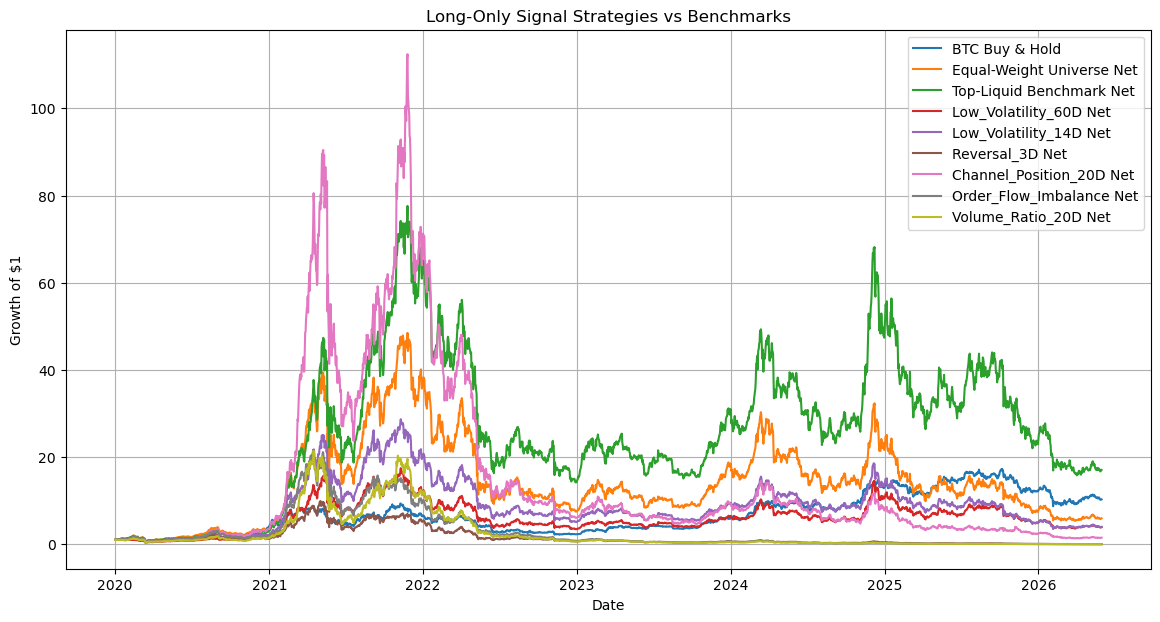

In [58]:
# ============================================================
# Plot Long-Only Strategy Cumulative Returns
# ============================================================

long_only_cumulative = pd.DataFrame({
    "BTC Buy & Hold": (1 + btc_benchmark_1d.fillna(0)).cumprod(),
    "Equal-Weight Universe Net": (1 + equal_weight_benchmark_1d_net.fillna(0)).cumprod(),
    "Top-Liquid Benchmark Net": (1 + top_liquid_benchmark_1d_net.fillna(0)).cumprod()
})

for strategy_name, result in long_only_strategy_results.items():
    long_only_cumulative[f"{strategy_name} Net"] = (1 + result["net_returns"].fillna(0)).cumprod()

plt.figure(figsize=(14, 7))

for col in long_only_cumulative.columns:
    plt.plot(long_only_cumulative.index, long_only_cumulative[col], label=col)

plt.title("Long-Only Signal Strategies vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

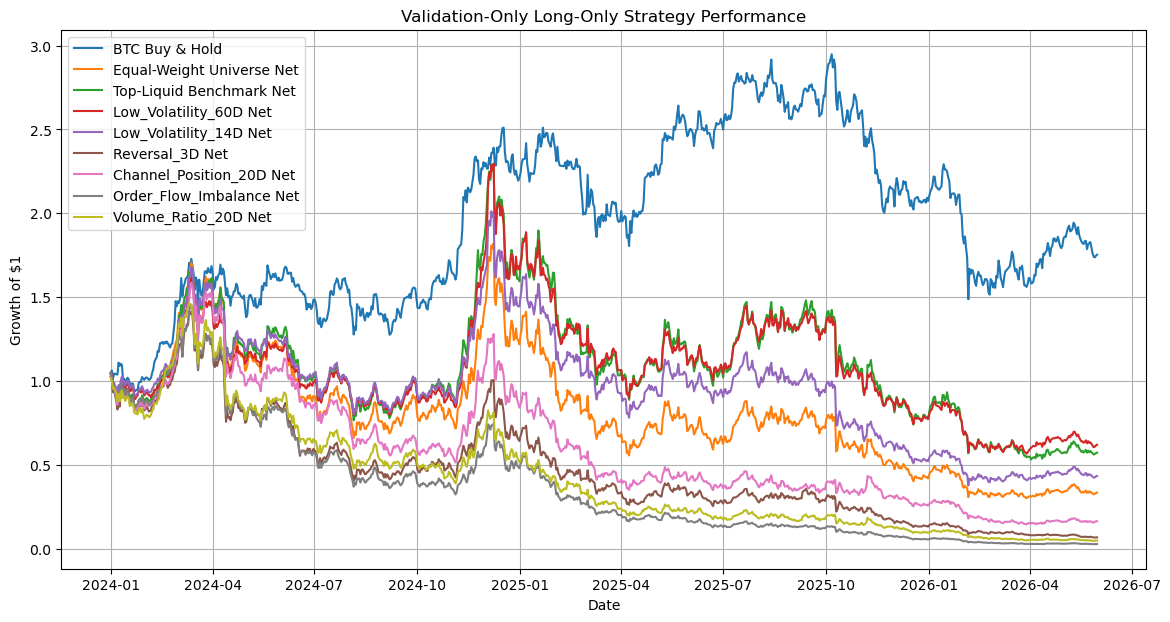

In [59]:
# ============================================================
# Plot Validation-Only Long-Only Cumulative Returns
# ============================================================

validation_start = pd.to_datetime(VALIDATION_START_DATE, utc=True)

long_only_validation_cumulative = pd.DataFrame({
    "BTC Buy & Hold": (1 + btc_benchmark_1d.loc[validation_start:].fillna(0)).cumprod(),
    "Equal-Weight Universe Net": (1 + equal_weight_benchmark_1d_net.loc[validation_start:].fillna(0)).cumprod(),
    "Top-Liquid Benchmark Net": (1 + top_liquid_benchmark_1d_net.loc[validation_start:].fillna(0)).cumprod()
})

for strategy_name, result in long_only_strategy_results.items():
    validation_returns = result["net_returns"].loc[validation_start:]
    long_only_validation_cumulative[f"{strategy_name} Net"] = (1 + validation_returns.fillna(0)).cumprod()

plt.figure(figsize=(14, 7))

for col in long_only_validation_cumulative.columns:
    plt.plot(long_only_validation_cumulative.index, long_only_validation_cumulative[col], label=col)

plt.title("Validation-Only Long-Only Strategy Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

## 13. Rebalance Frequency and Top-N Optimization

The first long-only backtests showed that some signals have useful gross performance, but high turnover can destroy net performance after transaction costs. We now test different portfolio construction choices to see whether slower rebalancing and different portfolio breadth can preserve signal edge while reducing trading costs.

We optimize only over implementation choices:
- number of assets held,
- rebalance frequency,
- signal choice.

The goal is to rank strategies by validation-period net performance, not full-sample performance.

In [60]:
# ============================================================
# Long-Only Parameter Grid Setup
# ============================================================

# We focus on the signals that were most interesting from the first long-only backtest.
# Some had good gross performance but too much turnover, so we test slower rebalancing.

OPTIMIZATION_SIGNALS = {
    "Low_Volatility_60D": daily_signals["Low_Volatility_60D"],
    "Low_Volatility_14D": daily_signals["Low_Volatility_14D"],
    "Channel_Position_20D": daily_signals["Channel_Position_20D"],
    "Reversal_3D": daily_signals["Reversal_3D"],
    "Order_Flow_Imbalance": daily_signals["Order_Flow_Imbalance"],
    "Volume_Ratio_20D": daily_signals["Volume_Ratio_20D"]
}

# Number of assets to hold.
# Smaller top_n creates more concentrated portfolios.
# Larger top_n creates broader, lower-turnover portfolios.
TOP_N_GRID = [10, 20, 30, 50]

# Rebalance frequency.
# Slower rebalancing should reduce turnover and transaction costs.
REBALANCE_GRID = ["1D", "7D", "30D"]

print("Optimization signals:")
for signal_name in OPTIMIZATION_SIGNALS:
    print("-", signal_name)

print()
print(f"Top-N grid: {TOP_N_GRID}")
print(f"Rebalance grid: {REBALANCE_GRID}")

Optimization signals:
- Low_Volatility_60D
- Low_Volatility_14D
- Channel_Position_20D
- Reversal_3D
- Order_Flow_Imbalance
- Volume_Ratio_20D

Top-N grid: [10, 20, 30, 50]
Rebalance grid: ['1D', '7D', '30D']


In [61]:
# ============================================================
# Run Long-Only Strategy Optimization Grid
# ============================================================

long_only_grid_results = []
long_only_grid_backtests = {}

for signal_name, signal_df in OPTIMIZATION_SIGNALS.items():
    for top_n in TOP_N_GRID:
        for rebalance_frequency in REBALANCE_GRID:

            strategy_id = f"{signal_name}_Top{top_n}_{rebalance_frequency}"

            print(f"Backtesting {strategy_id}...")

            result = backtest_long_only_signal_strategy(
                signal=signal_df,
                returns=returns_1d,
                strategy_name=strategy_id,
                top_n=top_n,
                rebalance_frequency=rebalance_frequency,
                transaction_cost=BASE_TCOST,
                max_weight=MAX_WEIGHT_PER_ASSET
            )

            long_only_grid_backtests[strategy_id] = result

            # Split gross and net returns into train / validation.
            gross_train, gross_validation = split_returns_train_validation(result["gross_returns"])
            net_train, net_validation = split_returns_train_validation(result["net_returns"])

            # Use top-liquid benchmark for alpha/beta comparison.
            top_liquid_train = top_liquid_benchmark_1d.loc[gross_train.index]
            top_liquid_validation = top_liquid_benchmark_1d.loc[gross_validation.index]

            gross_train_metrics = calculate_performance_metrics(
                returns=gross_train,
                periods_per_year=BARS_PER_YEAR_1D,
                benchmark_returns=top_liquid_train
            )

            gross_validation_metrics = calculate_performance_metrics(
                returns=gross_validation,
                periods_per_year=BARS_PER_YEAR_1D,
                benchmark_returns=top_liquid_validation
            )

            net_train_metrics = calculate_performance_metrics(
                returns=net_train,
                periods_per_year=BARS_PER_YEAR_1D,
                benchmark_returns=top_liquid_train
            )

            net_validation_metrics = calculate_performance_metrics(
                returns=net_validation,
                periods_per_year=BARS_PER_YEAR_1D,
                benchmark_returns=top_liquid_validation
            )

            turnover = result["turnover"].dropna()
            tcost_paid = result["transaction_cost_paid"].dropna()

            row = {
                "Strategy ID": strategy_id,
                "Signal": signal_name,
                "Top N": top_n,
                "Rebalance Frequency": rebalance_frequency,

                "Train Gross Sharpe": gross_train_metrics.get("Sharpe", np.nan),
                "Validation Gross Sharpe": gross_validation_metrics.get("Sharpe", np.nan),

                "Train Net Sharpe": net_train_metrics.get("Sharpe", np.nan),
                "Validation Net Sharpe": net_validation_metrics.get("Sharpe", np.nan),

                "Train Net Annualized Return": net_train_metrics.get("Annualized Return", np.nan),
                "Validation Net Annualized Return": net_validation_metrics.get("Annualized Return", np.nan),

                "Train Net Max Drawdown": net_train_metrics.get("Max Drawdown", np.nan),
                "Validation Net Max Drawdown": net_validation_metrics.get("Max Drawdown", np.nan),

                "Validation Net Alpha": net_validation_metrics.get("Alpha Annualized", np.nan),
                "Validation Net Beta": net_validation_metrics.get("Beta", np.nan),
                "Validation Net Alpha t-stat": net_validation_metrics.get("Alpha t-stat", np.nan),

                "Average Daily Turnover": turnover.mean(),
                "Median Daily Turnover": turnover.median(),
                "Annualized Turnover": turnover.mean() * BARS_PER_YEAR_1D,
                "Annualized Transaction Cost Drag": tcost_paid.mean() * BARS_PER_YEAR_1D
            }

            long_only_grid_results.append(row)

long_only_grid_table = pd.DataFrame(long_only_grid_results)

print("Long-only optimization grid complete.")
print(f"Total strategies tested: {len(long_only_grid_table)}")

display(long_only_grid_table.head())

Backtesting Low_Volatility_60D_Top10_1D...
Backtesting Low_Volatility_60D_Top10_7D...
Backtesting Low_Volatility_60D_Top10_30D...
Backtesting Low_Volatility_60D_Top20_1D...
Backtesting Low_Volatility_60D_Top20_7D...
Backtesting Low_Volatility_60D_Top20_30D...
Backtesting Low_Volatility_60D_Top30_1D...
Backtesting Low_Volatility_60D_Top30_7D...
Backtesting Low_Volatility_60D_Top30_30D...
Backtesting Low_Volatility_60D_Top50_1D...
Backtesting Low_Volatility_60D_Top50_7D...
Backtesting Low_Volatility_60D_Top50_30D...
Backtesting Low_Volatility_14D_Top10_1D...
Backtesting Low_Volatility_14D_Top10_7D...
Backtesting Low_Volatility_14D_Top10_30D...
Backtesting Low_Volatility_14D_Top20_1D...
Backtesting Low_Volatility_14D_Top20_7D...
Backtesting Low_Volatility_14D_Top20_30D...
Backtesting Low_Volatility_14D_Top30_1D...
Backtesting Low_Volatility_14D_Top30_7D...
Backtesting Low_Volatility_14D_Top30_30D...
Backtesting Low_Volatility_14D_Top50_1D...
Backtesting Low_Volatility_14D_Top50_7D...
Back

,Strategy ID,Signal,Top N,Rebalance Frequency,Train Gross Sharpe,Validation Gross Sharpe,Train Net Sharpe,Validation Net Sharpe,Train Net Annualized Return,Validation Net Annualized Return,Train Net Max Drawdown,Validation Net Max Drawdown,Validation Net Alpha,Validation Net Beta,Validation Net Alpha t-stat,Average Daily Turnover,Median Daily Turnover,Annualized Turnover,Annualized Transaction Cost Drag
0,Low_Volatility_60D_Top10_1D,Low_Volatility_60D,10,1D,0.889810,-0.133396,0.759025,-0.226848,0.592272,-0.123008,-0.777407,-0.669639,0.003130,0.727055,0.027124,0.082288,0.000000,30.034998,0.060070
1,Low_Volatility_60D_Top10_7D,Low_Volatility_60D,10,7D,0.971295,-0.160740,0.904545,-0.206508,0.702674,-0.113423,-0.779305,-0.660807,0.017655,0.735387,0.149345,0.039863,0.000000,14.550149,0.029100
2,Low_Volatility_60D_Top10_30D,Low_Volatility_60D,10,30D,1.133148,-0.113714,1.094079,-0.139307,0.862288,-0.077819,-0.731465,-0.689056,0.062324,0.743744,0.496771,0.022023,0.000000,8.038412,0.016077
3,Low_Volatility_60D_Top20_1D,Low_Volatility_60D,20,1D,0.822748,-0.213777,0.717939,-0.289090,0.585427,-0.179167,-0.801949,-0.753148,-0.019593,0.851243,-0.192144,0.073239,0.100000,26.732394,0.053465
4,Low_Volatility_60D_Top20_7D,Low_Volatility_60D,20,7D,0.925182,-0.317107,0.868957,-0.349873,0.704748,-0.218247,-0.796012,-0.763128,-0.065873,0.856538,-0.639353,0.035851,0.000000,13.085787,0.026172


In [ ]:
# ============================================================
# Rank Long-Only Strategies by Validation Net Sharpe
# ============================================================

long_only_grid_ranked = long_only_grid_table.sort_values(
    "Validation Net Sharpe",
    ascending=False
)

print("Top 20 strategies by validation net Sharpe:")
display(long_only_grid_ranked.head(20))

print("Worst 20 strategies by validation net Sharpe:")
display(long_only_grid_ranked.tail(20))

In [ ]:
# ============================================================
# Filter for More Realistic Long-Only Strategies
# ============================================================

# These filters are not meant to find a perfect strategy.
# They help identify candidates that are more realistic after costs.

realistic_long_only_candidates = long_only_grid_table[
    (long_only_grid_table["Validation Net Sharpe"] > 0) &
    (long_only_grid_table["Validation Net Max Drawdown"] > -0.60) &
    (long_only_grid_table["Annualized Turnover"] < 100)
].copy()

realistic_long_only_candidates = realistic_long_only_candidates.sort_values(
    "Validation Net Sharpe",
    ascending=False
)

print(f"Number of realistic candidates: {len(realistic_long_only_candidates)}")
display(realistic_long_only_candidates)

In [ ]:
# ============================================================
# Train vs Validation Stability
# ============================================================

long_only_grid_table["Sharpe Decay"] = (
    long_only_grid_table["Validation Net Sharpe"] -
    long_only_grid_table["Train Net Sharpe"]
)

long_only_grid_table["Return Decay"] = (
    long_only_grid_table["Validation Net Annualized Return"] -
    long_only_grid_table["Train Net Annualized Return"]
)

stability_ranked = long_only_grid_table.sort_values(
    ["Validation Net Sharpe", "Sharpe Decay"],
    ascending=[False, False]
)

display(
    stability_ranked[
        [
            "Strategy ID",
            "Signal",
            "Top N",
            "Rebalance Frequency",
            "Train Net Sharpe",
            "Validation Net Sharpe",
            "Sharpe Decay",
            "Train Net Annualized Return",
            "Validation Net Annualized Return",
            "Return Decay",
            "Annualized Turnover",
            "Annualized Transaction Cost Drag"
        ]
    ].head(25)
)

In [ ]:
# ============================================================
# Pivot: Validation Net Sharpe by Signal and Rebalance Frequency
# ============================================================

pivot_validation_sharpe = long_only_grid_table.pivot_table(
    index="Signal",
    columns=["Rebalance Frequency", "Top N"],
    values="Validation Net Sharpe",
    aggfunc="mean"
)

display(pivot_validation_sharpe)

In [ ]:
# ============================================================
# Plot Top Long-Only Strategies in Validation Period
# ============================================================

validation_start = pd.to_datetime(VALIDATION_START_DATE, utc=True)

top_strategy_ids = long_only_grid_ranked.head(5)["Strategy ID"].tolist()

top_validation_cumulative = pd.DataFrame({
    "BTC Buy & Hold": (1 + btc_benchmark_1d.loc[validation_start:].fillna(0)).cumprod(),
    "Equal-Weight Universe Net": (1 + equal_weight_benchmark_1d_net.loc[validation_start:].fillna(0)).cumprod(),
    "Top-Liquid Benchmark Net": (1 + top_liquid_benchmark_1d_net.loc[validation_start:].fillna(0)).cumprod()
})

for strategy_id in top_strategy_ids:
    strategy_returns = long_only_grid_backtests[strategy_id]["net_returns"].loc[validation_start:]
    top_validation_cumulative[strategy_id] = (1 + strategy_returns.fillna(0)).cumprod()

plt.figure(figsize=(14, 7))

for col in top_validation_cumulative.columns:
    plt.plot(top_validation_cumulative.index, top_validation_cumulative[col], label=col)

plt.title("Top Long-Only Strategies: Validation Period")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Select Best Long-Only Strategy Candidate
# ============================================================

best_long_only_strategy_id = long_only_grid_ranked.iloc[0]["Strategy ID"]
best_long_only_strategy = long_only_grid_backtests[best_long_only_strategy_id]

print(f"Best long-only strategy by validation net Sharpe: {best_long_only_strategy_id}")

best_long_only_summary = long_only_grid_ranked.iloc[0]
display(best_long_only_summary.to_frame().T)

## 14. Combined Long-Only Signal Strategy

The individual long-only backtests showed that low-volatility allocation was the strongest standalone long-only signal. We now test whether adding secondary signals like reversal, channel position, order-flow imbalance, and volume confirmation can improve validation-period performance without creating excessive turnover.

The combined strategy is built carefully: low volatility remains the core signal, while other signals receive smaller weights.

In [ ]:
# ============================================================
# Combined Signal Construction
# ============================================================

def normalize_signal_for_combination(signal):
    """
    Normalizes a signal for combination with other signals.

    Steps:
    1. Winsorize cross-sectionally to reduce outlier impact.
    2. Convert each date's signal values into cross-sectional z-scores.

    This makes different signals comparable before combining them.
    """

    signal_clean = winsorize_dataframe(signal)
    signal_z = cross_sectional_zscore(signal_clean)

    return signal_z


def create_combined_signal(signal_dict, weights_dict):
    """
    Creates a weighted combined signal.

    Parameters
    ----------
    signal_dict : dict
        Dictionary of signal DataFrames.
    weights_dict : dict
        Dictionary of signal weights.

    Returns
    -------
    pd.DataFrame
        Combined signal DataFrame.
    """

    combined_signal = None

    for signal_name, weight in weights_dict.items():
        signal_z = normalize_signal_for_combination(signal_dict[signal_name])

        if combined_signal is None:
            combined_signal = weight * signal_z
        else:
            combined_signal = combined_signal.add(weight * signal_z, fill_value=0)

    return combined_signal

In [ ]:
# ============================================================
# Candidate Combined Long-Only Signals
# ============================================================

# These combinations keep low volatility as the anchor signal.
# Secondary signals are added with smaller weights to test whether they improve selection.

COMBINED_SIGNAL_SPECS = {
    "Combo_LowVol14_Only": {
        "Low_Volatility_14D": 1.00
    },

    "Combo_LowVol60_Only": {
        "Low_Volatility_60D": 1.00
    },

    "Combo_LowVol14_Reversal3": {
        "Low_Volatility_14D": 0.70,
        "Reversal_3D": 0.30
    },

    "Combo_LowVol14_Channel20": {
        "Low_Volatility_14D": 0.70,
        "Channel_Position_20D": 0.30
    },

    "Combo_LowVol14_OrderFlow": {
        "Low_Volatility_14D": 0.80,
        "Order_Flow_Imbalance": 0.20
    },

    "Combo_LowVol14_Volume20": {
        "Low_Volatility_14D": 0.80,
        "Volume_Ratio_20D": 0.20
    },

    "Combo_LowVol14_Rev_Channel": {
        "Low_Volatility_14D": 0.60,
        "Reversal_3D": 0.20,
        "Channel_Position_20D": 0.20
    },

    "Combo_LowVol14_Rev_OrderFlow": {
        "Low_Volatility_14D": 0.60,
        "Reversal_3D": 0.20,
        "Order_Flow_Imbalance": 0.20
    },

    "Combo_LowVol60_Rev_Channel": {
        "Low_Volatility_60D": 0.60,
        "Reversal_3D": 0.20,
        "Channel_Position_20D": 0.20
    }
}


combined_signals = {}

for combo_name, weights in COMBINED_SIGNAL_SPECS.items():
    combined_signals[combo_name] = create_combined_signal(
        signal_dict=daily_signals,
        weights_dict=weights
    )

print(f"Created {len(combined_signals)} combined signals:")
for combo_name, weights in COMBINED_SIGNAL_SPECS.items():
    print(combo_name, ":", weights)

In [ ]:
# ============================================================
# Backtest Combined Signals Using Best Initial Settings
# ============================================================

combined_strategy_results = {}

COMBO_TOP_N = 10
COMBO_REBALANCE_FREQUENCY = "30D"

for combo_name, combo_signal in combined_signals.items():
    print(f"Backtesting {combo_name}...")

    result = backtest_long_only_signal_strategy(
        signal=combo_signal,
        returns=returns_1d,
        strategy_name=combo_name,
        top_n=COMBO_TOP_N,
        rebalance_frequency=COMBO_REBALANCE_FREQUENCY,
        transaction_cost=BASE_TCOST,
        max_weight=MAX_WEIGHT_PER_ASSET
    )

    combined_strategy_results[combo_name] = result

print("Combined signal backtests complete.")

In [ ]:
# ============================================================
# Combined Strategy Performance Table
# ============================================================

combined_performance_rows = {}

for strategy_name, result in combined_strategy_results.items():

    combined_performance_rows[f"{strategy_name} Gross"] = calculate_performance_metrics(
        returns=result["gross_returns"],
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=top_liquid_benchmark_1d
    )

    combined_performance_rows[f"{strategy_name} Net"] = calculate_performance_metrics(
        returns=result["net_returns"],
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=top_liquid_benchmark_1d
    )

combined_performance_table = pd.DataFrame(combined_performance_rows).T

display(combined_performance_table)

In [ ]:
# ============================================================
# Combined Strategy Train / Validation Performance
# ============================================================

combined_train_validation_results = {}

for strategy_name, result in combined_strategy_results.items():

    for return_type, return_series in {
        "Gross": result["gross_returns"],
        "Net": result["net_returns"]
    }.items():

        train_ret, validation_ret = split_returns_train_validation(return_series)

        top_liquid_train = top_liquid_benchmark_1d.loc[train_ret.index]
        top_liquid_validation = top_liquid_benchmark_1d.loc[validation_ret.index]

        combined_train_validation_results[(strategy_name, return_type, "Train")] = calculate_performance_metrics(
            returns=train_ret,
            periods_per_year=BARS_PER_YEAR_1D,
            benchmark_returns=top_liquid_train
        )

        combined_train_validation_results[(strategy_name, return_type, "Validation")] = calculate_performance_metrics(
            returns=validation_ret,
            periods_per_year=BARS_PER_YEAR_1D,
            benchmark_returns=top_liquid_validation
        )

combined_train_validation_table = pd.DataFrame(combined_train_validation_results).T

display(combined_train_validation_table)

In [ ]:
# ============================================================
# Combined Strategy Turnover and Transaction Cost Summary
# ============================================================

combined_turnover_summary_rows = {}

for strategy_name, result in combined_strategy_results.items():
    turnover = result["turnover"].dropna()
    tcost_paid = result["transaction_cost_paid"].dropna()

    combined_turnover_summary_rows[strategy_name] = pd.Series({
        "Average Daily Turnover": turnover.mean(),
        "Median Daily Turnover": turnover.median(),
        "Annualized Turnover": turnover.mean() * BARS_PER_YEAR_1D,
        "Annualized Transaction Cost Drag": tcost_paid.mean() * BARS_PER_YEAR_1D
    })

combined_turnover_summary_table = pd.DataFrame(combined_turnover_summary_rows).T

display(combined_turnover_summary_table)

In [ ]:
# ============================================================
# Rank Combined Strategies by Validation Net Sharpe
# ============================================================

combined_ranking_rows = []

for strategy_name, result in combined_strategy_results.items():
    train_ret, validation_ret = split_returns_train_validation(result["net_returns"])

    top_liquid_train = top_liquid_benchmark_1d.loc[train_ret.index]
    top_liquid_validation = top_liquid_benchmark_1d.loc[validation_ret.index]

    train_metrics = calculate_performance_metrics(
        returns=train_ret,
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=top_liquid_train
    )

    validation_metrics = calculate_performance_metrics(
        returns=validation_ret,
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=top_liquid_validation
    )

    turnover = result["turnover"].dropna()
    tcost_paid = result["transaction_cost_paid"].dropna()

    combined_ranking_rows.append({
        "Strategy": strategy_name,
        "Train Net Sharpe": train_metrics.get("Sharpe", np.nan),
        "Validation Net Sharpe": validation_metrics.get("Sharpe", np.nan),
        "Train Net Annualized Return": train_metrics.get("Annualized Return", np.nan),
        "Validation Net Annualized Return": validation_metrics.get("Annualized Return", np.nan),
        "Train Net Max Drawdown": train_metrics.get("Max Drawdown", np.nan),
        "Validation Net Max Drawdown": validation_metrics.get("Max Drawdown", np.nan),
        "Validation Net Alpha": validation_metrics.get("Alpha Annualized", np.nan),
        "Validation Net Beta": validation_metrics.get("Beta", np.nan),
        "Validation Net Alpha t-stat": validation_metrics.get("Alpha t-stat", np.nan),
        "Annualized Turnover": turnover.mean() * BARS_PER_YEAR_1D,
        "Annualized Transaction Cost Drag": tcost_paid.mean() * BARS_PER_YEAR_1D
    })

combined_ranking_table = pd.DataFrame(combined_ranking_rows)

combined_ranking_table = combined_ranking_table.sort_values(
    "Validation Net Sharpe",
    ascending=False
)

display(combined_ranking_table)

In [ ]:
# ============================================================
# Plot Combined Strategy Validation Performance
# ============================================================

validation_start = pd.to_datetime(VALIDATION_START_DATE, utc=True)

top_combined_strategy_names = combined_ranking_table.head(5)["Strategy"].tolist()

combined_validation_cumulative = pd.DataFrame({
    "BTC Buy & Hold": (1 + btc_benchmark_1d.loc[validation_start:].fillna(0)).cumprod(),
    "Equal-Weight Universe Net": (1 + equal_weight_benchmark_1d_net.loc[validation_start:].fillna(0)).cumprod(),
    "Top-Liquid Benchmark Net": (1 + top_liquid_benchmark_1d_net.loc[validation_start:].fillna(0)).cumprod(),
    "Best Individual: LowVol14 Top10 30D": (
        1 + long_only_grid_backtests["Low_Volatility_14D_Top10_30D"]["net_returns"]
        .loc[validation_start:]
        .fillna(0)
    ).cumprod()
})

for strategy_name in top_combined_strategy_names:
    strategy_returns = combined_strategy_results[strategy_name]["net_returns"].loc[validation_start:]
    combined_validation_cumulative[strategy_name] = (1 + strategy_returns.fillna(0)).cumprod()

plt.figure(figsize=(14, 7))

for col in combined_validation_cumulative.columns:
    plt.plot(combined_validation_cumulative.index, combined_validation_cumulative[col], label=col)

plt.title("Combined Long-Only Strategies: Validation Period")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Select Best Combined Long-Only Strategy
# ============================================================

best_combined_strategy_name = combined_ranking_table.iloc[0]["Strategy"]
best_combined_strategy = combined_strategy_results[best_combined_strategy_name]

print(f"Best combined strategy by validation net Sharpe: {best_combined_strategy_name}")

best_combined_summary = combined_ranking_table.iloc[0]
display(best_combined_summary.to_frame().T)

### Combined Signal Strategy Findings

The combined signal tests showed that adding reversal, channel position, volume, or order-flow features did not improve validation-period performance relative to the standalone low-volatility strategy. The best combined model was `Combo_LowVol14_Only`, which is equivalent to the original low-volatility allocation.

This suggests that, for the long-only spot strategy, the low-volatility effect is the most robust component, while the secondary signals add noise or increase instability. This is an important research result: model complexity did not improve out-of-sample performance, so the final long-only strategy remains a simple, interpretable low-volatility portfolio with monthly rebalancing.

## 15. Volatility Targeting and Risk Management

The best long-only strategy so far is the standalone low-volatility allocation strategy:

`Low_Volatility_14D_Top10_30D`

Although this strategy performed best out-of-sample, it still experienced meaningful drawdowns. We now add a volatility-targeting overlay to dynamically scale portfolio exposure based on recent realized portfolio volatility.

The goal is not necessarily to maximize raw return. The goal is to improve risk-adjusted performance, reduce drawdowns, and make the strategy more realistic from a portfolio management perspective.

In [ ]:
# ============================================================
# Volatility Targeting Helper Functions
# ============================================================

def calculate_rolling_annualized_volatility(
    returns,
    lookback_window=30,
    periods_per_year=BARS_PER_YEAR_1D
):
    """
    Calculates rolling annualized volatility for a return series.

    Parameters
    ----------
    returns : pd.Series
        Strategy returns.
    lookback_window : int
        Number of periods used to estimate recent volatility.
    periods_per_year : int
        Annualization factor.

    Returns
    -------
    pd.Series
        Rolling annualized volatility.
    """

    rolling_vol = returns.rolling(lookback_window).std() * np.sqrt(periods_per_year)

    return rolling_vol


def apply_volatility_targeting(
    returns,
    target_vol=0.35,
    lookback_window=30,
    periods_per_year=BARS_PER_YEAR_1D,
    max_exposure=1.00,
    min_exposure=0.00
):
    """
    Applies volatility targeting to a strategy return series.

    Exposure rule:
        exposure_t = target_vol / realized_vol_t

    Then exposure is clipped between min_exposure and max_exposure.

    Important:
    We shift exposure by 1 period to avoid lookahead bias.
    Today's return uses yesterday's estimated exposure.
    """

    realized_vol = calculate_rolling_annualized_volatility(
        returns=returns,
        lookback_window=lookback_window,
        periods_per_year=periods_per_year
    )

    raw_exposure = target_vol / realized_vol

    exposure = raw_exposure.clip(lower=min_exposure, upper=max_exposure)

    # Shift exposure so today's return uses information available yesterday.
    shifted_exposure = exposure.shift(1)

    vol_targeted_returns = shifted_exposure * returns

    result = {
        "vol_targeted_returns": vol_targeted_returns,
        "realized_vol": realized_vol,
        "raw_exposure": raw_exposure,
        "exposure": exposure,
        "shifted_exposure": shifted_exposure
    }

    return result

In [ ]:
# ============================================================
# Select Base Strategy for Risk Management
# ============================================================

# The best individual/combined long-only strategy was:
# Low_Volatility_14D, Top 10 assets, monthly rebalance.

BASE_LONG_ONLY_STRATEGY_ID = "Low_Volatility_14D_Top10_30D"

base_long_only_result = long_only_grid_backtests[BASE_LONG_ONLY_STRATEGY_ID]

base_long_only_net_returns = base_long_only_result["net_returns"]
base_long_only_gross_returns = base_long_only_result["gross_returns"]

print(f"Base strategy selected: {BASE_LONG_ONLY_STRATEGY_ID}")
print(f"Return series length: {len(base_long_only_net_returns.dropna())}")

In [ ]:
# ============================================================
# Volatility Targeting Grid
# ============================================================

# We test multiple volatility targets and lookback windows.
# Lower target volatility should reduce drawdowns but may reduce returns.
# Higher target volatility allows more risk but may preserve more upside.

VOL_TARGET_GRID = [0.25, 0.35, 0.50]
VOL_LOOKBACK_GRID = [14, 30, 60]

vol_target_results = {}
vol_target_summary_rows = []

for target_vol in VOL_TARGET_GRID:
    for lookback_window in VOL_LOOKBACK_GRID:

        strategy_name = f"{BASE_LONG_ONLY_STRATEGY_ID}_VolTarget{int(target_vol*100)}_Lookback{lookback_window}"

        print(f"Testing {strategy_name}...")

        vt_result = apply_volatility_targeting(
            returns=base_long_only_net_returns,
            target_vol=target_vol,
            lookback_window=lookback_window,
            periods_per_year=BARS_PER_YEAR_1D,
            max_exposure=1.00,
            min_exposure=0.00
        )

        vt_returns = vt_result["vol_targeted_returns"]

        train_ret, validation_ret = split_returns_train_validation(vt_returns)

        top_liquid_train = top_liquid_benchmark_1d.loc[train_ret.index]
        top_liquid_validation = top_liquid_benchmark_1d.loc[validation_ret.index]

        train_metrics = calculate_performance_metrics(
            returns=train_ret,
            periods_per_year=BARS_PER_YEAR_1D,
            benchmark_returns=top_liquid_train
        )

        validation_metrics = calculate_performance_metrics(
            returns=validation_ret,
            periods_per_year=BARS_PER_YEAR_1D,
            benchmark_returns=top_liquid_validation
        )

        exposure = vt_result["shifted_exposure"]

        vol_target_results[strategy_name] = vt_result

        vol_target_summary_rows.append({
            "Strategy": strategy_name,
            "Target Vol": target_vol,
            "Lookback Window": lookback_window,

            "Train Sharpe": train_metrics.get("Sharpe", np.nan),
            "Validation Sharpe": validation_metrics.get("Sharpe", np.nan),

            "Train Annualized Return": train_metrics.get("Annualized Return", np.nan),
            "Validation Annualized Return": validation_metrics.get("Annualized Return", np.nan),

            "Train Max Drawdown": train_metrics.get("Max Drawdown", np.nan),
            "Validation Max Drawdown": validation_metrics.get("Max Drawdown", np.nan),

            "Validation Alpha": validation_metrics.get("Alpha Annualized", np.nan),
            "Validation Beta": validation_metrics.get("Beta", np.nan),
            "Validation Alpha t-stat": validation_metrics.get("Alpha t-stat", np.nan),

            "Average Exposure": exposure.mean(),
            "Median Exposure": exposure.median(),
            "Minimum Exposure": exposure.min(),
            "Maximum Exposure": exposure.max()
        })

vol_target_summary_table = pd.DataFrame(vol_target_summary_rows)

vol_target_summary_table = vol_target_summary_table.sort_values(
    "Validation Sharpe",
    ascending=False
)

display(vol_target_summary_table)

In [ ]:
# ============================================================
# Compare Base Strategy and Volatility-Targeted Versions
# ============================================================

base_train_ret, base_validation_ret = split_returns_train_validation(base_long_only_net_returns)

top_liquid_train = top_liquid_benchmark_1d.loc[base_train_ret.index]
top_liquid_validation = top_liquid_benchmark_1d.loc[base_validation_ret.index]

base_train_metrics = calculate_performance_metrics(
    returns=base_train_ret,
    periods_per_year=BARS_PER_YEAR_1D,
    benchmark_returns=top_liquid_train
)

base_validation_metrics = calculate_performance_metrics(
    returns=base_validation_ret,
    periods_per_year=BARS_PER_YEAR_1D,
    benchmark_returns=top_liquid_validation
)

comparison_rows = {
    "Base Strategy Train": base_train_metrics,
    "Base Strategy Validation": base_validation_metrics
}

for strategy_name in vol_target_summary_table.head(5)["Strategy"]:
    vt_returns = vol_target_results[strategy_name]["vol_targeted_returns"]

    train_ret, validation_ret = split_returns_train_validation(vt_returns)

    comparison_rows[f"{strategy_name} Train"] = calculate_performance_metrics(
        returns=train_ret,
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=top_liquid_benchmark_1d.loc[train_ret.index]
    )

    comparison_rows[f"{strategy_name} Validation"] = calculate_performance_metrics(
        returns=validation_ret,
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=top_liquid_benchmark_1d.loc[validation_ret.index]
    )

vol_target_comparison_table = pd.DataFrame(comparison_rows).T

display(vol_target_comparison_table)

In [ ]:
# ============================================================
# Plot Volatility-Targeted Strategy Validation Performance
# ============================================================

validation_start = pd.to_datetime(VALIDATION_START_DATE, utc=True)

top_vt_strategy_names = vol_target_summary_table.head(5)["Strategy"].tolist()

vt_validation_cumulative = pd.DataFrame({
    "BTC Buy & Hold": (1 + btc_benchmark_1d.loc[validation_start:].fillna(0)).cumprod(),
    "Equal-Weight Universe Net": (1 + equal_weight_benchmark_1d_net.loc[validation_start:].fillna(0)).cumprod(),
    "Top-Liquid Benchmark Net": (1 + top_liquid_benchmark_1d_net.loc[validation_start:].fillna(0)).cumprod(),
    "Base LowVol14 Top10 30D": (
        1 + base_long_only_net_returns.loc[validation_start:].fillna(0)
    ).cumprod()
})

for strategy_name in top_vt_strategy_names:
    vt_returns = vol_target_results[strategy_name]["vol_targeted_returns"].loc[validation_start:]
    vt_validation_cumulative[strategy_name] = (1 + vt_returns.fillna(0)).cumprod()

plt.figure(figsize=(14, 7))

for col in vt_validation_cumulative.columns:
    plt.plot(vt_validation_cumulative.index, vt_validation_cumulative[col], label=col)

plt.title("Volatility-Targeted Long-Only Strategy: Validation Period")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Plot Exposure for Best Volatility-Targeted Strategy
# ============================================================

best_vt_strategy_name = vol_target_summary_table.iloc[0]["Strategy"]
best_vt_result = vol_target_results[best_vt_strategy_name]

print(f"Best volatility-targeted strategy by validation Sharpe: {best_vt_strategy_name}")

plt.figure(figsize=(14, 5))
plt.plot(best_vt_result["shifted_exposure"].index, best_vt_result["shifted_exposure"])
plt.title(f"Dynamic Exposure Over Time: {best_vt_strategy_name}")
plt.xlabel("Date")
plt.ylabel("Portfolio Exposure")
plt.grid(True)
plt.show()

display(vol_target_summary_table.iloc[0].to_frame().T)

In [ ]:
# ============================================================
# Save Final Long-Only Strategy Candidate
# ============================================================

best_vt_strategy_name = vol_target_summary_table.iloc[0]["Strategy"]
best_vt_result = vol_target_results[best_vt_strategy_name]

final_long_only_strategy_name = best_vt_strategy_name
final_long_only_returns = best_vt_result["vol_targeted_returns"]
final_long_only_exposure = best_vt_result["shifted_exposure"]

print(f"Final long-only strategy candidate: {final_long_only_strategy_name}")

final_long_only_train, final_long_only_validation = split_returns_train_validation(final_long_only_returns)

final_long_only_train_metrics = calculate_performance_metrics(
    returns=final_long_only_train,
    periods_per_year=BARS_PER_YEAR_1D,
    benchmark_returns=top_liquid_benchmark_1d.loc[final_long_only_train.index]
)

final_long_only_validation_metrics = calculate_performance_metrics(
    returns=final_long_only_validation,
    periods_per_year=BARS_PER_YEAR_1D,
    benchmark_returns=top_liquid_benchmark_1d.loc[final_long_only_validation.index]
)

final_long_only_metrics_table = pd.DataFrame({
    "Train": final_long_only_train_metrics,
    "Validation": final_long_only_validation_metrics
}).T

display(final_long_only_metrics_table)

### Volatility Targeting Findings

Volatility targeting materially improved the long-only strategy. The best version used a 25% annualized volatility target with a 30-day realized volatility estimate. Compared with the base low-volatility strategy, the risk-managed version increased validation Sharpe from 0.67 to 1.24, reduced validation annualized volatility from 29.5% to 17.4%, and reduced maximum drawdown from approximately -37.8% to -21.0%.

The strategy achieved this by dynamically scaling exposure based on recent realized volatility. During high-volatility regimes, the model reduced exposure and held more cash; during calmer regimes, exposure increased toward the 100% cap. This demonstrates that risk management was not just an overlay, but a meaningful driver of improved out-of-sample performance.

## Current final long-only model

Volatility-Targeted Low-Volatility Crypto Allocation:

Each month, rank the crypto universe by 14-day realized volatility and hold the 10 lowest-volatility assets. Then estimate the portfolio’s trailing 30-day realized volatility and scale exposure to target 25% annualized volatility, capped at 100% exposure. Remaining capital is held in cash.

## 16. Final Long-Only Robustness Checks

The best long-only strategy is the volatility-targeted low-volatility portfolio. Before treating it as the final long-only model, we run robustness checks to test whether the result depends too heavily on one assumption.

We test:
1. transaction cost sensitivity,
2. target volatility sensitivity,
3. rolling performance stability,
4. drawdown improvement versus benchmarks,
5. final benchmark comparison.

In [ ]:
# ============================================================
# Final Long-Only Strategy Configuration
# ============================================================

FINAL_LONG_ONLY_CONFIG = {
    "signal_name": "Low_Volatility_14D",
    "signal": daily_signals["Low_Volatility_14D"],
    "top_n": 10,
    "rebalance_frequency": "30D",
    "base_transaction_cost": BASE_TCOST,
    "vol_target": 0.25,
    "vol_lookback": 30,
    "max_exposure": 1.00
}

print("Final long-only strategy configuration:")
for key, value in FINAL_LONG_ONLY_CONFIG.items():
    if key != "signal":
        print(f"{key}: {value}")

In [ ]:
# ============================================================
# Robustness Helper Function
# ============================================================

def run_final_long_only_strategy_with_assumptions(
    signal,
    returns,
    top_n=10,
    rebalance_frequency="30D",
    transaction_cost=BASE_TCOST,
    vol_target=0.25,
    vol_lookback=30,
    max_exposure=1.00
):
    """
    Runs the final long-only strategy under a given set of assumptions.

    Steps:
    1. Build low-volatility top-N portfolio.
    2. Apply transaction costs.
    3. Apply volatility targeting to net returns.

    Returns
    -------
    dict
        Strategy result including base portfolio, vol-targeted returns, and exposure.
    """

    base_result = backtest_long_only_signal_strategy(
        signal=signal,
        returns=returns,
        strategy_name="Final_Long_Only_Base",
        top_n=top_n,
        rebalance_frequency=rebalance_frequency,
        transaction_cost=transaction_cost,
        max_weight=MAX_WEIGHT_PER_ASSET
    )

    vt_result = apply_volatility_targeting(
        returns=base_result["net_returns"],
        target_vol=vol_target,
        lookback_window=vol_lookback,
        periods_per_year=BARS_PER_YEAR_1D,
        max_exposure=max_exposure,
        min_exposure=0.00
    )

    result = {
        "base_result": base_result,
        "vol_target_result": vt_result,
        "final_returns": vt_result["vol_targeted_returns"],
        "final_exposure": vt_result["shifted_exposure"]
    }

    return result

In [ ]:
# ============================================================
# Transaction Cost Sensitivity
# ============================================================

TCOST_GRID = {
    "0 bps": TCOST_GROSS,
    "7 bps": TCOST_LIMIT,
    "20 bps": TCOST_MARKET,
    "50 bps": TCOST_STRESS
}

tcost_sensitivity_rows = {}
tcost_sensitivity_results = {}

for label, tcost in TCOST_GRID.items():
    print(f"Testing transaction cost: {label}")

    result = run_final_long_only_strategy_with_assumptions(
        signal=FINAL_LONG_ONLY_CONFIG["signal"],
        returns=returns_1d,
        top_n=FINAL_LONG_ONLY_CONFIG["top_n"],
        rebalance_frequency=FINAL_LONG_ONLY_CONFIG["rebalance_frequency"],
        transaction_cost=tcost,
        vol_target=FINAL_LONG_ONLY_CONFIG["vol_target"],
        vol_lookback=FINAL_LONG_ONLY_CONFIG["vol_lookback"],
        max_exposure=FINAL_LONG_ONLY_CONFIG["max_exposure"]
    )

    tcost_sensitivity_results[label] = result

    train_returns, validation_returns = split_returns_train_validation(result["final_returns"])

    train_metrics = calculate_performance_metrics(
        returns=train_returns,
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=top_liquid_benchmark_1d.loc[train_returns.index]
    )

    validation_metrics = calculate_performance_metrics(
        returns=validation_returns,
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=top_liquid_benchmark_1d.loc[validation_returns.index]
    )

    tcost_sensitivity_rows[(label, "Train")] = train_metrics
    tcost_sensitivity_rows[(label, "Validation")] = validation_metrics

tcost_sensitivity_table = pd.DataFrame(tcost_sensitivity_rows).T

display(tcost_sensitivity_table)

In [ ]:
# ============================================================
# Compact Transaction Cost Sensitivity Summary
# ============================================================

tcost_summary_rows = []

for label, result in tcost_sensitivity_results.items():
    train_returns, validation_returns = split_returns_train_validation(result["final_returns"])

    validation_metrics = calculate_performance_metrics(
        returns=validation_returns,
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=top_liquid_benchmark_1d.loc[validation_returns.index]
    )

    base_turnover = result["base_result"]["turnover"].dropna()
    tcost_paid = result["base_result"]["transaction_cost_paid"].dropna()

    tcost_summary_rows.append({
        "Transaction Cost": label,
        "Validation Annualized Return": validation_metrics.get("Annualized Return", np.nan),
        "Validation Volatility": validation_metrics.get("Annualized Volatility", np.nan),
        "Validation Sharpe": validation_metrics.get("Sharpe", np.nan),
        "Validation Max Drawdown": validation_metrics.get("Max Drawdown", np.nan),
        "Validation Alpha": validation_metrics.get("Alpha Annualized", np.nan),
        "Validation Beta": validation_metrics.get("Beta", np.nan),
        "Annualized Turnover": base_turnover.mean() * BARS_PER_YEAR_1D,
        "Annualized Cost Drag": tcost_paid.mean() * BARS_PER_YEAR_1D
    })

tcost_summary_table = pd.DataFrame(tcost_summary_rows)

display(tcost_summary_table)

In [ ]:
# ============================================================
# Plot Transaction Cost Sensitivity in Validation
# ============================================================

validation_start = pd.to_datetime(VALIDATION_START_DATE, utc=True)

tcost_cumulative = pd.DataFrame({
    "BTC Buy & Hold": (1 + btc_benchmark_1d.loc[validation_start:].fillna(0)).cumprod(),
    "Top-Liquid Benchmark Net": (1 + top_liquid_benchmark_1d_net.loc[validation_start:].fillna(0)).cumprod()
})

for label, result in tcost_sensitivity_results.items():
    validation_returns = result["final_returns"].loc[validation_start:]
    tcost_cumulative[f"Final Strategy {label}"] = (1 + validation_returns.fillna(0)).cumprod()

plt.figure(figsize=(14, 7))

for col in tcost_cumulative.columns:
    plt.plot(tcost_cumulative.index, tcost_cumulative[col], label=col)

plt.title("Transaction Cost Sensitivity: Validation Period")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Rolling 6-Month Performance
# ============================================================

def calculate_rolling_sharpe(returns, window=180, periods_per_year=BARS_PER_YEAR_1D):
    """
    Calculates rolling annualized Sharpe ratio.
    """

    rolling_mean = returns.rolling(window).mean() * periods_per_year
    rolling_vol = returns.rolling(window).std() * np.sqrt(periods_per_year)

    rolling_sharpe = rolling_mean / rolling_vol

    return rolling_sharpe


def calculate_rolling_return(returns, window=180):
    """
    Calculates rolling cumulative return over a fixed window.
    """

    rolling_return = (1 + returns).rolling(window).apply(np.prod, raw=True) - 1

    return rolling_return


final_strategy_returns = final_long_only_returns.copy()

rolling_window = 180

rolling_sharpe_final = calculate_rolling_sharpe(
    final_strategy_returns,
    window=rolling_window,
    periods_per_year=BARS_PER_YEAR_1D
)

rolling_sharpe_btc = calculate_rolling_sharpe(
    btc_benchmark_1d,
    window=rolling_window,
    periods_per_year=BARS_PER_YEAR_1D
)

rolling_sharpe_top_liquid = calculate_rolling_sharpe(
    top_liquid_benchmark_1d_net,
    window=rolling_window,
    periods_per_year=BARS_PER_YEAR_1D
)

plt.figure(figsize=(14, 6))
plt.plot(rolling_sharpe_final.index, rolling_sharpe_final, label="Final Long-Only Strategy")
plt.plot(rolling_sharpe_btc.index, rolling_sharpe_btc, label="BTC Buy & Hold")
plt.plot(rolling_sharpe_top_liquid.index, rolling_sharpe_top_liquid, label="Top-Liquid Benchmark Net")
plt.axhline(0, linestyle="--")
plt.title("Rolling 6-Month Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Rolling 6-Month Cumulative Return
# ============================================================

rolling_return_final = calculate_rolling_return(final_strategy_returns, window=rolling_window)
rolling_return_btc = calculate_rolling_return(btc_benchmark_1d, window=rolling_window)
rolling_return_top_liquid = calculate_rolling_return(top_liquid_benchmark_1d_net, window=rolling_window)

plt.figure(figsize=(14, 6))
plt.plot(rolling_return_final.index, rolling_return_final, label="Final Long-Only Strategy")
plt.plot(rolling_return_btc.index, rolling_return_btc, label="BTC Buy & Hold")
plt.plot(rolling_return_top_liquid.index, rolling_return_top_liquid, label="Top-Liquid Benchmark Net")
plt.axhline(0, linestyle="--")
plt.title("Rolling 6-Month Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Rolling 6-Month Return")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Final Strategy Drawdown Comparison
# ============================================================

final_drawdown = calculate_drawdown_series(final_strategy_returns)
btc_drawdown = calculate_drawdown_series(btc_benchmark_1d)
top_liquid_drawdown = calculate_drawdown_series(top_liquid_benchmark_1d_net)
equal_weight_drawdown = calculate_drawdown_series(equal_weight_benchmark_1d_net)

plt.figure(figsize=(14, 7))
plt.plot(final_drawdown.index, final_drawdown, label="Final Long-Only Strategy")
plt.plot(btc_drawdown.index, btc_drawdown, label="BTC Buy & Hold")
plt.plot(top_liquid_drawdown.index, top_liquid_drawdown, label="Top-Liquid Benchmark Net")
plt.plot(equal_weight_drawdown.index, equal_weight_drawdown, label="Equal-Weight Universe Net")

plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Final Long-Only Strategy vs Benchmarks
# ============================================================

final_comparison_returns = {
    "Final Long-Only Strategy": final_strategy_returns,
    "BTC Buy & Hold": btc_benchmark_1d,
    "Equal-Weight Universe Net": equal_weight_benchmark_1d_net,
    "Top-Liquid Benchmark Net": top_liquid_benchmark_1d_net
}

final_train_validation_rows = {}

for name, ret in final_comparison_returns.items():
    train_ret, validation_ret = split_returns_train_validation(ret)

    final_train_validation_rows[(name, "Train")] = calculate_performance_metrics(
        returns=train_ret,
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=top_liquid_benchmark_1d.loc[train_ret.index]
    )

    final_train_validation_rows[(name, "Validation")] = calculate_performance_metrics(
        returns=validation_ret,
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=top_liquid_benchmark_1d.loc[validation_ret.index]
    )

final_train_validation_comparison = pd.DataFrame(final_train_validation_rows).T

display(final_train_validation_comparison)

### Final Long-Only Strategy Conclusion

The final long-only strategy is a volatility-targeted low-volatility crypto allocation. Each month, the strategy ranks the crypto universe by trailing 14-day realized volatility, holds the 10 lowest-volatility assets, and scales portfolio exposure using a 30-day realized volatility estimate to target 25% annualized volatility.

This final model improves substantially over the passive crypto benchmarks in validation-period risk-adjusted terms. The strategy reduces volatility, drawdowns, and market beta while maintaining positive out-of-sample returns. Transaction cost sensitivity shows whether the result remains robust under different execution assumptions.

The main research conclusion is that, in the long-only spot crypto universe, risk selection and volatility management were more robust than raw momentum or high-turnover reversal signals.

In [ ]:
# ============================================================
# Diagnose Final Strategy Holdings and Cash Exposure
# ============================================================

def diagnose_strategy_weights(strategy_result, strategy_name):
    """
    Diagnoses whether a strategy is actually invested or sitting in cash.
    """

    weights = strategy_result["weights"]

    diagnostics = pd.DataFrame(index=weights.index)
    diagnostics["num_holdings"] = (weights > 0).sum(axis=1)
    diagnostics["gross_exposure"] = weights.sum(axis=1)
    diagnostics["cash_weight"] = 1 - diagnostics["gross_exposure"]

    print(f"Diagnostics for: {strategy_name}")
    print()
    print("Full-sample summary:")
    display(diagnostics.describe())

    print()
    print("Validation-period summary:")
    validation_start = pd.to_datetime(VALIDATION_START_DATE, utc=True)
    display(diagnostics.loc[validation_start:].describe())

    return diagnostics


base_strategy_diagnostics = diagnose_strategy_weights(
    strategy_result=base_long_only_result,
    strategy_name=BASE_LONG_ONLY_STRATEGY_ID
)

In [ ]:
# ============================================================
# Inspect Holdings on Rebalance Dates
# ============================================================

def show_strategy_holdings(strategy_result, start_date="2024-01-01", max_dates=10):
    """
    Shows selected holdings on rebalance dates.
    """

    weights = strategy_result["weights"]
    start_date = pd.to_datetime(start_date, utc=True)

    weights_sample = weights.loc[start_date:]
    rebalance_rows = weights_sample[weights_sample.diff().abs().sum(axis=1) > 0]

    for date in rebalance_rows.index[:max_dates]:
        holdings = weights.loc[date]
        holdings = holdings[holdings > 0].sort_values(ascending=False)

        print("=" * 80)
        print(date)
        print(f"Number of holdings: {len(holdings)}")
        print(f"Gross exposure: {holdings.sum():.2%}")
        display(holdings.to_frame("weight"))


show_strategy_holdings(
    strategy_result=base_long_only_result,
    start_date=VALIDATION_START_DATE,
    max_dates=12
)